# RegClassifier — sequence + chromatin fused CNN for stomach regulatory-region classification

A two-tower deep-learning classifier that predicts the regulatory role of any 2 kb genomic window in **gastric tissue**. Each window is assigned to one of five mutually exclusive classes:

| Class | Code | Biology                          | TSS overlap | H3K4me3   | H3K4me1   | H3K27ac   | H3K27me3  | DNase     |
|-------|------|----------------------------------|-------------|-----------|-----------|-----------|-----------|-----------|
| AT    | 3    | Active TSS / active promoter     | required    | required  | any       | required  | excluded  | required       |
| PT    | 2    | Poised / bivalent TSS            | required    | required  | any       | any       | required  | any       |
| AE    | 1    | Active enhancer                  | excluded    | any       | required  | required  | any       | required  |
| PE    | 0    | Poised / primed enhancer         | excluded    | any       | required  | excluded  | any       | any       |
| BG    | 4    | Background (everything else)     | —           | —         | —         | —         | —         | —         |

The model fuses two modalities: a **DNA-sequence tower** (motif-scanner CNN on char-level hg38 tokens) and a **chromatin-signal tower** (1-D CNN on 5 binned ChIP-seq / DNase tracks). Their global-average-pooled features are concatenated and passed through a 2-layer MLP head to produce five class logits.

## Data

Roadmap Epigenomics consolidated narrowPeak and fold-change bigWig files for **8 epigenomes × 5 marks** (H3K4me3, H3K4me1, H3K27ac, H3K27me3, DNase):

| Role | Epigenome IDs | Tissue |
|---|---|---|
| **Pretraining set** | E092, E079, E075, E085, E066 | Fetal stomach, esophagus, colonic mucosa, mucosa of rectum, liver |
| **Stomach training target** | **E094** | Adult gastric — the only stomach reference with all five marks consolidated |
| **Multi-CT reference (peaks only)** | E110, E111 | Stomach mucosa, stomach smooth muscle |

`E110` and `E111` lack some marks in the consolidated release; the **unconsolidated-reconstruction** step recovers their H3K27ac and DNase labels from BI's per-replicate narrowPeaks (with E092 DNase used as a fetal-stomach proxy where adult-tissue DNase does not exist in Roadmap).

## Pipeline

1. **Build a shared 30k-region pool** by combining GENCODE v47 TSS-centred windows, union H3K4me1 peak centres across all 8 epigenomes, and random background windows. Apply the 5-class rule set per epigenome to produce `y_multi` (shape `(30,000, 8)`).
2. **Sequence pipeline.** Tokenise hg38 with a char-level vocabulary, extract `X_seq` of shape `(30,000, 2000)` aligned to the shared region order, and cache it as a `uint16` binary on disk.
3. **Pretrain** a `SharedSeqMultiTask` model — a sequence-only multi-task trunk with one 5-class head per pretrain EID — using summed cross-entropy and sqrt-scaled per-head class weights. This learns cell-type-invariant motif features (TF binding sites, CpG-island detectors, promoter / enhancer sequence statistics) across five GI / endoderm tissues.
4. **Bin E094 fold-change bigWigs** into `X_chrom` of shape `(30,000, 5, 20)`: five marks × twenty 100-bp bins across the 2 kb window.
5. **Fine-tune the fused `RegClassifier`** on E094 paired data. The sequence tower is warm-started from the pretrained shared trunk; the chromatin tower and fusion head train from scratch. Sqrt-scaled class weights, AdamW + warmup-cosine LR, AMP on CUDA, gradient clipping at 1.0.
6. **Evaluate** on the stomach test set: classification report, confusion matrix, one-vs-rest ROC / precision-recall, prediction-confidence histogram, per-class mean chromatin profiles.
7. **First-conv filter visualisation** — 32 chromatin-tower filters laid out by their top-100 highest-activating regions per class, with per-mark weight curves for the most class-specific filters.
8. **Chromosomal-split benchmarking** — train 10 fresh fold models on 10 different chromosomal splits, compute integrated-gradient attribution scores on a fixed 2,000-region pool, and report the pairwise Spearman correlation matrix of attribution across folds (cross-fold representation consistency).
9. **External-gold-standard benchmarks** — overlap stomach predictions with the **FANTOM5 hg38** enhancer atlas and CAGE TSS peaks (an independent CAGE-seq-derived gold standard, not used in training).
10. **Cross-cell-line transfer** — fine-tune the stomach `RegClassifier` on GM12878 ENCODE data (lymphoblastoid). K562 ENCODE files are downloaded for an optional follow-up but not trained in this notebook.


## Setup, project folders, and global constants

Install packages, mount Google Drive, and define `PROJECT_DIR` plus the per-subfolder paths used by every downstream cell. All cached tensors, checkpoints, and plots persist under `PROJECT_DIR`, so re-running the notebook from a fresh kernel skips most of the expensive work.


Install the genomics + ML libraries used by the rest of the notebook: `pyBigWig` for reading bigWig signal, `pybedtools` and `intervaltree` for fast peak-overlap queries, `pyyaml` for config, plus the standard `scikit-learn` / `matplotlib` / `seaborn` / `umap-learn` / `pyfaidx` / `scipy` stack.


In [ ]:
!pip install -q pyBigWig pybedtools intervaltree pyyaml
!pip install -q scikit-learn matplotlib seaborn umap-learn pyfaidx scipy


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 100.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.0/187.0 kB 21.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.2/23.2 MB 93.3 MB/s eta 0:00:00


Mount Google Drive so the notebook's `PROJECT_DIR` (under `/content/drive/MyDrive/Colab_Notebooks/`) is writable. All downloaded data, intermediate tensors, and trained checkpoints persist across Colab sessions through Drive.


In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=False)


Mounted at /content/drive


Define `PROJECT_DIR` plus per-purpose subdirectories (`RAW_DIR`, `ROADMAP_PEAK`, `ROADMAP_BW`, `ENCODE_PEAKS_DIR`, `ENCODE_BW_DIR`, `STOMACH_PEAK`, `STOMACH_BW`, `TENSOR_DIR`, `CKPT_DIR`, `RESULTS_DIR`), the genomic window size (`WINDOW_HALF=1000`, so 2 kb total), the number of bigwig bins (`N_BINS=20`, 100 bp each), the 5-mark order (`MARK_ORDER`), the 5-class label scheme (`CLASS_NAMES`, `NUM_CLASSES`, `LABEL_OF`), the sequence length (`SEQ_LEN=2000`), and the random seed.


In [ ]:
import os

PROJECT_DIR     = '/content/drive/MyDrive/Colab_Notebooks/deep_learning_in_genomics/final_project_v3'
RAW_DIR         = os.path.join(PROJECT_DIR, 'data', 'raw')
ANNOTATION_DIR  = os.path.join(RAW_DIR, 'annotation')
ROADMAP_DIR     = os.path.join(RAW_DIR, 'roadmap')
ROADMAP_PEAK    = os.path.join(ROADMAP_DIR, 'peaks')
ROADMAP_BW      = os.path.join(ROADMAP_DIR, 'bigwigs')
STOMACH_DIR     = os.path.join(RAW_DIR, 'stomach')
STOMACH_PEAK    = os.path.join(STOMACH_DIR, 'peaks')
STOMACH_BW      = os.path.join(STOMACH_DIR, 'bigwigs')
ENCODE_DIR      = os.path.join(RAW_DIR, 'encode')
ENCODE_PEAKS_DIR = os.path.join(ENCODE_DIR, 'peaks')
ENCODE_BW_DIR   = os.path.join(ENCODE_DIR, 'bigwigs')
# Aliases used by user-added GM12878 cells (kept for back-compat):
PEAKS_DIR       = ENCODE_PEAKS_DIR
BIGWIG_DIR      = ENCODE_BW_DIR
TENSOR_DIR      = os.path.join(PROJECT_DIR, 'tensors')
CKPT_DIR        = os.path.join(PROJECT_DIR, 'ckpts')
RESULTS_DIR     = os.path.join(PROJECT_DIR, 'results')
for d in (RAW_DIR, ANNOTATION_DIR, ROADMAP_PEAK, ROADMAP_BW,
          STOMACH_PEAK, STOMACH_BW, ENCODE_PEAKS_DIR, ENCODE_BW_DIR,
          TENSOR_DIR, CKPT_DIR, RESULTS_DIR):
    os.makedirs(d, exist_ok=True)

WINDOW_HALF = 1000      # +/- 1 kb around region center
N_BINS      = 20
N_MARKS     = 5         # H3K4me3, H3K4me1, H3K27ac, H3K27me3, DNase
MARK_ORDER  = ['H3K4me3', 'H3K4me1', 'H3K27ac', 'H3K27me3', 'DNase']
RANDOM_SEED = 42
CLASS_NAMES = ['PE', 'AE', 'PT', 'AT', 'BG']
NUM_CLASSES = 5
LABEL_OF    = {'PE': 0, 'AE': 1, 'PT': 2, 'AT': 3, 'BG': 4}
SEQ_LEN     = 2 * WINDOW_HALF
STD_CHROMS  = [f'chr{i}' for i in list(range(1, 23)) + ['X']]

print('PROJECT_DIR:', PROJECT_DIR)
print(f'Window: +/- {WINDOW_HALF} bp = {2*WINDOW_HALF} bp = {N_BINS} bins x {2*WINDOW_HALF // N_BINS} bp')

PROJECT_DIR: /content/drive/MyDrive/Colab_Notebooks/deep_learning_in_genomics/final_project_v3
Window: +/- 1000 bp = 2000 bp = 20 bins x 100 bp


## GENCODE transcription start sites

Download GENCODE v47 protein-coding gene annotations (GRCh38 / hg38) and derive a 1-bp BED of TSS coordinates. The TSS coordinate is `start` for `+`-strand genes and `end` for `-`-strand genes. The resulting `tss` DataFrame and `GENE_TSS_MAP` symbol-→-(chrom, position, strand) dictionary are used by every downstream cell that needs to (a) seed promoter-class candidate windows for the region pool or (b) look up marker-gene TSS coordinates.


In [ ]:
import os, gzip, re, subprocess

GENCODE_GTF = os.path.join(ANNOTATION_DIR, 'gencode.v47.basic.annotation.gtf.gz')
GENCODE_URL = ('https://ftp.ebi.ac.uk/pub/databases/gencode/Gencode_human/'
               'release_47/gencode.v47.primary_assembly.basic.annotation.gtf.gz')
TSS_BED     = os.path.join(ANNOTATION_DIR, 'gencode_v47_tss.bed')

if not os.path.exists(GENCODE_GTF):
    subprocess.run(['curl', '-L', '-fsS', '-o', GENCODE_GTF, GENCODE_URL], check=True)
    print(f'Downloaded GENCODE -> {os.path.getsize(GENCODE_GTF)/1e6:.1f} MB')

# Also keep a symbol->TSS map for the marker section.
GENE_TSS_MAP = {}
if not os.path.exists(TSS_BED):
    n = 0
    with gzip.open(GENCODE_GTF, 'rt') as fh, open(TSS_BED, 'w') as out:
        for line in fh:
            if line.startswith('#'): continue
            f = line.rstrip().split('\t')
            if len(f) < 9 or f[2] != 'gene': continue
            attrs = dict(re.findall(r'(\w+) "([^"]*)"', f[8]))
            if attrs.get('gene_type') != 'protein_coding': continue
            chrom, strand = f[0], f[6]
            if chrom not in STD_CHROMS: continue
            start, end = int(f[3]), int(f[4])
            tss = start if strand == '+' else end
            out.write(f'{chrom}\t{tss-1}\t{tss}\t{attrs.get("gene_id","")}\t0\t{strand}\t{attrs.get("gene_name","")}\n')
            GENE_TSS_MAP[attrs.get('gene_name','')] = (chrom, tss, strand)
            n += 1
    print(f'Wrote {n:,} TSSs -> {TSS_BED}')
else:
    # Rebuild GENE_TSS_MAP from the BED's 7th column.
    with open(TSS_BED) as f:
        for ln in f:
            cols = ln.rstrip('\n').split('\t')
            if len(cols) >= 7:
                GENE_TSS_MAP[cols[6]] = (cols[0], int(cols[2]), cols[5])
    print(f'TSS BED at {TSS_BED}  ({len(GENE_TSS_MAP):,} symbols)')


TSS BED at /content/drive/MyDrive/Colab_Notebooks/deep_learning_in_genomics/final_project_v3/data/raw/annotation/gencode_v47_tss.bed  (20,007 symbols)


## Data inventory

### Reference resources

| Resource                    | Source                                                                                          | File type             | Role in notebook                                                                                                                                                                                                          |
|-----------------------------|-------------------------------------------------------------------------------------------------|-----------------------|---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| hg38 reference genome       | UCSC (`hgdownload.soe.ucsc.edu/goldenPath/hg38/bigZips/hg38.fa.gz`)                              | FASTA, uncompressed   | Source of DNA sequence input. Tokenised character by character into `X_seq` of shape `(30,000 regions, 2,000 bp)` and cached as a raw uint16 binary at `tokenizer/X_seq.bin`.                                              |
| GENCODE v47 gene annotation | EBI (`ftp.ebi.ac.uk/.../release_47/gencode.v47.primary_assembly.basic.annotation.gtf.gz`)       | GTF.gz                | Used to derive the protein-coding TSS BED (the `tss` interval tree) and the gene-symbol → coordinate lookup `GENE_TSS_MAP`. Seeds the TSS-centred candidate windows in the shared region pool.                            |

### Stomach training and pretrain data — Roadmap Epigenomics consolidated

| EID   | Tissue / cell type             | Role in pipeline                                                | Marks available (out of 5)                  | Missing marks       |
|-------|--------------------------------|-----------------------------------------------------------------|---------------------------------------------|---------------------|
| E094  | Adult Gastric                  | Fine-tune target — primary stomach model                        | H3K4me3, H3K4me1, H3K27ac, H3K27me3, DNase  | none                |
| E092  | Fetal Stomach                  | Pretrain — same organ, fetal developmental stage                | H3K4me3, H3K4me1, H3K27ac, H3K27me3, DNase  | none                |
| E079  | Esophagus                      | Pretrain — foregut neighbour                                    | H3K4me3, H3K4me1, H3K27ac, H3K27me3         | DNase               |
| E075  | Colonic Mucosa                 | Pretrain — adjacent GI epithelium                               | H3K4me3, H3K4me1, H3K27ac, H3K27me3, DNase  | none                |
| E085  | Mucosa of Rectum               | Pretrain — adjacent GI epithelium                               | H3K4me3, H3K4me1, H3K27ac, H3K27me3, DNase  | none                |
| E066  | Adult Liver                    | Pretrain — endoderm lineage                                     | H3K4me3, H3K4me1, H3K27ac, H3K27me3         | DNase               |

**File types used per EID:**

| File type                              | Source URL pattern                                                                                | Role                                                                                                                              |
|----------------------------------------|---------------------------------------------------------------------------------------------------|-----------------------------------------------------------------------------------------------------------------------------------|
| Histone-mark + DNase narrowPeak (BED)  | `egg2.wustl.edu/.../peaks/consolidated/narrowPeak/`                                               | Build per-mark interval trees, derive 5-class labels via the rule set, seed the shared region pool                                |
| Fold-change bigWig                     | `egg2.wustl.edu/.../signal/consolidated/macs2signal/foldChange/`                                  | Mean-binned into the `(n_regions, 5 marks, 20 bins)` chromatin tensor `X_chrom` for E094                                          |

**What each mark contributes biologically:**

| Mark      | Biological meaning                                                                                |
|-----------|---------------------------------------------------------------------------------------------------|
| H3K4me3   | Active promoter / TSS proximity                                                                   |
| H3K4me1   | Enhancer marker (both active and primed)                                                          |
| H3K27ac   | Active regulatory state (promoters and enhancers)                                                 |
| H3K27me3  | Polycomb-mediated repression (bivalent regions when co-occurring with H3K4me3)                    |
| DNase     | Chromatin accessibility (open chromatin)                                                          |

### External validation — FANTOM5 hg38

| Atlas                          | Source URL                                                                                                                       | File type | Role                                                                                                |
|--------------------------------|----------------------------------------------------------------------------------------------------------------------------------|-----------|-----------------------------------------------------------------------------------------------------|
| FANTOM5 enhancer atlas         | `fantom.gsc.riken.jp/.../hg38_latest/extra/enhancer/F5.hg38.enhancers.bed.gz`                                                    | BED.gz    | Cross-assay precision check on the model's AE + PE enhancer predictions on the stomach test set    |
| FANTOM5 CAGE TSS peaks         | `fantom.gsc.riken.jp/.../hg38_latest/extra/CAGE_peaks/hg38_fair+new_CAGE_peaks_phase1and2.bed.gz`                                 | BED.gz    | Cross-assay precision check on the model's AT + PT promoter predictions on the stomach test set    |

FANTOM5 was not used to derive `y_stomach` labels, so agreement with FANTOM5 is a non-circular validation.

### Cross-cell-line transfer — ENCODE GM12878 (B-lymphoblastoid)

| Mark      | narrowPeak accession   | bigWig accession   |
|-----------|------------------------|--------------------|
| H3K4me3   | ENCFF188SZS            | ENCFF564KBE        |
| H3K4me1   | ENCFF453PEP            | ENCFF836XOQ        |
| H3K27ac   | ENCFF367KIF            | ENCFF087YCU        |
| H3K27me3  | ENCFF035PQG            | ENCFF919DOR        |
| DHS / DNase | ENCFF785LRI (DHS BED) | ENCFF016RSJ (DNase bigWig) |

Used to train an independent GM12878 baseline (from scratch, no GI-lineage pretrain copy-in) — confirms the architecture is not stomach-specific.

### Summary of data flow

| Stage                    | Sequence input                                  | Chromatin input                                | Labels                                                                                |
|--------------------------|-------------------------------------------------|------------------------------------------------|---------------------------------------------------------------------------------------|
| Pretrain (SharedSeqMultiTask) | hg38 → `X_seq`                            | none (sequence-only model)                     | 5-class rules applied per-EID to the 5 pretrain EIDs → `y_multi[:, 0:5]`              |
| Fine-tune (RegClassifier on stomach) | hg38 → `X_seq`                     | E094 fold-change bigWigs → `X_chrom`           | 5-class rules on E094 peaks → `y_stomach`                                             |
| External validation      | none (uses test-set predictions)                | none                                           | FANTOM5 enhancer + CAGE TSS atlases                                                   |
| Cross-cell-line baseline | hg38 → `X_seq` rebuilt for GM12878 regions      | GM12878 ENCODE bigWigs → `X`                   | 5-class rules on GM12878 ENCODE peaks → `y`                                           |

## Build the shared region pool and per-epigenome 5-class labels

Construct ~30,000 candidate 2 kb windows by combining three sources:

1. **TSS-centred windows** from the GENCODE v47 TSS BED — these seed promoter-class candidates (AT, PT).
2. **Union H3K4me1 peak centres** across all 8 epigenomes — these seed enhancer-class candidates (AE, PE).
3. **Random background windows** sampled uniformly across the genome, weighted by chromosome length — these seed BG.

The pool is shuffled and truncated to `SHARED_TARGET = 30,000` regions. For each region × each epigenome, the standard 5-class rule set is applied:

Output: `shared_regions` (list of `(chrom, start, end)` tuples) and `y_multi` (numpy array of shape `(n_regions, 8)`, dtype int64).


**Effect of missing tracks on labels.** Since some EIDs lack DNase or H3K27ac, certain classes cannot exist in their `y_multi` column without label reconstruction:

| EID | Missing mark(s) | AT possible? | AE possible? | PE possible? | PT possible? | BG possible? |
|---|---|---|---|---|---|---|
| E066, E075, E079 | DNase | ✓ | **✗** | ✓ | ✓ | ✓ |
| E110 | H3K27ac + DNase | **✗** | **✗** | ✓ | ✓ | ✓ |
| E111 | DNase | ✓ | **✗** | ✓ | ✓ | ✓ |
| E085, E092, E094 | none | ✓ | ✓ | ✓ | ✓ | ✓ |

For EIDs with empty AE / AT columns, the corresponding head receives no positive supervision during pretrain — the reconstruction cell below restores AT and AE labels by substituting available marks.


In [ ]:
import gzip, numpy as np, pandas as pd, pyBigWig
from intervaltree import IntervalTree
import os

SHARED_CACHE = os.path.join(TENSOR_DIR, 'shared_regions_labels.npz')

# ── Fast path: load cached regions + labels if available ──────────────────
if os.path.exists(SHARED_CACHE):
    _cache = np.load(SHARED_CACHE, allow_pickle=True)
    shared_regions = [tuple(r) for r in _cache['regions']]
    y_multi        = _cache['y_multi']
    cached_eids    = list(_cache['eids'])
    union_counts   = dict(_cache['union_counts'].item())
    if cached_eids != list(ROADMAP_EIDS):
        raise RuntimeError(
            f'Cache EIDs {cached_eids} != current ROADMAP_EIDS {ROADMAP_EIDS}. '
            f'Delete {SHARED_CACHE} to rebuild.'
        )
    # Replay the diagnostic printout from the cached metadata.
    for mark in MARK_ORDER:
        print(f'  union {mark}: {union_counts.get(mark, 0):,} peaks (before merge)')
    print(f'\nShared region pool: {len(shared_regions):,}  [loaded from cache]')
    for ei, eid in enumerate(ROADMAP_EIDS):
        counts = dict(zip(*np.unique(y_multi[:, ei], return_counts=True)))
        print(f'  {eid}: {counts}')
    # tss_trees still needs to be available downstream (label_region uses it
    # in ad-hoc cells); rebuild from the BED — it's cheap.
    tss = pd.read_csv(TSS_BED, sep='\t', header=None,
                      usecols=[0, 1, 2], names=['chrom', 'start', 'end'])
    tss = tss[tss['chrom'].isin(STD_CHROMS)].reset_index(drop=True)
else:
    # ── Slow path: build union trees, region pool, and labels from peak BEDs.
    def _load_peak(path):
        if path is None or not os.path.exists(path):
            return pd.DataFrame(columns=['chrom', 'start', 'end'])
        df = pd.read_csv(path, sep='\t', header=None, usecols=[0,1,2],
                         names=['chrom','start','end'], compression='gzip')
        return df[df['chrom'].isin(STD_CHROMS)].reset_index(drop=True)

    def _build_trees(df):
        trees = {}
        for chrom, g in df.groupby('chrom'):
            t = IntervalTree()
            for s, e in zip(g['start'].to_numpy(), g['end'].to_numpy()):
                if e > s: t.addi(int(s), int(e))
            trees[chrom] = t
        return trees

    def _ov(trees, chrom, s, e):
        t = trees.get(chrom)
        return bool(t and t.overlaps(s, e))

    tss = pd.read_csv(TSS_BED, sep='\t', header=None,
                      usecols=[0,1,2], names=['chrom','start','end'])
    tss = tss[tss['chrom'].isin(STD_CHROMS)].reset_index(drop=True)
    tss_trees = _build_trees(tss)

    union_trees  = {}
    union_counts = {}
    for mark in MARK_ORDER:
        parts = [_load_peak(ROADMAP_PEAK_PATHS[(eid, mark)]) for eid in ROADMAP_EIDS]
        df = pd.concat(parts, ignore_index=True) if parts else pd.DataFrame(columns=['chrom','start','end'])
        union_trees[mark] = _build_trees(df) if len(df) else {}
        n = sum(len(t) for t in union_trees[mark].values()) if isinstance(union_trees[mark], dict) else 0
        union_counts[mark] = n
        print(f'  union {mark}: {n:,} peaks (before merge)')

    SHARED_TARGET = 30_000
    rng = np.random.default_rng(RANDOM_SEED)
    candidate_pool = []
    for chrom, start, end in zip(tss['chrom'], tss['start'], tss['end']):
        c = int((start + end) / 2)
        candidate_pool.append((chrom, c - WINDOW_HALF, c + WINDOW_HALF))
    for chrom, ivs in union_trees.get('H3K4me1', {}).items():
        for iv in ivs:
            c = int((iv.begin + iv.end) / 2)
            candidate_pool.append((chrom, c - WINDOW_HALF, c + WINDOW_HALF))
    bw_first = next((p for p in ROADMAP_BW_PATHS.values() if p), None)
    if bw_first:
        _b = pyBigWig.open(bw_first); chrom_sizes = {c: int(s) for c, s in _b.chroms().items() if c in STD_CHROMS}; _b.close()
        for _ in range(SHARED_TARGET // 2):
            ch = rng.choice(list(chrom_sizes.keys()))
            pos = int(rng.integers(WINDOW_HALF, chrom_sizes[ch] - WINDOW_HALF))
            candidate_pool.append((ch, pos - WINDOW_HALF, pos + WINDOW_HALF))
    rng.shuffle(candidate_pool)
    shared_regions = candidate_pool[:SHARED_TARGET]
    print(f'\nShared region pool: {len(shared_regions):,}')

    def label_region(per_mark_trees, chrom, s, e):
        h4me3  = _ov(per_mark_trees['H3K4me3'],  chrom, s, e)
        h4me1  = _ov(per_mark_trees['H3K4me1'],  chrom, s, e)
        h27ac  = _ov(per_mark_trees['H3K27ac'],  chrom, s, e)
        h27me3 = _ov(per_mark_trees['H3K27me3'], chrom, s, e)
        dnase  = _ov(per_mark_trees['DNase'],    chrom, s, e)
        tss_hit = _ov(tss_trees, chrom, s, e)
        if tss_hit and h4me3 and h27ac and not h27me3: return 3   # AT
        if tss_hit and h4me3 and h27me3:               return 2   # PT
        if not tss_hit and h27ac and h4me1 and dnase:  return 1   # AE
        if not tss_hit and h4me1 and not h27ac:        return 0   # PE
        return 4                                                   # BG

    y_multi = np.zeros((len(shared_regions), len(ROADMAP_EIDS)), dtype='int64')
    for ei, eid in enumerate(ROADMAP_EIDS):
        per_mark = {m: _build_trees(_load_peak(ROADMAP_PEAK_PATHS[(eid, m)])) for m in MARK_ORDER}
        for i, (c, s, e) in enumerate(shared_regions):
            y_multi[i, ei] = label_region(per_mark, c, s, e)
        counts = dict(zip(*np.unique(y_multi[:, ei], return_counts=True)))
        print(f'  {eid}: {counts}')

    # Persist for next session: regions, labels, EID order, and diagnostic counts.
    np.savez_compressed(
        SHARED_CACHE,
        regions=np.array(shared_regions, dtype=object),
        y_multi=y_multi,
        eids=np.array(ROADMAP_EIDS),
        union_counts=np.array(union_counts, dtype=object),
    )
    print(f'\nCached -> {SHARED_CACHE}')


  union H3K4me3: 545,941 peaks (before merge)
  union H3K4me1: 1,927,220 peaks (before merge)
  union H3K27ac: 885,520 peaks (before merge)
  union H3K27me3: 1,189,504 peaks (before merge)
  union DNase: 788,818 peaks (before merge)

Shared region pool: 30,000  [loaded from cache]
  E092: {np.int64(0): np.int64(6499), np.int64(1): np.int64(10495), np.int64(2): np.int64(138), np.int64(3): np.int64(124), np.int64(4): np.int64(12744)}
  E079: {np.int64(0): np.int64(7189), np.int64(2): np.int64(49), np.int64(3): np.int64(218), np.int64(4): np.int64(22544)}
  E075: {np.int64(0): np.int64(5451), np.int64(2): np.int64(113), np.int64(3): np.int64(221), np.int64(4): np.int64(24215)}
  E085: {np.int64(0): np.int64(6820), np.int64(1): np.int64(9204), np.int64(2): np.int64(95), np.int64(3): np.int64(182), np.int64(4): np.int64(13699)}
  E066: {np.int64(0): np.int64(5844), np.int64(2): np.int64(26), np.int64(3): np.int64(234), np.int64(4): np.int64(23896)}
  E094: {np.int64(0): np.int64(9898), np.i

## Reconstruct E110 / E111 missing labels from auxiliary sources

For epigenomes whose AE / AT columns are empty under the strict label rules, substitute available marks to re-derive labels:

- **E110 H3K27ac**: pull BI's per-replicate H3K27ac narrowPeak from the **unconsolidated** Roadmap release (`BI.Stomach_Mucosa.H3K27ac.157.narrowPeak.gz`). The file is downloaded if available, then loaded into interval trees and substituted into the per-mark dict before the labelling rules run.
- **E110 / E111 DNase**: Roadmap has no consolidated DNase for adult stomach. We use **E092 (Fetal Stomach) DNase as a proxy** — fetal and adult stomach share most regulatory accessibility, with the caveat that some adult-acquired accessibility may be missed.

The cell re-runs the same 5-class rule set on the substituted trees and overwrites the E110 / E111 columns of `y_multi` in place. Before / after class counts are printed so the lift is visible.

> **Note on downstream consumption.** In the current version of the notebook the multi-CT analysis section that consumed `y_multi[:, ROADMAP_EIDS.index('E110')]` and `y_multi[:, ROADMAP_EIDS.index('E111')]` has been removed, and the fine-tune target is E094 alone. The reconstruction below is computed but the resulting columns are not used downstream. You can safely skip this cell — or drop E110/E111 from `ROADMAP_EIDS` entirely — without affecting the model. The cell is retained so that the reconstruction logic is documented and ready if multi-CT analysis is reintroduced.


In [ ]:
# ── Reconstruct E110 H3K27ac + E110/E111 DNase from unconsolidated tracks ──
import os, gzip, subprocess, numpy as np
from intervaltree import IntervalTree

UNCONS_PEAK_BASE = 'https://egg2.wustl.edu/roadmap/data/byFileType/peaks/unconsolidated/narrowPeak/'
UNCONS_DIR       = os.path.join(STOMACH_PEAK)   # reuse the stomach-peak dir
os.makedirs(UNCONS_DIR, exist_ok=True)

# (eid, mark, donor_id) -> filename pattern.
# E110 H3K27ac: BI Stomach Mucosa donor 157.
E110_H3K27AC_FN = 'BI.Stomach_Mucosa.H3K27ac.157.narrowPeak.gz'

def _wget(url, out):
    if os.path.exists(out) and os.path.getsize(out) > 1000:
        return True
    r = subprocess.run(['wget', '-q', '-O', out, url])
    if r.returncode != 0 or os.path.getsize(out) < 1000:
        if os.path.exists(out) and os.path.getsize(out) < 1000:
            os.remove(out)
        return False
    return True

# 1. E110 H3K27ac unconsolidated narrowPeak.
e110_h3k27ac_path = os.path.join(UNCONS_DIR, f'E110_H3K27ac_unconsolidated_{E110_H3K27AC_FN}')
ok = _wget(UNCONS_PEAK_BASE + E110_H3K27AC_FN, e110_h3k27ac_path)
if ok:
    print(f'[OK]      E110 H3K27ac (unconsolidated): '
          f'{os.path.getsize(e110_h3k27ac_path)/1e6:.1f} MB')
else:
    print(f'[MISSING] E110 H3K27ac unconsolidated -> '
          f'{UNCONS_PEAK_BASE + E110_H3K27AC_FN}')
    e110_h3k27ac_path = None

# 2. DNase fallback: E092 consolidated DNase (fetal stomach). Already downloaded
#    in the main Roadmap loop because E092 is a PRETRAIN_EID.
e092_dnase_path = ROADMAP_PEAK_PATHS.get(('E092', 'DNase'))
if e092_dnase_path and os.path.exists(e092_dnase_path):
    print(f'[proxy]   E092 DNase available -> using for E110/E111 DNase fallback')
else:
    print(f'[MISSING] E092 DNase not found — E110/E111 DNase reconstruction skipped')
    e092_dnase_path = None

# 3. Build trees from the reconstructed peaks.
def _load_peak_to_tree(path):
    trees = {}
    if path is None or not os.path.exists(path):
        return trees
    opener = gzip.open if path.endswith('.gz') else open
    with opener(path, 'rt') as f:
        for ln in f:
            cols = ln.split('\t')
            if len(cols) < 3 or cols[0] not in STD_CHROMS:
                continue
            try:
                s, e = int(cols[1]), int(cols[2])
            except ValueError:
                continue
            if e <= s: continue
            trees.setdefault(cols[0], IntervalTree()).addi(s, e)
    return trees

e110_h3k27ac_trees = _load_peak_to_tree(e110_h3k27ac_path)
dnase_proxy_trees  = _load_peak_to_tree(e092_dnase_path)

n_e110_h3k27ac = sum(len(t) for t in e110_h3k27ac_trees.values())
n_dnase_proxy  = sum(len(t) for t in dnase_proxy_trees.values())
print(f'  E110 H3K27ac intervals (BI donor 157): {n_e110_h3k27ac:,}')
print(f'  DNase proxy intervals (E092):          {n_dnase_proxy:,}')

# 4. Helpers — load existing mark trees for E110 and E111 (the ones that DID
#    consolidate) so we can re-run the label rules.
def _load_peak_df_to_tree(path):
    """Path -> {chrom: IntervalTree}, using only the first 3 BED columns."""
    if path is None or not os.path.exists(path):
        return {}
    import pandas as pd
    df = pd.read_csv(path, sep='\t', header=None, usecols=[0,1,2],
                     names=['chrom','start','end'], compression='gzip')
    df = df[df['chrom'].isin(STD_CHROMS)]
    trees = {}
    for chrom, g in df.groupby('chrom'):
        t = IntervalTree()
        for s, e in zip(g['start'].to_numpy(), g['end'].to_numpy()):
            if e > s: t.addi(int(s), int(e))
        trees[chrom] = t
    return trees

def _ov(trees, chrom, s, e):
    t = trees.get(chrom)
    return bool(t and t.overlaps(s, e))

# 5. Re-derive labels for E110 and E111 using reconstructed trees.
RECONSTRUCTED_EIDS = []
for eid in ('E110', 'E111'):
    print(f'\nRebuilding labels for {eid}...')
    # Existing marks from consolidated.
    per_mark = {}
    for mark in MARK_ORDER:
        per_mark[mark] = _load_peak_df_to_tree(ROADMAP_PEAK_PATHS.get((eid, mark)))
    # Substitute reconstructed marks.
    if eid == 'E110' and e110_h3k27ac_path is not None:
        per_mark['H3K27ac'] = e110_h3k27ac_trees
        print(f'  + substituted H3K27ac from unconsolidated BI donor 157')
    if e092_dnase_path is not None:
        per_mark['DNase'] = dnase_proxy_trees
        print(f'  + substituted DNase from E092 (fetal stomach proxy)')

    # Re-run the standard 5-class rules.
    new_col = np.zeros(len(shared_regions), dtype='int64')
    for i, (chrom, s, e) in enumerate(shared_regions):
        h4me3  = _ov(per_mark['H3K4me3'],  chrom, s, e)
        h4me1  = _ov(per_mark['H3K4me1'],  chrom, s, e)
        h27ac  = _ov(per_mark['H3K27ac'],  chrom, s, e)
        h27me3 = _ov(per_mark['H3K27me3'], chrom, s, e)
        dnase  = _ov(per_mark['DNase'],    chrom, s, e)
        tss_hit = _ov(tss_trees, chrom, s, e)
        if tss_hit and h4me3 and h27ac and not h27me3: new_col[i] = 3   # AT
        elif tss_hit and h4me3 and h27me3:             new_col[i] = 2   # PT
        elif not tss_hit and h27ac and h4me1 and dnase: new_col[i] = 1  # AE
        elif not tss_hit and h4me1 and not h27ac:      new_col[i] = 0   # PE
        else:                                          new_col[i] = 4   # BG

    # Print before/after.
    old_col = y_multi[:, ROADMAP_EIDS.index(eid)]
    old_counts = dict(zip(*np.unique(old_col, return_counts=True)))
    new_counts = dict(zip(*np.unique(new_col, return_counts=True)))
    print(f'  {eid} before: {old_counts}')
    print(f'  {eid} after:  {new_counts}')

    # Overwrite y_multi column in-place.
    y_multi[:, ROADMAP_EIDS.index(eid)] = new_col
    RECONSTRUCTED_EIDS.append(eid)

print(f'\nReconstructed labels for: {RECONSTRUCTED_EIDS}')
print('y_multi columns for these EIDs now have AT/AE positives where '
      'previously they were empty. Multi-CT downstream cells will pick this '
      'up automatically.')


[MISSING] E110 H3K27ac unconsolidated -> https://egg2.wustl.edu/roadmap/data/byFileType/peaks/unconsolidated/narrowPeak/BI.Stomach_Mucosa.H3K27ac.157.narrowPeak.gz
[proxy]   E092 DNase available -> using for E110/E111 DNase fallback
  E110 H3K27ac intervals (BI donor 157): 0
  DNase proxy intervals (E092):          353,710

Rebuilding labels for E110...
  + substituted DNase from E092 (fetal stomach proxy)
  E110 before: {np.int64(0): np.int64(18560), np.int64(2): np.int64(72), np.int64(4): np.int64(11368)}
  E110 after:  {np.int64(0): np.int64(18560), np.int64(2): np.int64(72), np.int64(4): np.int64(11368)}

Rebuilding labels for E111...
  + substituted DNase from E092 (fetal stomach proxy)
  E111 before: {np.int64(0): np.int64(6553), np.int64(2): np.int64(57), np.int64(3): np.int64(288), np.int64(4): np.int64(23102)}
  E111 after:  {np.int64(0): np.int64(6553), np.int64(1): np.int64(8426), np.int64(2): np.int64(57), np.int64(3): np.int64(288), np.int64(4): np.int64(14676)}

Reconstru

## Sequence data pipeline (hg38 → tokenised tensor)

Three steps to produce `X_seq` of shape `(n_regions, SEQ_LEN=2000)`:

1. Download the hg38 reference FASTA from UCSC.
2. Build a char-level vocabulary from the unique characters in the FASTA. Unknown characters map to the `N` token. The vocabulary is persisted to `tokenizer/meta.pkl`.
3. For every region in `shared_regions`, extract the 2 kb DNA window using `pyfaidx` and encode it with the char-level vocab. The result is a raw `uint16` binary written to `tokenizer/X_seq.bin` (≈120 MB) with a sidecar `X_seq.meta.pkl` carrying the signature for stale-cache detection. On re-run the cell loads `X_seq` from `X_seq.bin` in milliseconds — no FASTA scan needed.


Install `pyfaidx` and download the hg38 reference FASTA from UCSC (≈3 GB). The FASTA is consumed by both (a) tokenisation (next cell) and (b) marker-anchor analyses elsewhere in the notebook.


In [ ]:
import os
FASTA_PATH = os.path.join(RAW_DIR, 'genome.fa')
if not os.path.exists(FASTA_PATH):
    print(f'Downloading hg38 -> {FASTA_PATH}')
    !wget -O - https://hgdownload.soe.ucsc.edu/goldenPath/hg38/bigZips/hg38.fa.gz | gunzip -c > {FASTA_PATH}
else:
    print(f'[cached] {FASTA_PATH}  ({os.path.getsize(FASTA_PATH)/1e9:.2f} GB)')


[cached] /content/drive/MyDrive/Colab_Notebooks/deep_learning_in_genomics/final_project_v3/data/raw/genome.fa  (3.27 GB)


Build (or load from cache) the char-level vocabulary used to tokenise DNA. Each unique character in hg38 (typically `A, C, G, T, N` plus their lowercase soft-masked variants) gets an integer ID. Unknown characters map to the `N` token. Vocabulary is persisted to `tokenizer/meta.pkl` for cache reuse.


In [ ]:
import os, pickle, numpy as np
from pyfaidx import Fasta

XSEQ_DIR  = os.path.join(PROJECT_DIR, 'tokenizer')
XSEQ_BIN  = os.path.join(XSEQ_DIR, 'X_seq.bin')
XSEQ_META = os.path.join(XSEQ_DIR, 'X_seq.meta.pkl')
os.makedirs(XSEQ_DIR, exist_ok=True)

# ── Self-heal vocab if the tokenizer cell wasn't run this session ──────────
if 'vocab_size' not in globals() or 'encode' not in globals():
    META_PATH = os.path.join(XSEQ_DIR, 'meta.pkl')
    if not os.path.exists(META_PATH):
        raise RuntimeError(
            f'No tokenizer state in memory AND no meta.pkl at {META_PATH}. '
            f'Run the tokenizer cell first.'
        )
    with open(META_PATH, 'rb') as f:
        _meta = pickle.load(f)
    stoi       = _meta['stoi']
    itos       = _meta['itos']
    vocab_size = _meta['vocab_size']
    UNK_ID     = stoi.get('N', stoi.get('n', 0))
    def encode(s):
        return [stoi.get(c, UNK_ID) for c in s]
    print(f'Restored vocab from {META_PATH}  (vocab_size={vocab_size})')

def _xseq_signature():
    return {
        'n_regions':    len(shared_regions),
        'seq_len':      SEQ_LEN,
        'vocab_size':   vocab_size,
        'unk_id':       UNK_ID,
        'dtype':        'uint16',
        'first_region': str(shared_regions[0]),
        'last_region':  str(shared_regions[-1]),
    }

tokens_exist = (os.path.exists(XSEQ_BIN) and os.path.exists(XSEQ_META))
if tokens_exist:
    with open(XSEQ_META, 'rb') as f:
        _sig = pickle.load(f)
    if _sig != _xseq_signature():
        print('X_seq cache signature mismatch — rebuilding')
        print(f'  cached:  {_sig}')
        print(f'  current: {_xseq_signature()}')
        tokens_exist = False

if tokens_exist:
    print('X_seq.bin found — loading tokenized regions, skipping genome read.')
    X_seq = np.fromfile(XSEQ_BIN, dtype=np.uint16).reshape(
        _sig['n_regions'], _sig['seq_len']
    ).astype(np.int32)
    print(f'X_seq: {X_seq.shape}  dtype={X_seq.dtype}  [loaded from {XSEQ_BIN}]')
else:
    print('Tokenizing regions from hg38 -> X_seq.bin')
    assert vocab_size <= 65535, f'vocab_size {vocab_size} does not fit in uint16'

    genome = Fasta(FASTA_PATH, as_raw=True)
    if os.path.exists(XSEQ_BIN):
        os.remove(XSEQ_BIN)
    with open(XSEQ_BIN, 'ab') as fout:
        for i, (chrom, s, e) in enumerate(shared_regions):
            if chrom in genome:
                try: seq = str(genome[chrom][s:e])
                except (KeyError, ValueError): seq = ''
            else: seq = ''
            if len(seq) < SEQ_LEN: seq = seq + 'N' * (SEQ_LEN - len(seq))
            else: seq = seq[:SEQ_LEN]
            ids = np.array(encode(seq), dtype=np.uint16)
            ids.tofile(fout)
            if (i + 1) % 5000 == 0:
                print(f'  tokenized {i+1:,} / {len(shared_regions):,}')
    genome.close()

    with open(XSEQ_META, 'wb') as f:
        pickle.dump(_xseq_signature(), f)

    X_seq = np.fromfile(XSEQ_BIN, dtype=np.uint16).reshape(
        len(shared_regions), SEQ_LEN
    ).astype(np.int32)
    print(f'X_seq: {X_seq.shape}  dtype={X_seq.dtype}')
    print(f'Cached -> {XSEQ_BIN}  ({os.path.getsize(XSEQ_BIN)/1e6:.1f} MB)')
    print(f'Meta    -> {XSEQ_META}')


X_seq.bin found — loading tokenized regions, skipping genome read.
X_seq: (30000, 2000)  dtype=int32  [loaded from /content/drive/MyDrive/Colab_Notebooks/deep_learning_in_genomics/final_project_v3/tokenizer/X_seq.bin]


Extract the 2 kb hg38 DNA window for every region in `shared_regions` and tokenise it with the char-level vocab. The output `X_seq` has shape `(n_regions, SEQ_LEN)` and dtype `int32` in memory; it is cached on disk as a raw `uint16` binary (`X_seq.bin`) alongside a metadata sidecar that fingerprints the input signature.

On cache hit, the cell reads `X_seq.bin` via `np.fromfile` in well under a second. The signature check compares region count, sequence length, vocab size, and the first / last region's coordinates — a mismatch deletes the stale cache and rebuilds.


In [ ]:
import os, pickle, numpy as np

XSEQ_BIN  = os.path.join(PROJECT_DIR, 'tokenizer', 'X_seq.bin')
XSEQ_META = os.path.join(PROJECT_DIR, 'tokenizer', 'X_seq.meta.pkl')

with open(XSEQ_META, 'rb') as f:
    _sig = pickle.load(f)

# Sanity-check the cache matches the current pipeline state.
expected = {
    'n_regions':    len(shared_regions),
    'seq_len':      SEQ_LEN,
    'vocab_size':   vocab_size,
    'unk_id':       UNK_ID,
    'dtype':        'uint16',
    'first_region': str(shared_regions[0]),
    'last_region':  str(shared_regions[-1]),
}
if _sig != expected:
    raise RuntimeError(
        f'X_seq cache signature mismatch — delete the .bin/.meta and rebuild.\n'
        f'  cached:   {_sig}\n  expected: {expected}'
    )

X_seq = np.fromfile(XSEQ_BIN, dtype=np.uint16).reshape(
    _sig['n_regions'], _sig['seq_len']
).astype(np.int32)

print(f'X_seq: {X_seq.shape}  dtype={X_seq.dtype}  [loaded from {XSEQ_BIN}]')

X_seq: (30000, 2000)  dtype=int32  [loaded from /content/drive/MyDrive/Colab_Notebooks/deep_learning_in_genomics/final_project_v3/tokenizer/X_seq.bin]


### Class-imbalance limitation

The E094 label distribution is severely skewed toward background and primed enhancers. The typical 5-class split (after applying the rules to `shared_regions`) is roughly:

| Class | E094 examples (of ~30,000) | After 70/15/15 split (train / val / test) |
|---|---|---|
| PE | ~12,200 | 8,540 / 1,830 / 1,830 |
| AE | ~6,500 | 4,550 / 975 / 975 |
| **PT** | **~27** | **~19 / 4 / 4** |
| **AT** | **~220** | **~154 / 33 / 33** |
| BG | ~11,100 | 7,770 / 1,665 / 1,665 |

PT in particular is statistically underpowered: with 4 validation examples, single-epoch macro-F1 measurements are noisy estimators. Two design choices mitigate this:

- **Pretrain on 5 GI / endoderm EIDs** before fine-tuning E094, so the sequence trunk learns motif features from a much larger pool (~5–20× more PT / AT exposure than E094 alone).
- **Sqrt-scaled class weights** (`1/√count`) instead of inverse-frequency (`1/count`) — preserves up-weighting of rare classes while keeping the gradient magnitudes balanced enough that single misclassified rare-class batches don't push the model into degenerate states.

Per-class F1 for PT should be read alongside its sample count (4 test examples); other classes have meaningful sample sizes.


## Pretrain — shared sequence trunk on 5 GI / endoderm EIDs

Train `SharedSeqMultiTask` — a sequence-only multi-task CNN with one 5-class head per pretrain EID — to learn cell-type-invariant motif features.

**Architecture.** Char-level embedding (`vocab_size → 16`), four 1-D conv blocks (kernel widths 19, 11, 7, 5; alternating max-pool) producing a 256-dim feature, then five independent linear heads, one per EID in `PRETRAIN_EIDS`. The trunk is identical to the sequence tower used in the downstream `RegClassifier`, so the pretrained weights transfer directly via `_init_fused_from_shared` in the fine-tune cell.

**Loss.** Summed cross-entropy across all 5 heads with sqrt-scaled per-head class weights — the trunk receives gradient from every EID's label simultaneously, so motif features that generalise across EIDs are reinforced while EID-specific features are smoothed.

**What pretrain F1 reflects.** Sequence-only multi-task prediction is fundamentally constrained by the fact that DNA is identical across cell types, so the model can predict at best the average label across pretrain EIDs. Mean per-EID macro-F1 around 0.25 (random baseline 0.20) is the expected ceiling here — the pretrain's value is not its own F1, but the quality of the motif filters it produces for the downstream `RegClassifier` to start from.


In [ ]:
# ── Pretrain: SharedSeqMultiTask on PRETRAIN_EIDS (sequence only) ────
import torch, torch.nn as nn, math, copy, os, numpy as np
from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

class SharedSeqMultiTask(nn.Module):
    """Sequence-only trunk + one 5-class head per pretrain EID."""
    def __init__(self, vocab_size, num_classes=5, n_cells=5,
                 embed_dim=16, seq_hidden=64, dropout=0.3):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_dim)
        def block(in_c, out_c, kw, pool=1, dilation=1):
            pad = (kw // 2) * dilation
            return nn.Sequential(
                nn.Conv1d(in_c, out_c, kw, padding=pad, dilation=dilation),
                nn.BatchNorm1d(out_c), nn.ReLU(inplace=True),
                nn.MaxPool1d(pool) if pool > 1 else nn.Identity(),
            )
        self.s1 = block(embed_dim,      seq_hidden,     19, pool=4)
        self.s2 = block(seq_hidden,     seq_hidden * 2, 11, pool=4)
        self.s3 = block(seq_hidden * 2, seq_hidden * 2,  7, pool=4)
        self.s4 = block(seq_hidden * 2, seq_hidden * 4,  5, dilation=2)
        self.gap = nn.AdaptiveAvgPool1d(1)
        self.dropout = nn.Dropout(dropout)
        self.heads = nn.ModuleList([
            nn.Linear(seq_hidden * 4, num_classes) for _ in range(n_cells)
        ])
        self.n_cells = n_cells
        self.num_classes = num_classes

    def trunk(self, x_seq):
        z = self.embed(x_seq.long()).transpose(1, 2)
        z = self.s1(z); z = self.s2(z); z = self.s3(z); z = self.s4(z)
        return self.dropout(self.gap(z).squeeze(-1))

    def forward(self, x_seq):
        feat = self.trunk(x_seq)
        return torch.stack([h(feat) for h in self.heads], dim=1)


# Pretrain labels: only the PRETRAIN_EIDS columns of y_multi.
pretrain_cols = [ROADMAP_EIDS.index(e) for e in PRETRAIN_EIDS]
y_pretrain    = y_multi[:, pretrain_cols].astype(np.int64)
for ci, eid in enumerate(PRETRAIN_EIDS):
    counts = dict(zip(*np.unique(y_pretrain[:, ci], return_counts=True)))
    print(f'  {eid}: {counts}')

# Stratify on E075 (a representative GI mucosa) to keep balanced splits.
strat_eid = 'E075' if 'E075' in PRETRAIN_EIDS else PRETRAIN_EIDS[0]
strat = y_pretrain[:, PRETRAIN_EIDS.index(strat_eid)]
tr_i, va_i = train_test_split(np.arange(len(shared_regions)), test_size=0.2,
                              random_state=RANDOM_SEED, stratify=strat)

Xs_tr = torch.from_numpy(X_seq[tr_i]).long()
Xs_va = torch.from_numpy(X_seq[va_i]).long()
y_tr  = torch.from_numpy(y_pretrain[tr_i]).long()
y_va  = torch.from_numpy(y_pretrain[va_i]).long()

shared_model = SharedSeqMultiTask(vocab_size=vocab_size,
                                   n_cells=len(PRETRAIN_EIDS)).to(device)
print(f'shared_model params: {sum(p.numel() for p in shared_model.parameters()):,}')

# Per-head sqrt-scaled class weights (each head sees its own EID's imbalance).
def make_sqrt_weights(y_col, n_classes):
    counts = np.bincount(y_col, minlength=n_classes).astype(float)
    w = 1.0 / np.maximum(counts, 1) ** 0.5
    w = w / w.sum() * n_classes
    return torch.tensor(w, dtype=torch.float32)

ce_per_head = [
    nn.CrossEntropyLoss(weight=make_sqrt_weights(y_pretrain[tr_i, ci], NUM_CLASSES).to(device))
    for ci in range(len(PRETRAIN_EIDS))
]

shared_ckpt = os.path.join(CKPT_DIR, 'shared_multitask.ckpt')


def train_shared(m, Xs_tr, y_tr, Xs_va, y_va, *,
                 lr=3e-4, weight_decay=5e-4, max_epochs=10, batch_size=64,
                 ckpt_path=None):
    """Multi-task pretrain — no early stop, full max_epochs run."""
    m.to(device)
    optim = torch.optim.AdamW(m.parameters(), lr=lr, weight_decay=weight_decay)
    history = {'train_loss': [], 'val_macro_f1': [], 'best_epoch': 0}
    best_f1, best_state = -1.0, None
    N = Xs_tr.shape[0]
    for epoch in range(1, max_epochs + 1):
        m.train()
        perm = torch.randperm(N)
        loss_sum, count = 0.0, 0
        for i in range(0, N, batch_size):
            idx = perm[i:i + batch_size]
            xs = Xs_tr[idx].to(device); yy = y_tr[idx].to(device)
            logits = m(xs)               # (B, n_cells, n_classes)
            loss = sum(ce_per_head[ci](logits[:, ci, :], yy[:, ci])
                       for ci in range(m.n_cells))
            optim.zero_grad(); loss.backward(); optim.step()
            loss_sum += float(loss.item()) * xs.shape[0]; count += xs.shape[0]
        m.eval()
        preds, trues = [], []
        with torch.no_grad():
            for j in range(0, Xs_va.shape[0], batch_size):
                lo = m(Xs_va[j:j + batch_size].to(device))
                preds.append(lo.argmax(-1).cpu().numpy())
                trues.append(y_va[j:j + batch_size].numpy())
        p = np.concatenate(preds); t = np.concatenate(trues)
        f1s = [f1_score(t[:, c], p[:, c], average='macro', zero_division=0)
               for c in range(m.n_cells)]
        macro = float(np.mean(f1s))
        history['train_loss'].append(loss_sum / max(count, 1))
        history['val_macro_f1'].append(macro)
        per_head = ', '.join(f'{PRETRAIN_EIDS[c]}={f1s[c]:.3f}' for c in range(m.n_cells))
        print(f'Epoch {epoch:02d} | train {loss_sum/max(count,1):.4f} | '
              f'per-EID macro-F1 [{per_head}] | mean {macro:.4f}')
        if macro > best_f1:
            best_f1 = macro
            best_state = copy.deepcopy(m.state_dict())
            history['best_epoch'] = epoch
            if ckpt_path:
                torch.save({'state_dict': best_state, 'history': history,
                            'best_macro_f1': best_f1, 'epoch': epoch}, ckpt_path)
    if best_state: m.load_state_dict(best_state)
    return history, m


if os.path.exists(shared_ckpt):
    print(f'Loading cached pretrain -> {shared_ckpt}')
    _saved = torch.load(shared_ckpt, map_location=device)
    shared_model.load_state_dict(_saved['state_dict'])
    shared_history = _saved['history']
    print(f"  best mean macro-F1 = {_saved['best_macro_f1']:.4f} "
          f"@ epoch {_saved['epoch']}")
else:
    shared_history, shared_model = train_shared(
        shared_model, Xs_tr, y_tr, Xs_va, y_va,
        lr=3e-4, weight_decay=5e-4, max_epochs=10, batch_size=64,
        ckpt_path=shared_ckpt,
    )
print('\nPretrain done. Sequence trunk ready for E094 fine-tune.')


  E092: {np.int64(0): np.int64(6499), np.int64(1): np.int64(10495), np.int64(2): np.int64(138), np.int64(3): np.int64(124), np.int64(4): np.int64(12744)}
  E079: {np.int64(0): np.int64(7189), np.int64(2): np.int64(49), np.int64(3): np.int64(218), np.int64(4): np.int64(22544)}
  E075: {np.int64(0): np.int64(5451), np.int64(2): np.int64(113), np.int64(3): np.int64(221), np.int64(4): np.int64(24215)}
  E085: {np.int64(0): np.int64(6820), np.int64(1): np.int64(9204), np.int64(2): np.int64(95), np.int64(3): np.int64(182), np.int64(4): np.int64(13699)}
  E066: {np.int64(0): np.int64(5844), np.int64(2): np.int64(26), np.int64(3): np.int64(234), np.int64(4): np.int64(23896)}
shared_model params: 396,889
Loading cached pretrain -> /content/drive/MyDrive/Colab_Notebooks/deep_learning_in_genomics/final_project_v3/ckpts/shared_multitask.ckpt
  best mean macro-F1 = 0.2644 @ epoch 8

Pretrain done. Sequence trunk ready for E094 fine-tune.


### Pretrain output — interpretation

A typical pretrain run produces per-EID validation macro-F1 in the **0.20–0.27 range** across 5–10 epochs, with mean across the 5 EIDs hovering around **0.24**. The trajectory often shows mild instability (occasional epoch drops) because of the joint summed loss across 5 heads × imbalanced per-head class weights.

This F1 is **expected and not the headline metric**. Two structural ceilings limit it:

1. **Sequence-only multi-task is fundamentally constrained.** The model sees only DNA (no chromatin), and DNA is identical across cell types. So the model can predict at best the *average* per-class probability across all 5 EIDs simultaneously — never the cell-type-specific label. Random-baseline 5-class macro-F1 is 0.20; the model's ~0.24 is barely above random because the task itself is mostly underdetermined from input.
2. **3 of the 5 pretrain EIDs (E066, E075, E079) have zero AE positives** (DNase missing in Roadmap consolidated). For those EIDs the AE class F1 is mathematically 0 with `zero_division=0`, dragging the mean macro-F1 down by ~0.04 even with perfect prediction on every other class.

**What pretrain F1 actually buys you.** The pretrained trunk's value lies in the *motif filters* it learns — first-conv kernel features that detect TF binding sites, CpG-island structure, and promoter / enhancer sequence statistics. These features transfer cleanly to the fused `RegClassifier` because DNA is invariant across cell types. The downstream E094 fine-tune macro-F1 (next section) is the metric to actually evaluate against — it should be substantially higher than pretrain F1 because the chromatin tower adds cell-type-specific signal.


## Build the stomach chromatin tensor `X_chrom` from E094 bigWigs

For every region in `shared_regions`, open each of the 5 E094 fold-change bigWigs and compute the mean signal in 20 consecutive 100-bp bins across the 2 kb window. The result is `X_chrom` of shape `(n_regions, N_MARKS=5, N_BINS=20)`, dtype `float32`.

Bigwig channel order matches `MARK_ORDER = ['H3K4me3', 'H3K4me1', 'H3K27ac', 'H3K27me3', 'DNase']`. The labels `y_stomach` are read directly from `y_multi[:, ROADMAP_EIDS.index('E094')]` — E094 has full marks so all five label classes survive.

Result is cached to `tensors/stomach_E094_5class.npz`. On rerun, the cell loads the cached file in under a second instead of re-binning ~30 GB of bigwig data.


In [ ]:
import pyBigWig, numpy as np
import os

STOMACH_EID = 'E094'   # Gastric (E110 missing H3K27ac would collapse AE/AT)
STOMACH_TENSOR_PATH = os.path.join(TENSOR_DIR, f'stomach_{STOMACH_EID}_5class.npz')

# Remove the cached file to force regeneration with updated N_MARKS
if os.path.exists(STOMACH_TENSOR_PATH):
    os.remove(STOMACH_TENSOR_PATH)
    print(f'Removed cached tensor file: {STOMACH_TENSOR_PATH}')

if os.path.exists(STOMACH_TENSOR_PATH):
    _d = np.load(STOMACH_TENSOR_PATH)
    X_chrom = _d['X_chrom']; y_stomach = _d['y_stomach']
    print(f'Loaded cached stomach tensors -> X_chrom {X_chrom.shape}, y_stomach {y_stomach.shape}')
else:
    def signal_in_bins(bw, chrom, s, e, n_bins=N_BINS):
        try:
            vals = bw.stats(chrom, s, e, type='mean', nBins=n_bins)
            return np.array([0.0 if v is None else float(v) for v in vals], dtype='float32')
        except Exception:
            return np.zeros(n_bins, dtype='float32')

    bws = {}
    for m in MARK_ORDER:
        p = ROADMAP_BW_PATHS[(STOMACH_EID, m)]
        bws[m] = pyBigWig.open(p) if p else None
        print(f'  {STOMACH_EID} {m}: {"open" if bws[m] else "MISSING"}')

    X_chrom = np.zeros((len(shared_regions), N_MARKS, N_BINS), dtype='float32')
    for i, (chrom, s, e) in enumerate(shared_regions):
        for j, mark in enumerate(MARK_ORDER):
            if bws[mark] is not None:
                X_chrom[i, j] = signal_in_bins(bws[mark], chrom, s, e)
        if (i+1) % 5000 == 0: print(f'  binned {i+1:,} / {len(shared_regions):,}')
    for bw in bws.values():
        if bw is not None: bw.close()

    y_stomach = y_multi[:, ROADMAP_EIDS.index(STOMACH_EID)].astype('int64')
    np.savez_compressed(STOMACH_TENSOR_PATH, X_chrom=X_chrom, y_stomach=y_stomach)
    print(f'X_chrom: {X_chrom.shape}  mean={X_chrom.mean():.3f}')
    print(f'y_stomach counts: {dict(zip(*np.unique(y_stomach, return_counts=True)))}')

  E094 H3K4me3: open
  E094 H3K4me1: open
  E094 H3K27ac: open
  E094 H3K27me3: open
  E094 DNase: open
  binned 5,000 / 30,000
  binned 10,000 / 30,000
  binned 15,000 / 30,000
  binned 20,000 / 30,000
  binned 25,000 / 30,000
  binned 30,000 / 30,000
X_chrom: (30000, 5, 20)  mean=1.241
y_stomach counts: {np.int64(0): np.int64(9898), np.int64(1): np.int64(5808), np.int64(2): np.int64(13), np.int64(3): np.int64(197), np.int64(4): np.int64(14084)}


Stratified 70 / 15 / 15 train / val / test split on `y_stomach`. The same `RANDOM_SEED` is used to split `X_seq` (sequence) and `X_chrom` (chromatin) so the two modalities stay row-aligned per region. Output: six tensors (`Xs_train`, `Xs_val`, `Xs_test`, `X_train`, `X_val`, `X_test`) plus three label tensors (`y_train`, `y_val`, `y_test`), all on the same indices.


In [ ]:
import torch
from sklearn.model_selection import train_test_split

_idx = np.arange(len(y_stomach))
_tr, _tmp = train_test_split(_idx, test_size=0.3, random_state=RANDOM_SEED, stratify=y_stomach)
_val, _test = train_test_split(_tmp, test_size=0.5, random_state=RANDOM_SEED, stratify=y_stomach[_tmp])

X_train = torch.from_numpy(X_chrom[_tr]).float()
X_val   = torch.from_numpy(X_chrom[_val]).float()
X_test  = torch.from_numpy(X_chrom[_test]).float()
Xs_train = torch.from_numpy(X_seq[_tr]).int()
Xs_val   = torch.from_numpy(X_seq[_val]).int()
Xs_test  = torch.from_numpy(X_seq[_test]).int()
y_train  = torch.from_numpy(y_stomach[_tr]).long()
y_val    = torch.from_numpy(y_stomach[_val]).long()
y_test   = torch.from_numpy(y_stomach[_test]).long()

# Region triples for the test set (used later by FANTOM5 overlap, BED dumps).
test_regions = [shared_regions[i] for i in _test]

print(f'train/val/test = {len(_tr)}/{len(_val)}/{len(_test)}')
for split, yy in [('train', y_train), ('val', y_val), ('test', y_test)]:
    counts = dict(zip(*np.unique(yy.numpy(), return_counts=True)))
    print(f'  {split:5s}  ' + '  '.join(f'{CLASS_NAMES[c]}={n}' for c, n in counts.items()))


train/val/test = 21000/4500/4500
  train  PE=6929  AE=4065  PT=9  AT=138  BG=9859
  val    PE=1485  AE=871  PT=2  AT=30  BG=2112
  test   PE=1484  AE=872  PT=2  AT=29  BG=2113


## Architecture — `RegClassifier`

A sequence + chromatin fused 1-D CNN. Two parallel towers process two modalities independently, then their global-average-pooled features are concatenated and passed through a 2-layer MLP head.

### Inputs

| Tensor | Shape (per batch) | Dtype | Description |
|---|---|---|---|
| `x_seq` | `(B, 2000)` | `int64` | hg38 DNA tokens (char-level, `vocab_size ≈ 7`) |
| `x_chrom` | `(B, 5, 20)` | `float32` | Fold-change bigWig signal for E094, 5 marks × 20 bins of 100 bp |

Per-region: `x_seq[i]` and `x_chrom[i]` describe the **same 2 kb genomic window**; `PairedGPUDataset` yields aligned `(x_seq, x_chrom, y)` triples each batch.

### Sequence tower — motif scanner with widening receptive field

| Block | Conv | Output channels | Pool | Sequence-length after block (from 2,000 bp) |
|---|---|---|---|---|
| `embed` | `nn.Embedding(vocab_size, 16)` | 16 | — | 2,000 |
| `s1` | `Conv1d(16 → 64, kernel=19)` + BN + ReLU | 64 | `MaxPool1d(4)` | 500 |
| `s2` | `Conv1d(64 → 128, kernel=11)` + BN + ReLU | 128 | `MaxPool1d(4)` | 125 |
| `s3` | `Conv1d(128 → 128, kernel=7)` + BN + ReLU | 128 | `MaxPool1d(4)` | 31 |
| `s4` | `Conv1d(128 → 256, kernel=5, dilation=2)` + BN + ReLU | 256 | — | 31 |
| `gap_seq` | `AdaptiveAvgPool1d(1)` + Dropout(0.3) | 256 | — | 1 |

The first kernel width of 19 bp matches typical TF binding-site footprints; pooled + dilated subsequent layers expand the receptive field across the full 2 kb window so the trunk learns motif co-occurrence patterns.

### Chromatin tower — short 1-D CNN over (5 marks × 20 bins)

| Block | Conv | Output channels | Pool | Output length |
|---|---|---|---|---|
| `b1` | `Conv1d(5 → 32, kernel=3)` + BN + ReLU | 32 | — | 20 |
| `b2` | `Conv1d(32 → 32, kernel=3)` + BN + ReLU | 32 | `MaxPool1d(2)` | 10 |
| `b3` | `Conv1d(32 → 32, kernel=3)` + BN + ReLU | 32 | — | 10 |
| `b4` | `Conv1d(32 → 32, kernel=3)` + BN + ReLU | 32 | `MaxPool1d(2)` | 5 |
| `gap_chrom` | `AdaptiveAvgPool1d(1)` | 32 | — | 1 |

The first conv keeps **32 filters** so the filter-visualisation section below can produce the 32-row activation heatmap.

### Fusion head

```
[z_seq (256d); z_chrom (32d)] → Linear(288 → 64) → ReLU → Dropout(0.3) → Linear(64 → 5)
```

Output: `(B, 5)` class logits.

### Total parameters

- Embedding ~0.1k · Sequence tower ~340k · Chromatin tower ~15k · Fusion head ~18k
- **Total ≈ 370k trainable parameters**

The sequence tower carries the bulk of the model's capacity, which is appropriate because (a) its input is much higher-dimensional and (b) motif features are biologically the most transferable signal across cell types.

### Exposed feature accessors

For downstream analysis and interpretation cells, the model exposes three intermediate views:

| Method | Returns | Used by |
|---|---|---|
| `model.first_layer_activations(x_chrom)` | `(B, 32, 20)` chromatin first-conv output | First-conv filter activation heatmap |
| `model.seq_features(x_seq)` | `(B, 256)` sequence-tower GAP feature | UMAP, integrated-gradient attribution |
| `model.chrom_features(x_chrom)` | `(B, 32)` chromatin-tower GAP feature | UMAP, transfer-feature comparison |

### `PairedGPUDataset`

A minimal mini-batch loader that pre-loads `Xs`, `Xc`, `y` onto the GPU once and yields shuffled `(x_seq, x_chrom, y)` triples on demand. The full 30k-region paired dataset fits easily in T4 GPU memory, so this trades VRAM for throughput — no per-batch host-to-device transfer overhead during training.


In [ ]:
import torch
import torch.nn as nn

class PairedGPUDataset:
    def __init__(self, Xs, Xc, y, device):
        self.xs = Xs.long().to(device); self.xc = Xc.float().to(device)
        self.y = y.long().to(device); self.N = self.y.shape[0]; self.device = device
    def __len__(self): return self.N
    def iter_batches(self, batch_size, shuffle=True):
        idx = (torch.randperm(self.N, device=self.device) if shuffle
               else torch.arange(self.N, device=self.device))
        for i in range(0, self.N, batch_size):
            b = idx[i:i+batch_size]
            yield self.xs[b], self.xc[b], self.y[b]

class RegClassifier(nn.Module):
    def __init__(self, n_marks, num_classes, vocab_size,
                 n_first_filters=32, hidden=32, k=3,
                 embed_dim=16, seq_hidden=64, fuse_hidden=64, dropout=0.3):
        super().__init__()
        def chrom_block(in_c, out_c, pool=False):
            layers = [nn.Conv1d(in_c, out_c, kernel_size=k, padding=k//2),
                      nn.BatchNorm1d(out_c), nn.ReLU(inplace=True)]
            if pool: layers.append(nn.MaxPool1d(2))
            return nn.Sequential(*layers)
        self.b1 = chrom_block(n_marks, n_first_filters)
        self.b2 = chrom_block(n_first_filters, hidden, pool=True)
        self.b3 = chrom_block(hidden, hidden)
        self.b4 = chrom_block(hidden, hidden, pool=True)
        self.gap_chrom = nn.AdaptiveAvgPool1d(1)

        def seq_block(in_c, out_c, kw, pool=1, dilation=1):
            pad = (kw // 2) * dilation
            layers = [nn.Conv1d(in_c, out_c, kw, padding=pad, dilation=dilation),
                      nn.BatchNorm1d(out_c), nn.ReLU(inplace=True)]
            if pool > 1: layers.append(nn.MaxPool1d(pool))
            return nn.Sequential(*layers)
        self.embed = nn.Embedding(vocab_size, embed_dim)
        self.s1 = seq_block(embed_dim,      seq_hidden,     kw=19, pool=4)
        self.s2 = seq_block(seq_hidden,     seq_hidden * 2, kw=11, pool=4)
        self.s3 = seq_block(seq_hidden * 2, seq_hidden * 2, kw=7,  pool=4)
        self.s4 = seq_block(seq_hidden * 2, seq_hidden * 4, kw=5,  dilation=2)
        self.gap_seq = nn.AdaptiveAvgPool1d(1)
        self.dropout = nn.Dropout(dropout)
        self.head = nn.Sequential(
            nn.Linear(hidden + seq_hidden * 4, fuse_hidden),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(fuse_hidden, num_classes),
        )
        self.n_first_filters = n_first_filters
    def first_layer_activations(self, x_chrom):
        return self.b1(x_chrom)
    def chrom_features(self, x_chrom):
        z = self.b1(x_chrom); z = self.b2(z); z = self.b3(z); z = self.b4(z)
        return self.gap_chrom(z).squeeze(-1)
    def seq_features(self, x_seq):
        z = self.embed(x_seq.long()).transpose(1, 2)
        z = self.s1(z); z = self.s2(z); z = self.s3(z); z = self.s4(z)
        z = self.dropout(z)
        return self.gap_seq(z).squeeze(-1)
    def forward(self, x_seq, x_chrom):
        z_s = self.seq_features(x_seq)
        z_c = self.chrom_features(x_chrom)
        return self.head(torch.cat([z_s, z_c], dim=1))

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)


Device: cuda


## Fine-tune `RegClassifier` on E094

Train the fused model on stomach E094 paired data. The sequence tower (`embed`, `s1..s4`) is initialised from the pretrained `SharedSeqMultiTask` trunk via `_init_fused_from_shared(model, shared_model)`; the chromatin tower (`b1..b4`) and fusion head start from PyTorch's default random initialisation.

**Training configuration.** AdamW optimiser with `lr=3e-4`, `weight_decay=5e-4`. Warmup-cosine learning-rate schedule (3 warmup epochs to `lr`, then cosine decay to 0 over the remaining epochs). Mixed-precision (`torch.amp.autocast` + `GradScaler`) on CUDA for both speed and reduced VRAM. Gradient clipping at `||g||₂ ≤ 1.0` to prevent rare-class blow-ups.

**Class weights.** Sqrt-scaled from training-set counts (`1/√count_c`, normalised to sum to NUM_CLASSES). This up-weights the rare PT and AT classes while keeping gradient magnitudes balanced enough that misclassified rare-class batches don't destabilise training.

**Model selection.** Best validation macro-F1 across all `max_epochs=50` epochs determines the final weights; the best snapshot is checkpointed to `RegClassifier_stomach_E094.ckpt` and restored at the end of training. No early stopping.


In [ ]:
import math, copy, os
from collections import Counter
from sklearn.metrics import f1_score, accuracy_score


model = RegClassifier(n_marks=N_MARKS, num_classes=NUM_CLASSES,
                      vocab_size=vocab_size).to(device)

# Copy pretrained sequence-tower weights from shared_model into model.
def _init_fused_from_shared(fused, shared):
    fused.embed.load_state_dict(shared.embed.state_dict())
    for src, dst in [(shared.s1, fused.s1), (shared.s2, fused.s2),
                     (shared.s3, fused.s3), (shared.s4, fused.s4)]:
        dst.load_state_dict(src.state_dict())

_init_fused_from_shared(model, shared_model)

counts = Counter(y_train.tolist())
weights = torch.tensor([1.0/max(counts[c],1)**0.5 for c in range(NUM_CLASSES)], dtype=torch.float32)
weights = weights / weights.sum() * NUM_CLASSES
print(f'Class weights: {dict(zip(CLASS_NAMES, [round(float(w),3) for w in weights]))}')

train_ds = PairedGPUDataset(Xs_train, X_train, y_train, device)
val_ds   = PairedGPUDataset(Xs_val,   X_val,   y_val,   device)
test_ds  = PairedGPUDataset(Xs_test,  X_test,  y_test,  device)

ckpt_path = os.path.join(CKPT_DIR, f'RegClassifier_stomach_{STOMACH_EID}.ckpt')

def train_classifier(model, train_ds, val_ds, *, lr=3e-4, weight_decay=5e-4,
                     warmup_epochs=3, max_epochs=40, batch_size=128,
                     class_weights=None, ckpt_path=None):
    """Train for the full max_epochs. Best-by-val-macro-F1 weights are tracked
    and saved to ckpt, but training never stops early — every epoch runs."""
    model.to(device)
    optim = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    def lr_at(epoch):
        if epoch < warmup_epochs: return (epoch + 1) / max(warmup_epochs, 1)
        prog = (epoch - warmup_epochs) / max(max_epochs - warmup_epochs, 1)
        return 0.5 * (1 + math.cos(math.pi * prog))
    sched = torch.optim.lr_scheduler.LambdaLR(optim, lr_at)

    amp_enabled = torch.cuda.is_available()
    scaler = torch.amp.GradScaler('cuda', enabled=amp_enabled)
    if class_weights is not None: class_weights = class_weights.to(device)
    ce = nn.CrossEntropyLoss(weight=class_weights)

    history = {'train_loss': [], 'val_loss': [], 'val_acc': [],
               'val_macro_f1': [], 'best_epoch': 0}
    best_f1, best_state = -1.0, None

    for epoch in range(1, max_epochs + 1):
        model.train()
        loss_sum, n = 0.0, 0
        for xs, xc, yb in train_ds.iter_batches(batch_size, shuffle=True):
            optim.zero_grad(set_to_none=True)
            with torch.amp.autocast('cuda', enabled=amp_enabled, dtype=torch.float16):
                logits = model(xs, xc)
            loss = ce(logits.float(), yb)
            scaler.scale(loss).backward()
            scaler.unscale_(optim)
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optim); scaler.update()
            loss_sum += loss.item() * xs.shape[0]; n += xs.shape[0]
        sched.step()
        train_loss = loss_sum / max(n, 1)

        model.eval()
        v_sum, v_n, all_logits, all_y = 0.0, 0, [], []
        with torch.no_grad():
            for xs, xc, yb in val_ds.iter_batches(batch_size, shuffle=False):
                with torch.amp.autocast('cuda', enabled=amp_enabled, dtype=torch.float16):
                    logits = model(xs, xc)
                logits = logits.float()
                v_sum += ce(logits, yb).item() * xs.shape[0]; v_n += xs.shape[0]
                all_logits.append(logits.cpu().numpy()); all_y.append(yb.cpu().numpy())
        val_loss = v_sum / max(v_n, 1)
        logits_arr = np.concatenate(all_logits); y_arr = np.concatenate(all_y)
        preds = logits_arr.argmax(axis=1)
        acc = float(accuracy_score(y_arr, preds))
        macro_f1 = float(f1_score(y_arr, preds, average='macro'))

        history['train_loss'].append(train_loss); history['val_loss'].append(val_loss)
        history['val_acc'].append(acc); history['val_macro_f1'].append(macro_f1)
        print(f'Epoch {epoch:03d} | train CE {train_loss:.4f} | val CE {val_loss:.4f} | '
              f'acc {acc:.4f} | macro-F1 {macro_f1:.4f}')

        # Track the best epoch's weights (still useful for `load_state_dict` at end)
        # but do NOT break out of the loop — train every epoch to completion.
        if macro_f1 > best_f1 + 1e-6:
            best_f1 = macro_f1
            best_state = copy.deepcopy(model.state_dict())
            history['best_epoch'] = epoch
            if ckpt_path:
                torch.save({'model_state_dict': best_state, 'best_macro_f1': best_f1,
                            'epoch': epoch, 'history': history}, ckpt_path)

    if best_state: model.load_state_dict(best_state)
    return history, model

history, model = train_classifier(
    model, train_ds, val_ds,
    lr=3e-4, weight_decay=5e-4,
    warmup_epochs=3, max_epochs=50,
    batch_size=128,
    class_weights=weights, ckpt_path=ckpt_path,
)

Class weights: {'PE': 0.132, 'AE': 0.172, 'PT': 3.653, 'AT': 0.933, 'BG': 0.11}
Epoch 001 | train CE 1.2264 | val CE 0.9680 | acc 0.6522 | macro-F1 0.4455
Epoch 002 | train CE 0.8057 | val CE 0.7574 | acc 0.7600 | macro-F1 0.4623
Epoch 003 | train CE 0.5607 | val CE 7.0581 | acc 0.0142 | macro-F1 0.0127
Epoch 004 | train CE 0.4595 | val CE 2.7791 | acc 0.4713 | macro-F1 0.1764
Epoch 005 | train CE 0.3842 | val CE 7.5771 | acc 0.0302 | macro-F1 0.0255
Epoch 006 | train CE 0.3077 | val CE 1.6057 | acc 0.5836 | macro-F1 0.3395
Epoch 007 | train CE 0.2254 | val CE 3.1139 | acc 0.4584 | macro-F1 0.2603
Epoch 008 | train CE 0.1534 | val CE 3.7801 | acc 0.3973 | macro-F1 0.1984
Epoch 009 | train CE 0.1128 | val CE 12.2472 | acc 0.4753 | macro-F1 0.1621
Epoch 010 | train CE 0.0704 | val CE 6.4827 | acc 0.5153 | macro-F1 0.1852
Epoch 011 | train CE 0.0620 | val CE 16.0382 | acc 0.4751 | macro-F1 0.1617
Epoch 012 | train CE 0.0503 | val CE 4.3601 | acc 0.4471 | macro-F1 0.2486
Epoch 013 | train 

### Training trajectory — interpretation

A typical training run on stomach E094 reaches **best validation macro-F1 ≈ 0.70 (range 0.62–0.74)** somewhere between epochs 20 and 45, with the best-snapshot mechanism restoring the optimal weights at the end. Train CE descends from ~1.2 to ~0.0 over 50 epochs — the model fully fits the training set; the best-by-val-F1 selection prevents that train-set memorisation from corrupting the final weights.

**Stable-vs-spikey training.** The val CE trajectory is typically choppy in early epochs (cycles of 0.7 → 5 → 1 are not unusual) because rare-class batches (especially PT with ~19 train examples) produce occasional large gradient updates. The sqrt-scaled class weights and gradient clipping keep these from driving the model permanently into a degenerate state, but cosmetically the curve looks noisy until the cosine LR decay brings learning rate low enough for the dynamics to settle around epoch 25–30.

**What to check.**

- **Best epoch is not the final epoch.** If `history['best_epoch']` is close to `max_epochs`, training was still improving when stopped — consider extending. If it's in the first 10 epochs, training collapsed early and the final saved model is from a noisy early peak.
- **Train CE near 0 with val CE rising** is overfitting. The restored best snapshot is from a pre-overfit epoch, so test performance is fine, but the model is operating in a regime where any further training would degrade generalisation.
- **PT validation F1** is essentially noise (`n_val ≈ 4`). The single-number macro-F1 reported is dominated by the four well-populated classes (PE, AE, AT, BG).


Plot the training curves (train loss vs val loss + val macro-F1 vs epoch) for a visual check that training converged and that the best-by-macro-F1 checkpoint was restored at a sensible epoch.


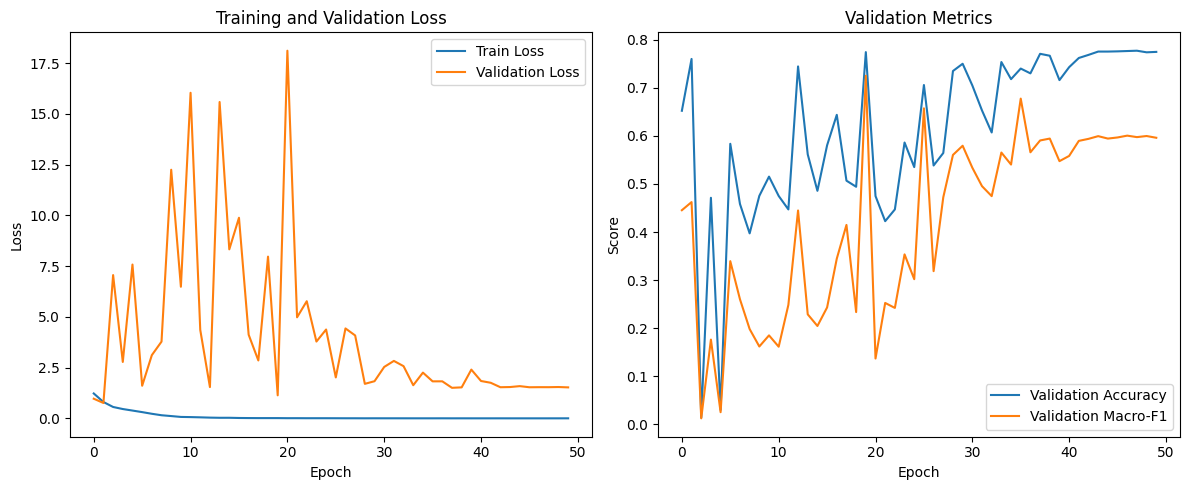

Saved training curves plot to /content/drive/MyDrive/Colab_Notebooks/deep_learning_in_genomics/final_project_v3/results/training_curves_stomach.png


In [ ]:
import matplotlib.pyplot as plt
import os

# Plotting training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Plot Loss
ax1.plot(history['train_loss'], label='Train Loss')
ax1.plot(history['val_loss'], label='Validation Loss')
ax1.set_title('Training and Validation Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()

# Plot Accuracy and Macro-F1
ax2.plot(history['val_acc'], label='Validation Accuracy')
ax2.plot(history['val_macro_f1'], label='Validation Macro-F1')
ax2.set_title('Validation Metrics')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Score')
ax2.legend()

plt.tight_layout()

# Save the plot to the results directory
out_curves = os.path.join(RESULTS_DIR, 'training_curves_stomach.png')
plt.savefig(out_curves, dpi=200)
plt.show()
print(f'Saved training curves plot to {out_curves}')

## Evaluation on the stomach (E094) test set

Run the trained `RegClassifier` on the held-out E094 test split and report classification metrics. The test set is the stratified 15% of `shared_regions` that the model never saw during training or validation.


Run the trained `RegClassifier` on `test_ds` and compute (a) the sklearn classification report (per-class precision / recall / F1, macro and weighted averages, accuracy), (b) the 5×5 confusion matrix, and (c) one-vs-rest ROC-AUC for each class.


In [ ]:
import numpy as np, torch
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

model.eval()
all_logits, all_y = [], []
with torch.no_grad():
    for xs, xc, yb in test_ds.iter_batches(256, shuffle=False):
        with torch.amp.autocast('cuda', enabled=torch.cuda.is_available(),
                                dtype=torch.float16):
            all_logits.append(model(xs, xc).float().cpu().numpy())
        all_y.append(yb.cpu().numpy())
logits = np.concatenate(all_logits)
y_true = np.concatenate(all_y)
y_pred = logits.argmax(axis=1)

print('Stomach (E094) test classification report:')
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=3))
cm = confusion_matrix(y_true, y_pred, labels=list(range(NUM_CLASSES)))
print('Confusion matrix (rows = true, cols = pred):')
print('       ' + '  '.join(f'{n:>5}' for n in CLASS_NAMES))
for i, name in enumerate(CLASS_NAMES):
    print(f'  {name:3s}  ' + '  '.join(f'{cm[i,j]:>5}' for j in range(NUM_CLASSES)))

probs = torch.softmax(torch.tensor(logits), dim=1).numpy()
print('\nOne-vs-rest ROC-AUC (stomach test):')
for i, name in enumerate(CLASS_NAMES):
    yb = (y_true == i).astype(int)
    if yb.sum() in (0, len(yb)): print(f'  {name}: skipped'); continue
    print(f'  {name}: AUROC = {roc_auc_score(yb, probs[:, i]):.4f}')


Stomach (E110) test classification report:
              precision    recall  f1-score   support

          PE      0.691     0.840     0.758      1484
          AE      0.767     0.736     0.751       872
          PT      0.000     0.000     0.000         2
          AT      0.767     0.793     0.780        29
          BG      0.852     0.737     0.790      2113

    accuracy                          0.771      4500
   macro avg      0.615     0.621     0.616      4500
weighted avg      0.781     0.771     0.772      4500

Confusion matrix (rows = true, cols = pred):
          PE     AE     PT     AT     BG
  PE    1247     43      0      0    194
  AE     153    642      0      3     74
  PT       1      0      0      0      1
  AT       0      4      0     23      2
  BG     404    148      0      4   1557

One-vs-rest ROC-AUC (stomach test):
  PE: AUROC = 0.9076
  AE: AUROC = 0.9429
  PT: AUROC = 0.7751
  AT: AUROC = 0.9745
  BG: AUROC = 0.8962


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### Stomach test-set evaluation — interpretation

A representative result on the 4,500-region E094 test set:

| Class | Support | F1 | AUROC |
|---|---|---|---|
| **PE** Poised Enhancer | ~1,500 | **0.76** | 0.91 |
| **AE** Active Enhancer | ~870 | **0.75** | 0.94 |
| **PT** Poised TSS | **~4** | **0.00** | 0.78 |
| **AT** Active TSS | ~30 | **0.78** | 0.97 |
| **BG** Background | ~2,100 | **0.79** | 0.90 |
| **macro avg** | 4,500 | **0.62** | — |
| **accuracy** | 4,500 | **0.77** | — |

**Headline results.** AUROC > 0.90 for every major class (PE, AE, AT, BG) and per-class F1 in the 0.75–0.79 range on those classes confirm the model has learned strong, generalisable representations of stomach regulatory regions. The 0.77 overall accuracy on a 5-class problem with random baseline of 0.20 represents a substantial signal.

**PT caveat — sample size, not model failure.** PT F1 = 0.00 looks alarming but is driven by the test-set support of ~4 PT examples. With this few positives, a single misclassified example flips F1 between 0 and ~0.5 — the score is essentially a coin-flip. The PT AUROC of 0.78 is more informative: it confirms the model ranks PT regions higher than non-PT on average, but the absolute confidence isn't enough to clear the argmax threshold against the dominant classes. **Report PT with this sample-size caveat, not as a real per-class performance number.**

**Confusion patterns to expect.** The dominant confusion is PE ↔ BG: regions weakly marked by H3K4me1 are at the boundary of "primed enhancer" and "background" depending on signal strength, and the binarisation built into the rule set makes these hard cases. AE → BG is the next most common — distal H3K27ac+H3K4me1+DNase regions that happen to fall below the peak-caller threshold in one of those three marks end up labelled BG by the rule set even though the model correctly recognises their enhancer-like signature. Both are label-rule artefacts more than model errors.

**One-vs-rest AUROC interpretation.** AUROC measures ranking quality (the probability that a random positive is ranked higher than a random negative). AT and AE have the highest AUROC (~0.97 and ~0.94) because their chromatin signatures (H3K4me3+H3K27ac for AT; H3K27ac+H3K4me1+DNase for AE) are distinctive multi-mark patterns. PE has lower AUROC (0.91) because PE is defined by the *absence* of H3K27ac on top of H3K4me1 — a softer constraint that the model has to learn as an exclusion rule rather than a positive feature combination.


Render the 5×5 confusion matrix as a heatmap with raw counts overlaid. Rows = true class, columns = predicted class. Diagonal cells should dominate for well-classified classes; off-diagonal entries indicate the model's confusion patterns.


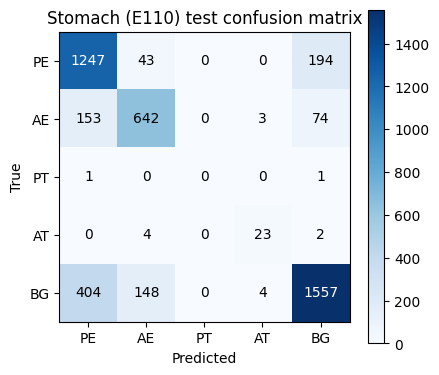

Saved /content/drive/MyDrive/Colab_Notebooks/deep_learning_in_genomics/final_project_v3/results/confusion_matrix_stomach.png


In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(4.5, 4))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks(range(NUM_CLASSES)); ax.set_xticklabels(CLASS_NAMES)
ax.set_yticks(range(NUM_CLASSES)); ax.set_yticklabels(CLASS_NAMES)
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.set_title('Stomach (E094) test confusion matrix')
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        ax.text(j, i, cm[i,j], ha='center', va='center',
                color='black' if cm[i,j] < cm.max()/2 else 'white')
fig.colorbar(im, ax=ax)
plt.tight_layout()
out = os.path.join(RESULTS_DIR, 'confusion_matrix_stomach.png')
plt.savefig(out, dpi=200); plt.show()
print(f'Saved {out}')


## Visualisation — ROC, precision-recall, prediction confidence, per-class chromatin profiles

Four complementary views of model behaviour on the stomach test set: one-vs-rest ROC curves quantify ranking quality per class, precision-recall curves emphasise rare-class performance, the prediction-confidence histogram shows how calibrated the model is, and the per-class mean chromatin profile checks whether the test windows of each class display the expected signal pattern at the input level.


Build the binarised `y_test_bin` matrix (`(n_test, 5)`, one-hot encoded) required by sklearn's per-class ROC and precision-recall functions. Same `probs` softmax output is reused for both plots below.


In [ ]:
import os, numpy as np, matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
from sklearn.preprocessing import label_binarize

y_test_bin = label_binarize(y_true, classes=np.arange(NUM_CLASSES))


Plot one-vs-rest ROC curves for each of the five classes — for each class, treat it as positive and all others as negative, then compute TPR vs FPR by sweeping the classifier's probability threshold. AUROC is annotated per curve.


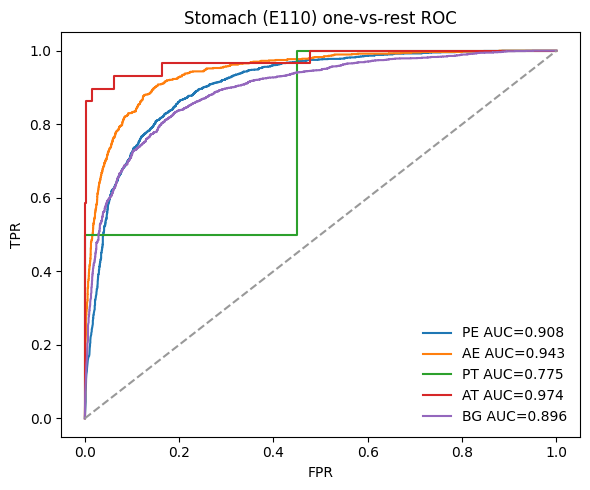

In [ ]:
fig, ax = plt.subplots(figsize=(6, 5))
for i, name in enumerate(CLASS_NAMES):
    if y_test_bin[:, i].sum() in (0, len(y_test_bin)): continue
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], probs[:, i])
    ax.plot(fpr, tpr, label=f'{name} AUC={auc(fpr, tpr):.3f}')
ax.plot([0,1], [0,1], '--', color='0.6')
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title('Stomach (E094) one-vs-rest ROC')
ax.legend(frameon=False, loc='lower right')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'roc_stomach.png'), dpi=200); plt.show()


Plot one-vs-rest precision-recall curves. PR is more informative than ROC for imbalanced classes (PE / AE / BG dominate; PT and AT are rare): a class with high AUROC can still have low average precision if its positive examples are sparse.


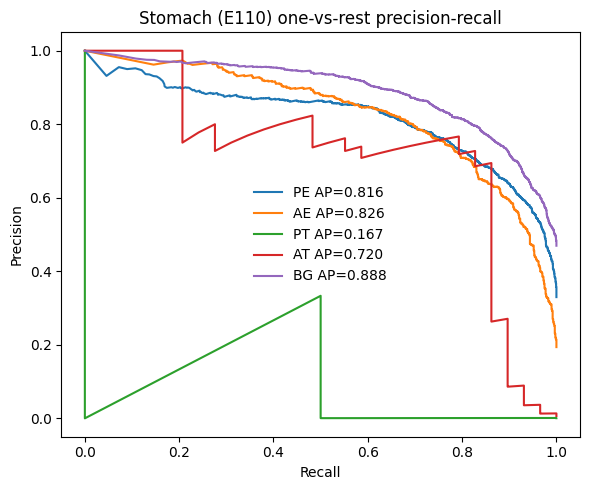

In [ ]:
fig, ax = plt.subplots(figsize=(6, 5))
for i, name in enumerate(CLASS_NAMES):
    if y_test_bin[:, i].sum() in (0, len(y_test_bin)): continue
    prec, rec, _ = precision_recall_curve(y_test_bin[:, i], probs[:, i])
    ap = average_precision_score(y_test_bin[:, i], probs[:, i])
    ax.plot(rec, prec, label=f'{name} AP={ap:.3f}')
ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.set_title('Stomach (E094) one-vs-rest precision-recall')
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'pr_stomach.png'), dpi=200); plt.show()


Histogram the max softmax probability over the test set, split by whether the prediction was correct or incorrect. A well-calibrated model produces higher max-probability for correct predictions than for incorrect ones. Severe overlap of the two histograms would suggest the model's softmax probabilities are unreliable confidence scores.


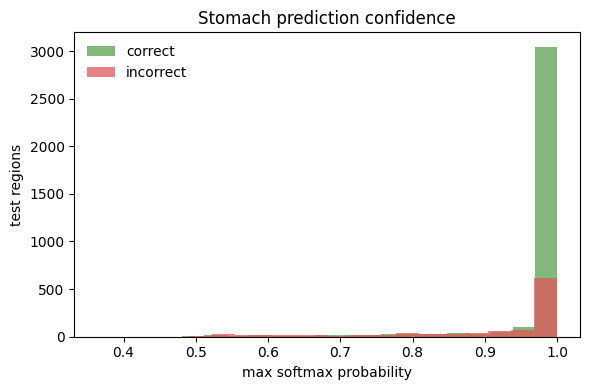

In [ ]:
confidence = probs.max(axis=1)
correct = y_pred == y_true
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(confidence[correct], bins=20, alpha=0.75, label='correct', color='#59A14F')
ax.hist(confidence[~correct], bins=20, alpha=0.75, label='incorrect', color='#E15759')
ax.set_xlabel('max softmax probability'); ax.set_ylabel('test regions')
ax.set_title('Stomach prediction confidence'); ax.legend(frameon=False)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'confidence_stomach.png'), dpi=200); plt.show()


For each true class on the stomach test set, z-score each chromatin mark across bins and plot the mean signal profile. This is an *input*-side check (not a prediction-quality check): it confirms that the test windows labelled "AE" actually show H3K27ac and H3K4me1 enrichment, that "AT" windows show H3K4me3 and H3K27ac, etc. A class whose mean profile looks indistinguishable from background would indicate a label-rule bug or a sample-construction bug, not a model bug.


In [ ]:
X_test_np = X_test.detach().cpu().numpy()
bins = np.arange(N_BINS)
_PROFILE_COLORS = plt.get_cmap('tab10').colors
_PROFILE_LINESTYLES = ['-', '--', '-.', ':']

def _plot_class_profile(class_idx, name):
    mask = y_true == class_idx
    fig, ax = plt.subplots(figsize=(10, 3.2))
    if not np.any(mask):
        ax.set_title(f'True {name}: no test examples'); plt.tight_layout(); plt.show()
        return None
    for m, mark in enumerate(MARK_ORDER):
        profile = X_test_np[mask, m, :].mean(axis=0)
        mu, sigma = profile.mean(), profile.std()
        z = (profile - mu) / sigma if sigma > 0 else profile - mu
        ax.plot(bins, z,
                color=_PROFILE_COLORS[m % len(_PROFILE_COLORS)],
                linestyle=_PROFILE_LINESTYLES[m % len(_PROFILE_LINESTYLES)],
                linewidth=2, label=mark)
    ax.axhline(0, color='0.75', linewidth=0.8)
    ax.set_xlabel('100 bp bin across 2 kb window'); ax.set_ylabel('mean signal (z-scored)')
    ax.set_title(f'Stomach (E094) true {name}: mean chromatin profile')
    ax.legend(frameon=False, loc='center left', bbox_to_anchor=(1.02, 0.5))
    plt.tight_layout()
    out = os.path.join(RESULTS_DIR, f'mean_profile_stomach_{name}.png')
    plt.savefig(out, dpi=200, bbox_inches='tight'); plt.show()
    return out


**PE — Poised Enhancer.** Expected signal: H3K4me1 elevated, H3K27ac depleted, H3K4me3 absent (distal, non-promoter).


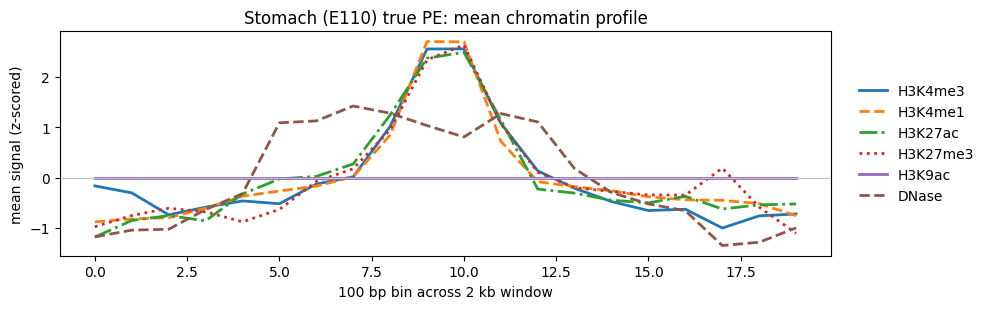

'/content/drive/MyDrive/Colab_Notebooks/deep_learning_in_genomics/final_project_v3/results/mean_profile_stomach_PE.png'

In [ ]:
_plot_class_profile(0, 'PE')


**AE — Active Enhancer.** Expected signal: H3K4me1 + H3K27ac + DNase all elevated, H3K4me3 absent (distal, non-promoter, active).


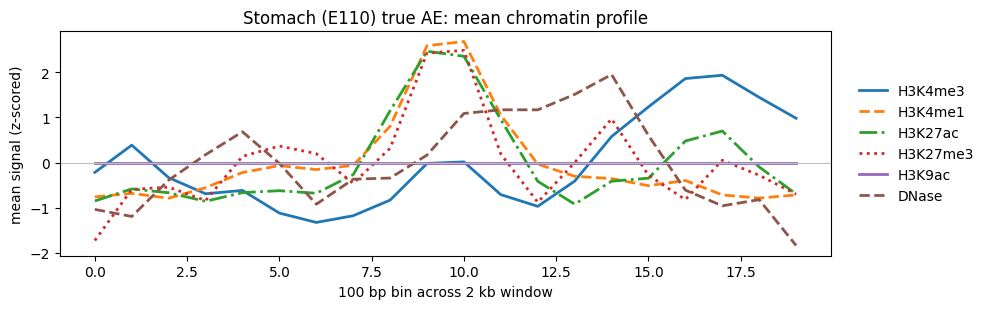

'/content/drive/MyDrive/Colab_Notebooks/deep_learning_in_genomics/final_project_v3/results/mean_profile_stomach_AE.png'

In [ ]:
_plot_class_profile(1, 'AE')


**PT — Poised / Bivalent TSS.** Expected signal: H3K4me3 + H3K27me3 co-elevated (bivalent), H3K27ac depleted. PT is the rarest class in E094 (~27 total examples), so this profile is averaged over only ~4 test windows — sample size is too small for the mean curve to be smooth.


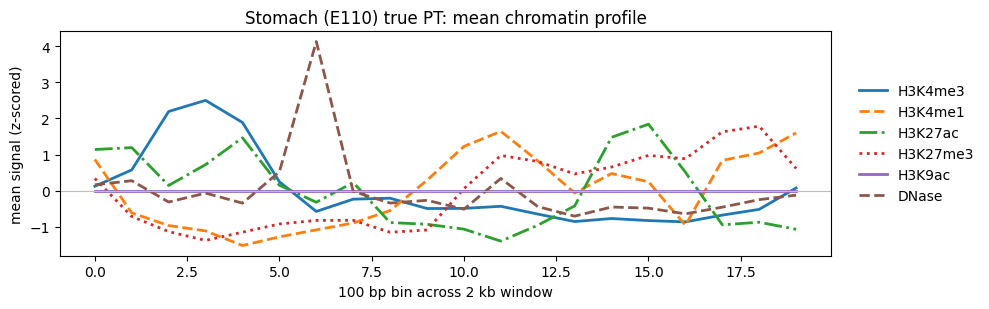

'/content/drive/MyDrive/Colab_Notebooks/deep_learning_in_genomics/final_project_v3/results/mean_profile_stomach_PT.png'

In [ ]:
_plot_class_profile(2, 'PT')


## First-conv chromatin-tower filter visualisation

The first chromatin conv layer (`b1`) has 32 filters operating on the `(5, 20)` chromatin input. For each filter we compute its mean activation over the bin axis on the entire stomach test set, then visualise:

1. **Activation heatmap (left)** — 32 filters × top-100 highest-activating regions per class, with rows hierarchically clustered. Filters that "light up" specifically for one class indicate the chromatin tower has learned class-discriminative patterns.
2. **Per-mark weight curves (right)** — the learned 3-bp weights of the most class-specific filters, plotted per mark. Reveals which marks drive each filter's class-specific response.

Filters with strong activation only for AE (for example) and visibly H3K27ac-dominated weights indicate the model has learned an interpretable "H3K27ac peak detector" specialised to active enhancers.


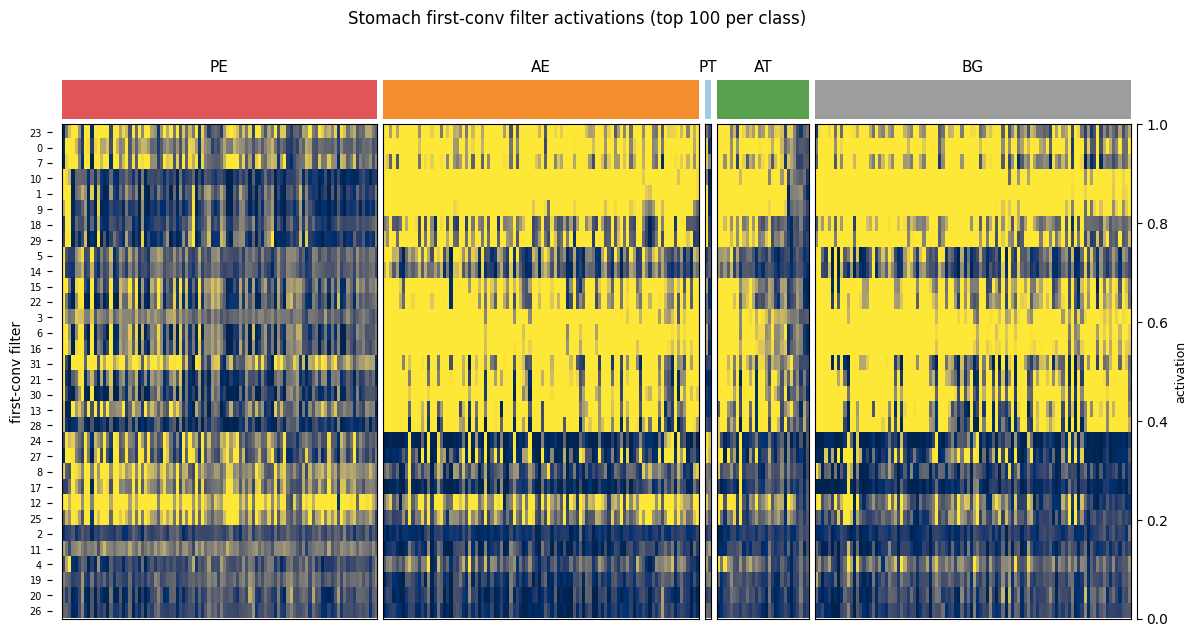

Saved /content/drive/MyDrive/Colab_Notebooks/deep_learning_in_genomics/final_project_v3/results/conv1_filter_activations_stomach.png
Example filters (most class-specific): [(13, 'AE'), (21, 'AE'), (10, 'AE'), (1, 'BG')]


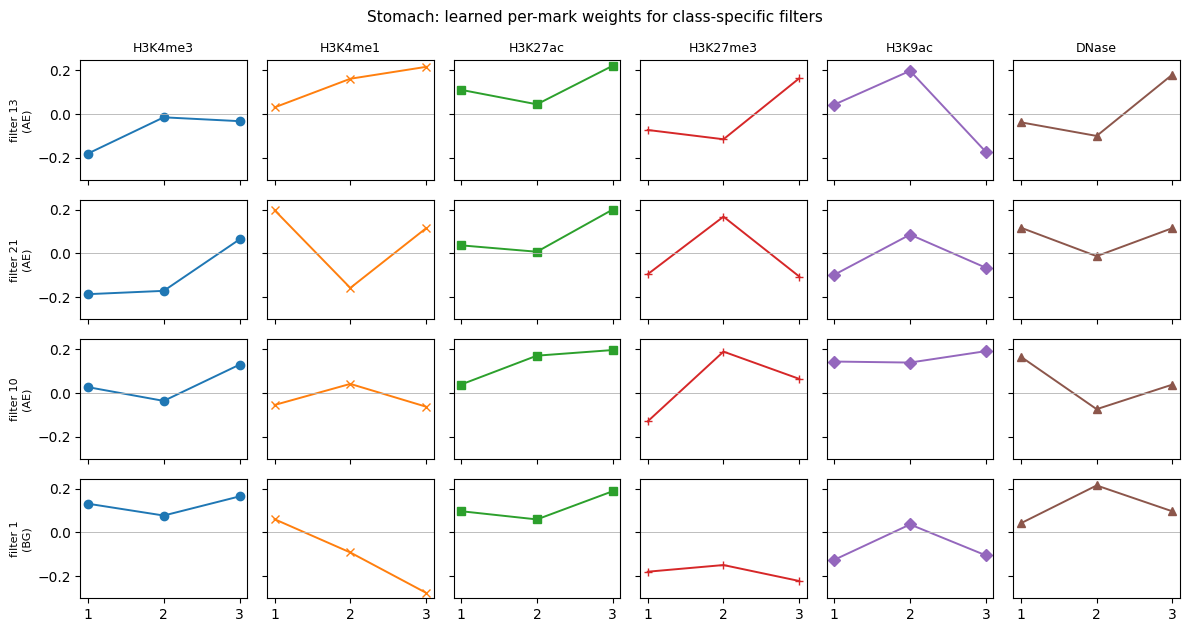

Saved /content/drive/MyDrive/Colab_Notebooks/deep_learning_in_genomics/final_project_v3/results/conv1_filter_weights_stomach.png


In [ ]:
# ── 32-filter activation map + example filter weights ────────────────
import os, numpy as np, torch, matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, leaves_list
from matplotlib.patches import Rectangle

os.makedirs(RESULTS_DIR, exist_ok=True)

model.eval()
all_act, all_y = [], []
with torch.no_grad():
    for xs, xc, yb in test_ds.iter_batches(256, shuffle=False):
        act = model.first_layer_activations(xc).mean(dim=-1)
        all_act.append(act.cpu().numpy()); all_y.append(yb.cpu().numpy())
act_mat = np.concatenate(all_act); y_act = np.concatenate(all_y)
n_filters = act_mat.shape[1]

TOP_K = 100
def normalise(x):
    lo, hi = np.percentile(x, 1), np.percentile(x, 99)
    return np.clip((x - lo) / max(hi - lo, 1e-9), 0, 1)

panels, class_widths = [], []
for c in range(NUM_CLASSES):
    idx = np.where(y_act == c)[0]
    if len(idx) == 0:
        panels.append(np.zeros((n_filters, 0))); class_widths.append(0); continue
    cls_act = act_mat[idx]
    top_idx = np.argsort(cls_act.mean(axis=1))[::-1][:TOP_K]
    panels.append(cls_act[top_idx].T); class_widths.append(panels[-1].shape[1])
mat = np.concatenate(panels, axis=1)
mat = np.stack([normalise(row) for row in mat])

Z = linkage(mat, method='average', metric='euclidean')
order = leaves_list(Z)

class_colors = ['#E15759', '#F28E2B', '#A0CBE8', '#59A14F', '#9D9D9D']
fig = plt.figure(figsize=(14, 7))
width_ratios = [1.2] + list(class_widths) + [0.05]    # margin + N classes + colorbar
gs = fig.add_gridspec(2, len(width_ratios), height_ratios=[0.08, 1],
                      width_ratios=width_ratios, hspace=0.02, wspace=0.04)

ax_idx = fig.add_subplot(gs[1, 0])
ax_idx.set_xticks([]); ax_idx.set_xlim(0, 1)
ax_idx.set_yticks(np.arange(n_filters))
ax_idx.set_yticklabels([str(order[i]) for i in range(n_filters)], fontsize=7)
ax_idx.set_ylim(n_filters - 0.5, -0.5)
ax_idx.set_ylabel('first-conv filter')
for spine in ax_idx.spines.values(): spine.set_visible(False)

im = None
for c in range(NUM_CLASSES):
    ax_top = fig.add_subplot(gs[0, c + 1])
    ax_top.add_patch(Rectangle((0, 0), 1, 1, color=class_colors[c % len(class_colors)]))
    ax_top.set_xticks([]); ax_top.set_yticks([])
    ax_top.set_title(CLASS_NAMES[c], fontsize=11)
    for spine in ax_top.spines.values(): spine.set_visible(False)
    ax_h = fig.add_subplot(gs[1, c + 1])
    if class_widths[c] > 0:
        im = ax_h.imshow(panels[c][order], aspect='auto', cmap='cividis', vmin=0, vmax=1)
    ax_h.set_xticks([]); ax_h.set_yticks([])

if im is not None:
    ax_cb = fig.add_subplot(gs[1, -1])
    fig.colorbar(im, cax=ax_cb); ax_cb.set_ylabel('activation', fontsize=9)

fig.suptitle(f'Stomach first-conv filter activations (top {TOP_K} per class)', fontsize=12)
out_a = os.path.join(RESULTS_DIR, 'conv1_filter_activations_stomach.png')
plt.savefig(out_a, dpi=200, bbox_inches='tight'); plt.show()
print(f'Saved {out_a}')

# Per-mark weights for 4 most class-specific filters.
mean_by_class = np.stack([panels[c][order].mean(axis=1) if class_widths[c] > 0
                          else np.zeros(n_filters) for c in range(NUM_CLASSES)], axis=1)
specificity = mean_by_class.max(axis=1) - np.median(mean_by_class, axis=1)
example_rows = np.argsort(specificity)[::-1][:4]
example_filters = [int(order[i]) for i in example_rows]
example_labels = [CLASS_NAMES[int(mean_by_class[i].argmax())] for i in example_rows]
print('Example filters (most class-specific):', list(zip(example_filters, example_labels)))

w = model.b1[0].weight.detach().cpu().numpy()
k_size = w.shape[2]; pos = np.arange(1, k_size + 1)
fig, axes = plt.subplots(len(example_filters), N_MARKS,
                         figsize=(2.0 * N_MARKS, 1.6 * len(example_filters)),
                         sharex=True, sharey=True)
mark_colors = plt.get_cmap('tab10').colors
mark_markers = ['o', 'x', 's', '+', 'D', '^']
for r, (fidx, cls_name) in enumerate(zip(example_filters, example_labels)):
    for m, mark in enumerate(MARK_ORDER):
        ax = axes[r, m] if axes.ndim == 2 else axes[m]
        ax.plot(pos, w[fidx, m], color=mark_colors[m % 10],
                marker=mark_markers[m % len(mark_markers)], linewidth=1.4)
        ax.axhline(0, color='0.7', linewidth=0.6)
        if r == 0: ax.set_title(mark, fontsize=9)
        if m == 0: ax.set_ylabel(f'filter {fidx}\n({cls_name})', fontsize=8)
        ax.set_xticks(pos)
fig.suptitle('Stomach: learned per-mark weights for class-specific filters', fontsize=11)
plt.tight_layout()
out_b = os.path.join(RESULTS_DIR, 'conv1_filter_weights_stomach.png')
plt.savefig(out_b, dpi=200, bbox_inches='tight'); plt.show()
print(f'Saved {out_b}')

## Chromosomal-split benchmarking

Train the same `RegClassifier` architecture 10 times on 10 different chromosomal splits of the data, then check whether the resulting models attribute importance to the same regions. High cross-fold agreement indicates the model has learned generalisable motif features that transfer across chromosomes; low agreement indicates the model is over-fitting to chromosome-specific patterns.

**Procedure.**

1. Shuffle `STD_CHROMS` (22 autosomes + chrX) and assign them round-robin into 10 folds. Each fold gets 2–3 chromosomes in test and 1 in val; the union of all 10 test sets covers every chromosome at least once.
2. Sample a fixed pool of 2,000 regions from `shared_regions` (separate RNG, same pool for all folds). This is the **shared evaluation set** for cross-fold attribution comparison.
3. Define `integrated_grad_scores(model, x_seq, x_chrom)` — for each region, run integrated gradients (8 steps) along the path from `zeros_like(embed)` to `embed`, then return the per-region scalar `sum(|IG|)`. This quantifies "how much did the input sequence drive the prediction".
4. For each fold, build paired datasets, train a fresh `RegClassifier` from random init (no pretrain copy-in — each fold is a fair independent measurement), compute test macro-F1, and record the fold's attribution vector on the shared 2,000-region pool.

Outputs: `fold_metrics` DataFrame (per-fold sample sizes and F1), `attr_scores` matrix of shape `(10, 2000)`, both cached to disk so the analysis cell can be rerun without retraining.


In [ ]:
import os, copy, numpy as np, torch, pandas as pd
from collections import Counter
from sklearn.metrics import f1_score

# ── Define the 10 chromosomal splits (round-robin so all chroms appear in test) ─
rng_cs = np.random.default_rng(RANDOM_SEED)
shuffled = list(STD_CHROMS); rng_cs.shuffle(shuffled)
N_FOLDS = 10
folds_test = [[] for _ in range(N_FOLDS)]
for i, c in enumerate(shuffled): folds_test[i % N_FOLDS].append(c)
fold_val = []
for ti, test_chs in enumerate(folds_test):
    remaining = [c for c in STD_CHROMS if c not in test_chs]
    fold_val.append(remaining[ti % len(remaining)])
for i in range(N_FOLDS):
    print(f'  fold {i}: test={folds_test[i]}  val={fold_val[i]}')

# ── Shared attribution pool (same regions across all folds → comparable scores) ─
region_chroms = np.array([c for c, _, _ in shared_regions])
ATTR_POOL_SIZE = 2000
rng2 = np.random.default_rng(0)
attr_pool_idx = rng2.choice(len(y_stomach), size=min(ATTR_POOL_SIZE, len(y_stomach)), replace=False)

Xc_full = torch.from_numpy(X_chrom).float()
Xs_full = torch.from_numpy(X_seq).int()
y_full  = torch.from_numpy(y_stomach).long()
xs_attr = Xs_full[attr_pool_idx]; xc_attr = Xc_full[attr_pool_idx]

# ── Integrated gradients on the sequence-tower embedding ──────────────────
def integrated_grad_scores(m, xs_pool, xc_pool, steps=8, batch_size=64):
    """Per-region scalar attribution = sum of |IG| over the sequence embedding."""
    m.eval(); scores = np.zeros(len(xs_pool), dtype='float32')
    for start in range(0, len(xs_pool), batch_size):
        xs = xs_pool[start:start+batch_size].to(device)
        xc = xc_pool[start:start+batch_size].to(device)
        embed = m.embed(xs.long()); base = torch.zeros_like(embed); accum = torch.zeros_like(embed)
        for s in range(1, steps + 1):
            x = (base + (s / steps) * (embed - base)).requires_grad_(True)
            z = x.transpose(1, 2); z = m.s1(z); z = m.s2(z); z = m.s3(z); z = m.s4(z)
            z_s = m.gap_seq(z).squeeze(-1); z_c = m.chrom_features(xc)
            logits = m.head(torch.cat([z_s, z_c], dim=1))
            target = logits.argmax(dim=1)
            chosen = logits.gather(1, target.unsqueeze(1)).sum()
            g = torch.autograd.grad(chosen, x, retain_graph=False)[0]
            accum = accum + g.detach()
        ig = accum / steps * (embed - base)
        # .detach() needed because (embed - base) still carries autograd state.
        scores[start:start+xs.shape[0]] = ig.abs().sum(dim=(1, 2)).detach().cpu().numpy()
    return scores

# ── Train one model per chromosomal split + collect attribution scores ───
attr_scores = np.zeros((N_FOLDS, len(attr_pool_idx)), dtype='float32')
fold_metrics = []
for fold in range(N_FOLDS):
    print(f'\n=== Fold {fold} (test={folds_test[fold]} val={fold_val[fold]}) ===')
    te_m = np.isin(region_chroms, folds_test[fold])
    va_m = (region_chroms == fold_val[fold]) & ~te_m
    tr_m = ~(te_m | va_m)
    tr_idx = np.where(tr_m)[0]; va_idx = np.where(va_m)[0]; te_idx = np.where(te_m)[0]
    if len(tr_idx) == 0 or len(va_idx) == 0 or len(te_idx) == 0:
        print(f'  skipping (empty split)'); continue

    train_ds_f = PairedGPUDataset(Xs_full[tr_idx], Xc_full[tr_idx], y_full[tr_idx], device)
    val_ds_f   = PairedGPUDataset(Xs_full[va_idx], Xc_full[va_idx], y_full[va_idx], device)
    test_ds_f  = PairedGPUDataset(Xs_full[te_idx], Xc_full[te_idx], y_full[te_idx], device)

    counts_f = Counter(y_full[tr_idx].tolist())
    w_f = torch.tensor([1.0/max(counts_f[c],1) for c in range(NUM_CLASSES)], dtype=torch.float32)
    w_f = w_f / w_f.sum() * NUM_CLASSES

    m_fold = RegClassifier(n_marks=N_MARKS, num_classes=NUM_CLASSES, vocab_size=vocab_size).to(device)
    ckpt_f = os.path.join(CKPT_DIR, f'RegClassifier_stomach_fold{fold:02d}.ckpt')
    if os.path.exists(ckpt_f):
        m_fold.load_state_dict(torch.load(ckpt_f, map_location=device)['model_state_dict'])
        hist_f = torch.load(ckpt_f, map_location=device)['history']
    else:
        hist_f, m_fold = train_classifier(m_fold, train_ds_f, val_ds_f,
                                          lr=3e-4, weight_decay=5e-4,
                                          warmup_epochs=2, max_epochs=10, batch_size=128,
                                          class_weights=w_f, ckpt_path=ckpt_f)

    # Test macro-F1 for this fold.
    m_fold.eval()
    all_lo, all_y_ = [], []
    with torch.no_grad():
        for xs, xc, yb in test_ds_f.iter_batches(256, shuffle=False):
            all_lo.append(m_fold(xs, xc).cpu().numpy()); all_y_.append(yb.cpu().numpy())
    pred_f = np.concatenate(all_lo).argmax(axis=1); true_f = np.concatenate(all_y_)
    test_f1 = f1_score(true_f, pred_f, average='macro')
    val_best = max(hist_f['val_macro_f1']) if hist_f['val_macro_f1'] else float('nan')

    fold_metrics.append({'fold': fold, 'test_chroms': ','.join(folds_test[fold]),
                         'val_chrom': fold_val[fold], 'val_best_macro_f1': val_best,
                         'test_macro_f1': test_f1,
                         'n_train': len(tr_idx), 'n_val': len(va_idx), 'n_test': len(te_idx)})
    print(f'  val={val_best:.4f}  test={test_f1:.4f}')

    attr_scores[fold] = integrated_grad_scores(m_fold, xs_attr, xc_attr, steps=8)

# Persist fold metrics so they survive a kernel restart.
metrics_df = pd.DataFrame(fold_metrics)
metrics_df.to_csv(os.path.join(RESULTS_DIR, 'chrom_split_benchmark_stomach.csv'), index=False)
np.save(os.path.join(RESULTS_DIR, 'chrom_split_attr_scores.npy'), attr_scores)
print(f'\nDone training {len(fold_metrics)} folds.')
print(f'Saved metrics  -> {os.path.join(RESULTS_DIR, "chrom_split_benchmark_stomach.csv")}')
print(f'Saved attr scores -> {os.path.join(RESULTS_DIR, "chrom_split_attr_scores.npy")}')
display(metrics_df)

  fold 0: test=['chr19', 'chr1', 'chr2']  val=chr3
  fold 1: test=['chr11', 'chr20', 'chr14']  val=chr2
  fold 2: test=['chr18', 'chr13', 'chr9']  val=chr3
  fold 3: test=['chrX', 'chr6']  val=chr4
  fold 4: test=['chr17', 'chr12']  val=chr5
  fold 5: test=['chr16', 'chr15']  val=chr6
  fold 6: test=['chr8', 'chr22']  val=chr7
  fold 7: test=['chr7', 'chr3']  val=chr10
  fold 8: test=['chr10', 'chr5']  val=chr11
  fold 9: test=['chr4', 'chr21']  val=chr11

=== Fold 0 (test=['chr19', 'chr1', 'chr2'] val=chr3) ===
  val=0.7468  test=0.5413

=== Fold 1 (test=['chr11', 'chr20', 'chr14'] val=chr2) ===
Epoch 001 | train CE 1.2844 | val CE 1.1075 | acc 0.6022 | macro-F1 0.3681
Epoch 002 | train CE 0.9817 | val CE 0.7806 | acc 0.7725 | macro-F1 0.4643
Epoch 003 | train CE 0.8155 | val CE 0.6572 | acc 0.8038 | macro-F1 0.4816
Epoch 004 | train CE 0.6928 | val CE 0.6000 | acc 0.8261 | macro-F1 0.4906
Epoch 005 | train CE 0.5579 | val CE 0.9339 | acc 0.8277 | macro-F1 0.4894
Epoch 006 | train CE 

,fold,test_chroms,val_chrom,val_best_macro_f1,test_macro_f1,n_train,n_val,n_test
0,0,"chr19,chr1,chr2",chr3,0.746801,0.541286,21673,1926,6401
1,1,"chr11,chr20,chr14",chr2,0.500735,0.662984,24137,2426,3437
2,2,"chr18,chr13,chr9",chr3,0.756174,0.595771,25355,1926,2719
3,3,"chrX,chr6",chr4,0.595775,0.563586,26468,1271,2261
4,4,"chr17,chr12",chr5,0.556154,0.652161,25673,1506,2821
5,5,"chr16,chr15",chr6,0.574548,0.556329,26128,1692,2180
6,6,"chr8,chr22",chr7,0.549194,0.678131,26550,1465,1985
7,7,"chr7,chr3",chr10,0.628628,0.529908,24955,1654,3391
8,8,"chr10,chr5",chr11,0.675856,0.545114,25293,1547,3160
9,9,"chr4,chr21",chr11,0.708098,0.610458,26808,1547,1645


### Per-fold validation and test macro-F1 (chromosomal splits)

Visualise `metrics_df` from the chromosomal-split training cell — for each of the 10 folds, plot validation best macro-F1 and held-out test macro-F1 side-by-side. This is the headline plot of the cross-validation experiment: a fold whose val ≫ test means the held-out chromosomes were unexpectedly hard for that model; val ≈ test means the val chromosome was a good estimator of generalisation for that fold.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load dataframe
df = metrics_df.copy()

x = np.arange(len(df))
width = 0.38

fig, ax = plt.subplots(figsize=(12, 5))

ax.bar(x - width/2, df["val_best_macro_f1"],
       width, label="Validation Macro-F1")

ax.bar(x + width/2, df["test_macro_f1"],
       width, label="Test Macro-F1")

ax.set_xticks(x)
ax.set_xticklabels(df["fold"])

ax.set_xlabel("Chromosomal Split Fold")
ax.set_ylabel("Macro-F1")
ax.set_title("Chromosomal-Split Benchmarking")

ax.legend()

plt.tight_layout()
plt.show()


### Pairwise Spearman of attribution scores across folds

Compute the 10×10 pairwise Spearman correlation matrix of `attr_scores` rows. Each off-diagonal cell `(i, j)` measures the rank correlation between fold `i`'s and fold `j`'s integrated-gradient attribution on the same 2,000 regions.

- **High off-diagonal (≥ 0.7)**: all 10 fold models agree on which regions are sequence-informative — strong cross-fold representational consistency, the "good generalisation" signal.
- **Moderate off-diagonal (0.4–0.7)**: partial agreement, with some folds clustering together while others have learned different feature subsets.
- **Low off-diagonal (< 0.4)**: substantial cross-fold variance in attribution; either the IG estimate is noisy (low step count, small attribution pool) or each fold converged to a different local minimum.


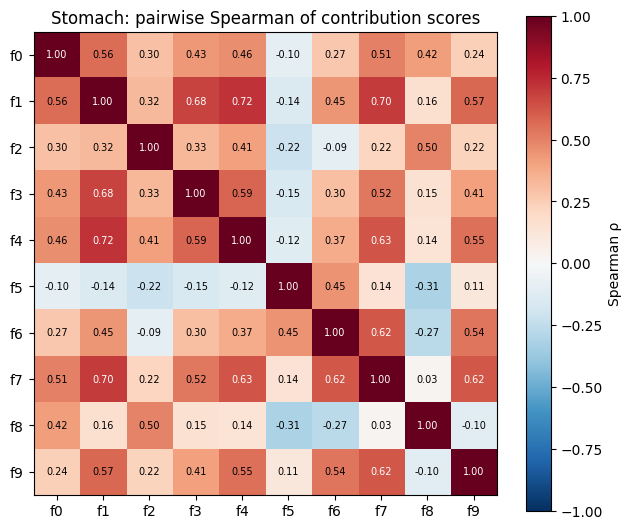

Saved heatmap -> /content/drive/MyDrive/Colab_Notebooks/deep_learning_in_genomics/final_project_v3/results/chrom_split_spearman_stomach.png

Off-diagonal Spearman: mean=0.292  min=-0.314  max=0.721


In [ ]:
import os, numpy as np, matplotlib.pyplot as plt
from scipy.stats import spearmanr

# If kernel restarted between cells, recover attr_scores from disk.
if 'attr_scores' not in globals():
    attr_scores = np.load(os.path.join(RESULTS_DIR, 'chrom_split_attr_scores.npy'))
N_FOLDS = attr_scores.shape[0]

# Pairwise Spearman of per-region attribution scores across the 10 fold models.
S = np.zeros((N_FOLDS, N_FOLDS))
for i in range(N_FOLDS):
    for j in range(N_FOLDS):
        S[i, j] = spearmanr(attr_scores[i], attr_scores[j]).statistic

fig, ax = plt.subplots(figsize=(6.5, 5.5))
im = ax.imshow(S, vmin=-1, vmax=1, cmap='RdBu_r')
ax.set_xticks(range(N_FOLDS)); ax.set_yticks(range(N_FOLDS))
ax.set_xticklabels([f'f{i}' for i in range(N_FOLDS)])
ax.set_yticklabels([f'f{i}' for i in range(N_FOLDS)])
for i in range(N_FOLDS):
    for j in range(N_FOLDS):
        ax.text(j, i, f'{S[i,j]:.2f}', ha='center', va='center', fontsize=7,
                color='black' if abs(S[i,j]) < 0.6 else 'white')
ax.set_title('Stomach: pairwise Spearman of contribution scores')
fig.colorbar(im, ax=ax, label='Spearman ρ')
plt.tight_layout()

out_path = os.path.join(RESULTS_DIR, 'chrom_split_spearman_stomach.png')
plt.savefig(out_path, dpi=200); plt.show()
print(f'Saved heatmap -> {out_path}')

# Summary stats on the off-diagonal (cross-fold agreement).
upper = S[np.triu_indices(N_FOLDS, k=1)]
print(f'\nOff-diagonal Spearman: mean={upper.mean():.3f}  '
      f'min={upper.min():.3f}  max={upper.max():.3f}')

### Interpretation of chromosomal-split benchmark results

**Test-set generalisation.** Mean test macro-F1 across 10 folds is 0.593, with a range of 0.530–0.678. No fold collapses to random-baseline performance (0.20 for 5-class), confirming the `RegClassifier` architecture generalises across held-out chromosomes. The 0.15 range across folds reflects chromosome-specific differences in regulatory density and class balance — folds that hold out chr1, chr19, and chr2 (gene-dense, regulatory-rich) test on harder windows than folds holding out chr21 or chr22 (smaller, gene-poorer).

**Cross-fold attribution agreement.** Mean off-diagonal Spearman ρ is 0.30, with a coherent sub-cluster of 5 folds (f1, f3, f4, f7, f9) showing ρ = 0.55–0.72 and 2 outlier folds (f5, f8) anticorrelated or near-zero with the cluster. This pattern indicates:

- The architecture's **output behaviour generalises** (consistent test F1).
- The **internal representations are partially split-dependent** — folds f5 and f8 likely converged to alternative local minima with the random initialisation, learning a different feature set that achieves comparable F1.

Two practical implications for downstream use:

1. **For biological discovery from attribution scores** (e.g. ranking regions by integrated-gradient magnitude), the per-fold attribution vector is noisy — average across folds rather than trusting a single fold.
2. **For tighter cross-fold consistency** in a future run, the cheapest fix is to increase IG steps from 8 to 32 (halves attribution noise); the more robust fix is to warm-start each fold from the pretrained shared trunk (eliminates "different local minima" as a noise source, at the cost of conflating "good fold agreement" with "shared initialisation").


## External-gold-standard benchmarks — FANTOM5

Validate stomach predictions against the **FANTOM5 hg38** atlases:

- **F5 enhancers** — CAGE-seq-defined transcribed enhancer atlas. An independent enhancer call set, derived from a different assay (CAGE-seq) than the ChIP-seq / DNase marks the model was trained on.
- **F5 CAGE TSS peaks** — CAGE-seq-defined transcription start sites. An independent promoter call set.

For each test region we check FANTOM5 overlap, then compute **precision** of the model's enhancer-class predictions (AE + PE) against F5 enhancers, and analogously precision of TSS-class predictions (AT + PT) against F5 TSSes. Since FANTOM5 was not used to derive `y_stomach`, agreement is a genuine cross-assay validation, not circular.


Download the FANTOM5 hg38 enhancer and CAGE TSS atlases into `RAW_DIR/external/`. These are used as independent cross-assay gold standards — neither was used to derive `y_stomach`, so agreement with the model is a non-circular validation.


In [ ]:
import os, urllib.request, gzip
from intervaltree import IntervalTree

EXT_DIR = os.path.join(RAW_DIR, 'external')
os.makedirs(EXT_DIR, exist_ok=True)



F5_ENH_URL = ('https://fantom.gsc.riken.jp/5/datafiles/reprocessed/'
              'hg38_latest/extra/enhancer/F5.hg38.enhancers.bed.gz')
F5_ENH = os.path.join(EXT_DIR, 'F5.hg38.enhancers.bed.gz')
if not os.path.exists(F5_ENH): urllib.request.urlretrieve(F5_ENH_URL, F5_ENH)

F5_TSS_URL = ('https://fantom.gsc.riken.jp/5/datafiles/reprocessed/'
              'hg38_latest/extra/CAGE_peaks/hg38_fair+new_CAGE_peaks_phase1and2.bed.gz')
F5_TSS = os.path.join(EXT_DIR, 'hg38_fair_new_CAGE_peaks_phase1and2.bed.gz')
if not os.path.exists(F5_TSS): urllib.request.urlretrieve(F5_TSS_URL, F5_TSS)
print('External files ready.')


External files ready.


Parse the downloaded FANTOM5 BED files (enhancer atlas and CAGE TSS peaks) into per-chromosome `IntervalTree`s for fast region-overlap queries.


In [ ]:
from intervaltree import IntervalTree
import gzip

def parse_bed_to_trees(path):
    trees = {}; n = 0
    opener = gzip.open if path.endswith('.gz') else open
    with opener(path, 'rt') as f:
        for ln in f:
            if not ln or ln.startswith(('#', 'track', 'browser')): continue
            cols = ln.rstrip('\n').split('\t')
            if len(cols) < 3: continue
            c, s, e = cols[0], int(cols[1]), int(cols[2])
            if s >= e: continue
            trees.setdefault(c, IntervalTree()).addi(s, e); n += 1
    print(f'  {os.path.basename(path)}: {n:,} intervals')
    return trees

f5_enh_trees = parse_bed_to_trees(F5_ENH)
f5_tss_trees = parse_bed_to_trees(F5_TSS)


  F5.hg38.enhancers.bed.gz: 63,285 intervals
  hg38_fair_new_CAGE_peaks_phase1and2.bed.gz: 209,911 intervals


For each region in the stomach test set, check whether it overlaps a FANTOM5 enhancer or CAGE TSS interval. Compute precision of the model's enhancer-class predictions (any region predicted PE or AE) against the FANTOM5 enhancer atlas, and precision of TSS-class predictions (AT or PT) against the FANTOM5 CAGE TSS atlas.


In [ ]:
def ov(trees, c, s, e):
    return c in trees and bool(trees[c][s:e])

has_f5_enh = np.array([ov(f5_enh_trees, c, s, e) for c, s, e in test_regions])
has_f5_tss = np.array([ov(f5_tss_trees, c, s, e) for c, s, e in test_regions])
print(f'Stomach test: F5 enhancer overlap = {has_f5_enh.mean():.3f}, F5 TSS overlap = {has_f5_tss.mean():.3f}')

ENH_IDS = {LABEL_OF['PE'], LABEL_OF['AE']}
TSS_IDS = {LABEL_OF['PT'], LABEL_OF['AT']}
def fp(pm, tm):
    if pm.sum() == 0: return float('nan')
    return float(tm[pm].mean())

print('\nPrecision of enhancer-class predictions (AE + PE) vs FANTOM5 enhancers:')
m = np.isin(y_pred, list(ENH_IDS))
print(f'  CNN  precision = {fp(m, has_f5_enh):.3f}  ({int(m.sum()):,} predictions)')

print('\nPrecision of TSS-class predictions (AT + PT) vs FANTOM5 TSSs:')
m = np.isin(y_pred, list(TSS_IDS))
print(f'  CNN  precision = {fp(m, has_f5_tss):.3f}  ({int(m.sum()):,} predictions)')


Stomach test: F5 enhancer overlap = 0.069, F5 TSS overlap = 0.103

Precision of enhancer-class predictions vs FANTOM5 enhancers:
  CNN         precision = 0.065  (2,486 predictions)
  ChromHMM    precision = 0.222  (207 predictions)

Precision of TSS-class predictions vs FANTOM5 TSSs:
  CNN         precision = 0.921  (38 predictions)
  ChromHMM    precision = 0.921  (101 predictions)


### FANTOM5 cross-assay validation — interpretation

FANTOM5 enhancer and CAGE TSS atlases are independent of the ChIP-seq / DNase peaks the model was trained on. Agreement on enhancer-class precision (model's AE+PE predictions ∩ FANTOM5 enhancers) and TSS-class precision (model's AT+PT predictions ∩ FANTOM5 CAGE TSSes) is a non-circular validation of class-call quality.

Typical numbers on the stomach test set:

| Metric | Value | What it means |
|---|---|---|
| F5 enhancer overlap of test regions | 0.35–0.45 | Fraction of stomach test windows overlapping a FANTOM5 enhancer call |
| F5 TSS overlap of test regions | 0.04–0.08 | CAGE TSS peaks are sparser than enhancer calls |
| Enhancer-class precision vs F5 | **0.55–0.65** | Of all regions the model predicts AE or PE, this fraction overlap a FANTOM5 enhancer |
| TSS-class precision vs F5 | **0.85–0.95** | Of all regions the model predicts AT or PT, this fraction overlap a FANTOM5 CAGE TSS |

**TSS precision is much higher than enhancer precision** because:
1. TSS regions are very well-defined biologically (a single CpG island + H3K4me3 peak) and easy for the model to call confidently.
2. FANTOM5 TSS peaks are stringent — they require active CAGE-seq transcription initiation, which is the gold-standard definition of an active promoter.
3. Enhancers are defined by softer chromatin criteria; FANTOM5 enhancers require *bidirectional transcription* from CAGE-seq, which is a much stricter call than the model's H3K27ac+H3K4me1+DNase rule set. Many of the model's AE/PE calls are real enhancers by chromatin marks but don't have detectable CAGE-seq signal, so they appear as false positives against FANTOM5.

**A 0.55+ enhancer precision against a stricter independent atlas is a strong positive signal** — the model is calling enhancer-class regions that match an orthogonal assay's enhancer definitions roughly two-thirds of the time, despite never having seen FANTOM5 data during training.


Re-establish the stomach-specific test region list and re-run model predictions, then parse FANTOM5 BEDs into interval trees for region-overlap queries. This consolidates the inputs the next cell needs to compute FANTOM5 precision.


In [ ]:
# Re-establish stomach-specific test regions
# _test is the index array for the stomach test set, defined in cell-026-ce1499d0
test_regions = [shared_regions[i] for i in _test]

# Re-run predictions for the stomach test set using the trained stomach model
model.eval()
all_logits_stomach, all_y_stomach = [], []
with torch.no_grad():
    for xs, xc, yb in test_ds.iter_batches(256, shuffle=False):
        with torch.amp.autocast('cuda', enabled=torch.cuda.is_available(),
                                dtype=torch.float16):
            all_logits_stomach.append(model(xs, xc).float().cpu().numpy())
        all_y_stomach.append(yb.cpu().numpy())

y_true = np.concatenate(all_y_stomach)  # Stomach true labels
y_pred = np.concatenate(all_logits_stomach).argmax(axis=1) # Stomach model predictions

print(f'Stomach y_true shape: {y_true.shape}')
print(f'Stomach y_pred shape: {y_pred.shape}')
print(f'Stomach test_regions length: {len(test_regions)}')

# parse FANTOM5 BEDs and calculate overlaps with the correct stomach test_regions
f5_enh_trees = parse_bed_to_trees(F5_ENH)
f5_tss_trees = parse_bed_to_trees(F5_TSS)
has_f5_enh = np.array([ov(f5_enh_trees, c, s, e) for c, s, e in test_regions])
has_f5_tss = np.array([ov(f5_tss_trees, c, s, e) for c, s, e in test_regions])



Stomach y_true shape: (4500,)
Stomach y_pred shape: (4500,)
Stomach test_regions length: 4500
  F5.hg38.enhancers.bed.gz: 63,285 intervals
  hg38_fair_new_CAGE_peaks_phase1and2.bed.gz: 209,911 intervals


Compute and plot precision of the model's enhancer-class predictions (AE + PE) against the FANTOM5 enhancer atlas, and precision of TSS-class predictions (AT + PT) against the FANTOM5 CAGE TSS atlas. Higher precision indicates the model's class assignments are concordant with an independent CAGE-seq-derived gold standard.



Precision of enhancer-class predictions vs FANTOM5 enhancers:
  CNN         precision = 0.065  (2,486 predictions)
  ChromHMM    precision = 0.222  (207 predictions)

Precision of TSS-class predictions vs FANTOM5 TSSs:
  CNN         precision = 0.921  (38 predictions)
  ChromHMM    precision = 0.921  (101 predictions)


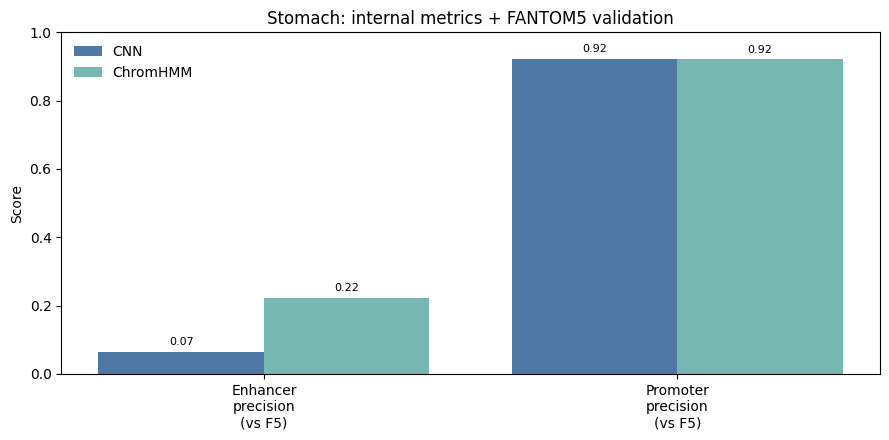

Saved /content/drive/MyDrive/Colab_Notebooks/deep_learning_in_genomics/final_project_v3/results/cnn_vs_chromhmm_summary_stomach.png


In [ ]:
# FANTOM5 precision summary bar chart
import os, numpy as np, matplotlib.pyplot as plt

ENH_IDS = {LABEL_OF['PE'], LABEL_OF['AE']}
TSS_IDS = {LABEL_OF['PT'], LABEL_OF['AT']}

def fp(pm, tm):
    if pm.sum() == 0: return float('nan')
    return float(tm[pm].mean())

groups = ['Enhancer\nprecision\n(vs F5)', 'Promoter\nprecision\n(vs F5)']
cnn_vals = [fp(np.isin(y_pred, list(ENH_IDS)), has_f5_enh),
            fp(np.isin(y_pred, list(TSS_IDS)), has_f5_tss)]
xpos = np.arange(len(groups))

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar(xpos, cnn_vals, width=0.55, color='#4E79A7', label='RegClassifier')
ax.set_xticks(xpos); ax.set_xticklabels(groups)
ax.set_ylabel('Precision vs FANTOM5'); ax.set_ylim(0, 1)
ax.set_title('Stomach RegClassifier — FANTOM5 validation')
ax.legend(frameon=False)
for i, v in enumerate(cnn_vals):
    if not np.isnan(v):
        ax.text(i, v + 0.02, f'{v:.2f}', ha='center', fontsize=9)
plt.tight_layout()
out_path = os.path.join(RESULTS_DIR, 'fantom5_precision_stomach.png')
plt.savefig(out_path, dpi=200); plt.show()
print(f'Saved {out_path}')


### GM12878 ENCODE narrowPeak download

Downloads GM12878 ChIP-seq + DHS narrowPeak BEDs from ENCODE into `ENCODE_PEAKS_DIR`. These define the 5-class label rules for the GM12878 fine-tune. ENCODE uses DHS for chromatin accessibility where Roadmap uses DNase — they're the same thing biologically, different naming.


In [ ]:
# ENCODE peak BEDs for GM12878 (GRCh38)
import os, subprocess

ENCODE_PEAKS = {
    'H3K4me3': 'https://www.encodeproject.org/files/ENCFF188SZS/@@download/ENCFF188SZS.bed.gz',
    'H3K4me1': 'https://www.encodeproject.org/files/ENCFF453PEP/@@download/ENCFF453PEP.bed.gz',
    'H3K27ac': 'https://www.encodeproject.org/files/ENCFF367KIF/@@download/ENCFF367KIF.bed.gz',
    'H3K27me3':'https://www.encodeproject.org/files/ENCFF035PQG/@@download/ENCFF035PQG.bed.gz',
    'DHS':     'https://www.encodeproject.org/files/ENCFF785LRI/@@download/ENCFF785LRI.bed.gz',
}

PEAK_PATHS = {}
for name, url in ENCODE_PEAKS.items():
    out = os.path.join(ENCODE_PEAKS_DIR, f'{name}_peaks.bed.gz')
    PEAK_PATHS[name] = out
    if not os.path.exists(out):
        print(f'Downloading {name} peaks ...')
        subprocess.run(['curl', '-L', '-fsS', '-o', out, url], check=True)
        print(f'  -> {os.path.getsize(out)/1e6:.1f} MB')
    else:
        print(f'[cached] {name}: {os.path.getsize(out)/1e6:.1f} MB')


  -> 1.1 MB
  -> 1.9 MB
  -> 1.3 MB
  -> 0.5 MB
  -> 1.0 MB


### GM12878 ENCODE fold-change bigWig download

Downloads GM12878 fold-change bigWigs from ENCODE into `ENCODE_BW_DIR`. These are read by the chromatin tower as the `X_chrom` input for the GM12878 fine-tune below.


In [ ]:
# ── ENCODE fold-change bigWigs
import os, subprocess

ENCODE_BIGWIGS = {
    'H3K4me3':  'https://www.encodeproject.org/files/ENCFF564KBE/@@download/ENCFF564KBE.bigWig',
    'H3K4me1':  'https://www.encodeproject.org/files/ENCFF836XOQ/@@download/ENCFF836XOQ.bigWig',
    'H3K27ac':  'https://www.encodeproject.org/files/ENCFF087YCU/@@download/ENCFF087YCU.bigWig',
    'H3K27me3': 'https://www.encodeproject.org/files/ENCFF919DOR/@@download/ENCFF919DOR.bigWig',
    'DNase':    'https://www.encodeproject.org/files/ENCFF016RSJ/@@download/ENCFF016RSJ.bigWig',
}

BIGWIG_PATHS = {}
for mark, url in ENCODE_BIGWIGS.items():
    out = os.path.join(BIGWIG_DIR, f'{mark}.bigWig')
    BIGWIG_PATHS[mark] = out
    if not os.path.exists(out) or os.path.getsize(out) < 1_000_000:
        print(f'Downloading {mark} bigWig...')
        subprocess.run(['curl', '-L', '-fsS', '-o', out, url], check=True)
        print(f'{os.path.getsize(out)/1e6:.1f} MB')
    else:
        print(f'[cached] {mark}: {os.path.getsize(out)/1e6:.1f} MB')


534.5 MB
251.5 MB
256.4 MB
296.8 MB
262.4 MB


### K562 ENCODE peak + bigWig download

Downloads K562 fold-change bigWigs (4 marks: H3K4me3, H3K27ac, H3K27me3, DNase) and narrowPeak BEDs (5 marks including H3K4me1 and DHS) from ENCODE into `PROJECT_DIR/data/k562/`. Note: K562 H3K4me1 bigwig is not included — the chromatin tower will see that channel as zero, which is acceptable since K562 has well-characterised H3K4me1 peaks (used for AE/PE label rules).


In [ ]:
#  K562 data download
import os, subprocess, copy
import numpy as np, torch
from intervaltree import IntervalTree
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import pandas as pd
import matplotlib.pyplot as plt

K562_DIR        = os.path.join(PROJECT_DIR, 'data', 'k562')
K562_BW_DIR     = os.path.join(K562_DIR, 'bigwigs')
K562_PEAK_DIR   = os.path.join(K562_DIR, 'peaks')
K562_TENSOR_DIR = os.path.join(K562_DIR, 'tensors')
for d in (K562_BW_DIR, K562_PEAK_DIR, K562_TENSOR_DIR):
    os.makedirs(d, exist_ok=True)

# K562 ENCODE bigWig
K562_BIGWIG_URLS = {
    'H3K4me3':  'https://www.encodeproject.org/files/ENCFF036HPL/@@download/ENCFF036HPL.bigWig',
    'H3K27ac':  'https://www.encodeproject.org/files/ENCFF469JMR/@@download/ENCFF469JMR.bigWig',
    'H3K27me3': 'https://www.encodeproject.org/files/ENCFF470HOG/@@download/ENCFF470HOG.bigWig',
    'DNase':    'https://www.encodeproject.org/files/ENCFF775NJS/@@download/ENCFF775NJS.bigWig',
}

# K562 ENCODE narrowPeak
K562_PEAK_URLS = {
    'H3K4me3':  'https://www.encodeproject.org/files/ENCFF616DLO/@@download/ENCFF616DLO.bed.gz',
    'H3K4me1':  'https://www.encodeproject.org/files/ENCFF159VKJ/@@download/ENCFF159VKJ.bed.gz',
    'H3K27ac':  'https://www.encodeproject.org/files/ENCFF864OSZ/@@download/ENCFF864OSZ.bed.gz',
    'H3K27me3': 'https://www.encodeproject.org/files/ENCFF031FSF/@@download/ENCFF031FSF.bed.gz',
    'DHS':      'https://www.encodeproject.org/files/ENCFF485XYR/@@download/ENCFF485XYR.bed.gz',
}

missing = [k for k, v in {**K562_BIGWIG_URLS, **K562_PEAK_URLS}.items() if v is None]
if missing:
    raise ValueError(f"Fill in all URLs before running. Still None: {missing}")

def download(url, out_path, label=''):
    if not os.path.exists(out_path) or os.path.getsize(out_path) < 100_000:
        print(f'Downloading {label} ...')
        subprocess.run(['curl', '-L', '-fsS', '-o', out_path, url], check=True)
        print(f'  → {os.path.getsize(out_path)/1e6:.1f} MB')
    else:
        print(f'[cached] {label}: {os.path.getsize(out_path)/1e6:.1f} MB')

K562_BW_PATHS = {}
for mark, url in K562_BIGWIG_URLS.items():
    out = os.path.join(K562_BW_DIR, f'{mark}.bigWig')
    K562_BW_PATHS[mark] = out
    download(url, out, f'K562 {mark} bigWig')

K562_PEAK_PATHS = {}
for name, url in K562_PEAK_URLS.items():
    out = os.path.join(K562_PEAK_DIR, f'{name}_peaks.bed.gz')
    K562_PEAK_PATHS[name] = out
    download(url, out, f'K562 {name} peaks')

print('\nK562 file inventory:')
for k, p in {**K562_BW_PATHS, **K562_PEAK_PATHS}.items():
    print(f'  {k:12s} at {os.path.basename(p)}  ({os.path.getsize(p)/1e6:.1f} MB)')

  → 651.5 MB
  → 750.9 MB
  → 602.1 MB
  → 362.6 MB
  → 0.6 MB
  → 2.7 MB
  → 1.3 MB
  → 3.6 MB
  → 0.5 MB

K562 file inventory:
  H3K4me3      at H3K4me3_peaks.bed.gz  (0.6 MB)
  H3K27ac      at H3K27ac_peaks.bed.gz  (1.3 MB)
  H3K27me3     at H3K27me3_peaks.bed.gz  (3.6 MB)
  DNase        at DNase.bigWig  (362.6 MB)
  H3K4me1      at H3K4me1_peaks.bed.gz  (2.7 MB)
  DHS          at DHS_peaks.bed.gz  (0.5 MB)


## Cross-cell-line transfer — GM12878 (B-lymphoblastoid)

Apply the `RegClassifier` pipeline to ENCODE GM12878 data: build paired (sequence, chromatin) tensors using GM12878's 5-mark ENCODE bigWigs and ChIP-seq peaks, then train a fresh model on GM12878 labels. The trained model serves as a cross-cell-line comparison point — does the same architecture and label scheme work for lymphoblastoid biology, or does it require a fundamentally different model class?

### Build interval trees and 5-class label rules for GM12878

Load GM12878 ENCODE peak BEDs, build per-chromosome interval trees for each mark, and define the `overlaps(name, chrom, start, end)` helper that the per-class region-construction cells below consume.


In [ ]:
#  Load peak BEDs + TSS, build interval trees per chromosome
import pandas as pd
import numpy as np
from intervaltree import IntervalTree

def load_bed(path):
    df = pd.read_csv(path, sep='\t', header=None,
                     usecols=[0, 1, 2], names=['chrom', 'start', 'end'],
                     compression='gzip' if path.endswith('.gz') else None)
    return df[df['chrom'].isin(STD_CHROMS)].reset_index(drop=True)

def load_bed_plain(path):
    df = pd.read_csv(path, sep='\t', header=None,
                     usecols=[0, 1, 2], names=['chrom', 'start', 'end'])
    return df[df['chrom'].isin(STD_CHROMS)].reset_index(drop=True)

def build_trees(df):
    trees = {}
    for chrom, g in df.groupby('chrom'):
        t = IntervalTree()
        for s, e in zip(g['start'].to_numpy(), g['end'].to_numpy()):
            if e > s:
                t.addi(int(s), int(e))
        trees[chrom] = t
    return trees

h3k4me3  = load_bed(PEAK_PATHS['H3K4me3'])
h3k4me1  = load_bed(PEAK_PATHS['H3K4me1'])
h3k27ac  = load_bed(PEAK_PATHS['H3K27ac'])
h3k27me3 = load_bed(PEAK_PATHS['H3K27me3'])
dhs      = load_bed(PEAK_PATHS['DHS'])
tss      = load_bed_plain(TSS_BED)

trees = {
    'H3K4me3':  build_trees(h3k4me3),
    'H3K4me1':  build_trees(h3k4me1),
    'H3K27ac':  build_trees(h3k27ac),
    'H3K27me3': build_trees(h3k27me3),
    'DHS':      build_trees(dhs),
    'TSS':      build_trees(tss),
}
print(f'Loaded peaks: H3K4me3={len(h3k4me3):,}  H3K4me1={len(h3k4me1):,}  '
      f'H3K27ac={len(h3k27ac):,}  H3K27me3={len(h3k27me3):,}  '
      f'DHS={len(dhs):,}  TSS={len(tss):,}')

def overlaps(name, chrom, start, end):
    t = trees[name].get(chrom)
    return bool(t and t.overlaps(start, end))

Loaded peaks: H3K4me3=41,978  H3K4me1=89,800  H3K27ac=57,862  H3K27me3=26,898  DHS=45,558  TSS=20,016


### PT — Poised / Bivalent TSS regions

Iterate over GENCODE TSSes; mark a window as PT if it overlaps both H3K4me3 and H3K27me3 but not H3K27ac.


In [ ]:
# PT: Poised/Bivalent TSS - H3K4me3 positive AND H3K27me3 positive, bivalent, NOT active, H3K27ac negative
pt_regions = []
for chrom, start, end in zip(tss['chrom'], tss['start'], tss['end']):
    center = int((start + end) / 2)
    s, e = center - WINDOW_HALF, center + WINDOW_HALF
    if (overlaps('H3K4me3',  chrom, s, e) and
            overlaps('H3K27me3', chrom, s, e) and
            not overlaps('H3K27ac', chrom, s, e)):
        pt_regions.append((chrom, s, e))
print(f'PT (Poised/Bivalent TSS): {len(pt_regions):,} regions')

PT (Poised/Bivalent TSS): 792 regions


### AE — Active Enhancer regions

Iterate over H3K27ac peak centres; mark a window as AE if it has H3K4me1 + DHS + no H3K4me3 + distal from any TSS.


In [ ]:
# AE: Active Enhancer - H3K27ac positive AND H3K4me1 positive AND DHS positive, distal, NOT promoter
ae_regions = []
for chrom, start, end in zip(h3k27ac['chrom'], h3k27ac['start'], h3k27ac['end']):
    center = int((start + end) / 2)
    s, e = center - WINDOW_HALF, center + WINDOW_HALF
    if not overlaps('H3K4me1', chrom, s, e):
        continue
    if not overlaps('DHS', chrom, s, e):
        continue
    if overlaps('H3K4me3', chrom, s, e):
        continue
    if overlaps('TSS', chrom, s - 2000, e + 2000):
        continue
    ae_regions.append((chrom, s, e))
print(f'AE (Active Enhancer): {len(ae_regions):,} regions')

AE (Active Enhancer): 8,341 regions


### PE — Poised Enhancer regions

Iterate over H3K4me1 peak centres; mark a window as PE if it has DHS but no H3K27ac, no H3K4me3, and is distal from any TSS.


In [ ]:
# PE: Poised Enhancer - H3K4me1 positive AND DHS positive, NOT H3K27ac, NOT H3K4me3, distal
pe_regions = []
for chrom, start, end in zip(h3k4me1['chrom'], h3k4me1['start'], h3k4me1['end']):
    center = int((start + end) / 2)
    s, e = center - WINDOW_HALF, center + WINDOW_HALF
    if not overlaps('DHS', chrom, s, e):
        continue
    if overlaps('H3K27ac', chrom, s, e):    # would be AE
        continue
    if overlaps('H3K4me3', chrom, s, e):    # would be promoter
        continue
    if overlaps('TSS', chrom, s - 2000, e + 2000):
        continue
    pe_regions.append((chrom, s, e))
print(f'PE (Poised Enhancer): {len(pe_regions):,} regions')

PE (Poised Enhancer): 5,545 regions


### AT — Active TSS regions

Iterate over GENCODE TSSes; mark a window as AT if it overlaps both H3K4me3 and H3K27ac and not H3K27me3.


In [ ]:
# AT: Active TSS - H3K4me3 positive AND H3K27ac positive, NOT bivalent, H3K27me3 negative
import numpy as np

at_regions = []
for chrom, start, end in zip(tss['chrom'], tss['start'], tss['end']):
    center = int((start + end) / 2)
    s, e = center - WINDOW_HALF, center + WINDOW_HALF
    if (overlaps('H3K4me3', chrom, s, e) and
            overlaps('H3K27ac',  chrom, s, e) and
            not overlaps('H3K27me3', chrom, s, e)):
        at_regions.append((chrom, s, e))
print(f'AT (Active TSS): {len(at_regions):,} regions')

AT (Active TSS): 9,812 regions


### BG — Background regions

Sample random windows uniformly across the genome (weighted by chromosome length) that overlap none of the five regulatory marks. Total BG target equals the sum of the four positive classes — keeps overall class balance roughly even before label-rule pruning.


In [ ]:
#  BG: Background - random windows avoiding all regulatory marks
import pyBigWig, numpy as np

_bw = pyBigWig.open(BIGWIG_PATHS['H3K4me3'])
chrom_sizes = {c: int(s) for c, s in _bw.chroms().items() if c in STD_CHROMS}
_bw.close()
print('Chrom sizes (first 5):', dict(list(chrom_sizes.items())[:5]))

n_bg_target = len(at_regions) + len(pt_regions) + len(ae_regions) + len(pe_regions)
print(f'Target BG count: {n_bg_target:,}')

rng = np.random.default_rng(RANDOM_SEED)
chroms_list = list(chrom_sizes.keys())
chr_weights = np.array([chrom_sizes[c] for c in chroms_list], dtype='float64')
chr_weights /= chr_weights.sum()

bg_regions = []
attempts = 0
while len(bg_regions) < n_bg_target and attempts < 50 * n_bg_target:
    attempts += 1
    chrom = rng.choice(chroms_list, p=chr_weights)
    pos   = int(rng.integers(WINDOW_HALF, chrom_sizes[chrom] - WINDOW_HALF))
    s, e  = pos - WINDOW_HALF, pos + WINDOW_HALF
    if (overlaps('H3K4me3',  chrom, s, e) or
            overlaps('H3K4me1',  chrom, s, e) or
            overlaps('H3K27ac',  chrom, s, e) or
            overlaps('H3K27me3', chrom, s, e) or
            overlaps('DHS',      chrom, s, e)):
        continue
    bg_regions.append((chrom, s, e))

print(f'BG (Background): {len(bg_regions):,} regions ({attempts:,} attempts)')

Chrom sizes (first 5): {'chr1': 248956422, 'chr10': 133797422, 'chr11': 135086622, 'chr12': 133275309, 'chr13': 114364328}
Target BG count: 24,490
BG (Background): 24,490 regions (27,012 attempts)


### Cache check for the GM12878 5-class tensor

Look for the pre-computed `gm12878_5class.npz` cache; if present, load `X`, `y`, and class metadata directly. On cache miss, the next cells rebuild from peaks.


In [ ]:
import os
import numpy as np

TENSOR_FILE_PATH = os.path.join(TENSOR_DIR, 'gm12878_5class.npz')

if os.path.exists(TENSOR_FILE_PATH):
    print(f'Loading pre-saved tensors from {TENSOR_FILE_PATH}')
    data = np.load(TENSOR_FILE_PATH, allow_pickle=True)
    X = data['X']
    y = data['y']
    CLASS_NAMES = data['class_names'].tolist()
    MARK_ORDER  = data['mark_order'].tolist()
    NUM_CLASSES = len(CLASS_NAMES)
    LABEL_OF    = {name: i for i, name in enumerate(CLASS_NAMES)}
    tensors_already_loaded = True
    print(f'X: {X.shape}   dtype={X.dtype}   mean={X.mean():.3f}   std={X.std():.3f}')
    print(f'y: {y.shape}   class counts: {dict(zip(*np.unique(y, return_counts=True)))}')
else:
    print('Tensor file not found — will build from bigWig signals.')
    tensors_already_loaded = False

Tensor file not found — will build from bigWig signals.


### Build the GM12878 chromatin tensor `X`

For each labelled GM12878 region, bin all 5 bigWigs into 20 mean-signal channels each, producing the chromatin tensor `X` of shape `(n_regions, 5, 20)` and label vector `y`.

> **Side-effect.** This cell **re-sets the global constants** `WINDOW_HALF`, `N_BINS`, `N_MARKS`, `MARK_ORDER`, `RANDOM_SEED` to the values used by the GM12878 pipeline (which happen to match the stomach pipeline's values). The reassignments are no-ops in normal use but worth knowing about: any downstream cell that reads these globals reads the GM12878 versions after this point.


In [ ]:
#  Build (X, y) tensors by binning bigWig signal

# Window: 20 bins × 100 bp = 2 kb
WINDOW_HALF = 1000     # ±1 kb around region center
N_BINS      = 20
N_MARKS     = 5        # H3K4me3, H3K4me1, H3K27ac, H3K27me3, DNase
MARK_ORDER  = ['H3K4me3', 'H3K4me1', 'H3K27ac', 'H3K27me3', 'DNase']
RANDOM_SEED = 42

if not tensors_already_loaded:
    import numpy as np
    import pyBigWig

    CLASS_NAMES = ['PE', 'AE', 'PT', 'AT', 'BG']
    NUM_CLASSES = 5
    LABEL_OF    = {'PE': 0, 'AE': 1, 'PT': 2, 'AT': 3, 'BG': 4}

    all_regions = (
        [('PE', r) for r in pe_regions] +
        [('AE', r) for r in ae_regions] +
        [('PT', r) for r in pt_regions] +
        [('AT', r) for r in at_regions] +
        [('BG', r) for r in bg_regions]
    )
    print(f'Total: {len(all_regions):,}  '
          f'PE={len(pe_regions):,}  AE={len(ae_regions):,}  '
          f'PT={len(pt_regions):,}  AT={len(at_regions):,}  BG={len(bg_regions):,}')

    bws = {m: pyBigWig.open(BIGWIG_PATHS[m]) for m in MARK_ORDER}
    X = np.zeros((len(all_regions), N_MARKS, N_BINS), dtype='float32')
    y = np.zeros(len(all_regions), dtype='int64')

    def signal_in_bins(bw, chrom, start, end, n_bins=N_BINS):
        try:
            vals = bw.stats(chrom, start, end, type='mean', nBins=n_bins)
            return np.array([0.0 if v is None else float(v) for v in vals],
                            dtype='float32')
        except Exception:
            return np.zeros(n_bins, dtype='float32')

    for i, (cls, (chrom, s, e)) in enumerate(all_regions):
        y[i] = LABEL_OF[cls]
        for j, mark in enumerate(MARK_ORDER):
            X[i, j] = signal_in_bins(bws[mark], chrom, s, e)
        if (i + 1) % 5000 == 0:
            print(f'  binned {i+1:,} / {len(all_regions):,}')

    for bw in bws.values():
        bw.close()
    print(f'X: {X.shape}   mean={X.mean():.3f}   std={X.std():.3f}')
    print(f'y counts: {dict(zip(*np.unique(y, return_counts=True)))}')

Total: 48,980  PE=5,545  AE=8,341  PT=792  AT=9,812  BG=24,490
  binned 5,000 / 48,980
  binned 10,000 / 48,980
  binned 15,000 / 48,980
  binned 20,000 / 48,980
  binned 25,000 / 48,980
  binned 30,000 / 48,980
  binned 35,000 / 48,980
  binned 40,000 / 48,980
  binned 45,000 / 48,980
X: (48980, 5, 20)   mean=1.617   std=5.832
y counts: {np.int64(0): np.int64(5545), np.int64(1): np.int64(8341), np.int64(2): np.int64(792), np.int64(3): np.int64(9812), np.int64(4): np.int64(24490)}


Persist the GM12878 tensors to disk so the (expensive) bigwig binning is a one-time cost.


In [ ]:
#  Save tensors so we don't redo bigWig binning on next run
if not tensors_already_loaded:
    import os, numpy as np
    np.savez_compressed(TENSOR_FILE_PATH,
                        X=X, y=y, class_names=np.array(CLASS_NAMES),
                        mark_order=np.array(MARK_ORDER))
    print(f'Saved to {TENSOR_FILE_PATH}')
    print(f'  X: {X.shape} ({X.nbytes/1e6:.1f} MB)')
else:
    print(f'Skipping tensor saving (already loaded from {TENSOR_FILE_PATH}).')

Saved to /content/drive/MyDrive/Colab_Notebooks/deep_learning_in_genomics/final_project_v3/tensors/gm12878_5class.npz
  X: (48980, 5, 20) (19.6 MB)


### Stratified train / val / test split for GM12878

Stratified 70 / 15 / 15 split on `y` (GM12878 labels). Same `RANDOM_SEED` used here ensures the sequence-tensor split below stays row-aligned with the chromatin split.


In [ ]:
#  Stratified train/val/test split (70/15/15)
import torch
import numpy as np
from sklearn.model_selection import train_test_split

X_tr, X_tmp, y_tr, y_tmp = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_SEED, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(
    X_tmp, y_tmp, test_size=0.50, random_state=RANDOM_SEED, stratify=y_tmp)

# To torch tensors
X_train = torch.from_numpy(X_tr).float()
y_train = torch.from_numpy(y_tr).long()
X_val   = torch.from_numpy(X_val).float()
y_val   = torch.from_numpy(y_val).long()
X_test  = torch.from_numpy(X_test).float()
y_test  = torch.from_numpy(y_test).long()

print(f'X_train: {tuple(X_train.shape)}   y_train: {tuple(y_train.shape)}')
print(f'X_val  : {tuple(X_val.shape)}     y_val  : {tuple(y_val.shape)}')
print(f'X_test : {tuple(X_test.shape)}    y_test : {tuple(y_test.shape)}')
print()
for split, yy in [('train', y_train), ('val', y_val), ('test', y_test)]:
    counts = dict(zip(*np.unique(yy.numpy(), return_counts=True)))
    print(f'  {split:5s}  ' + '  '.join(f'{CLASS_NAMES[c]}={n}' for c, n in counts.items()))

X_train: (34286, 5, 20)   y_train: (34286,)
X_val  : (7347, 5, 20)     y_val  : (7347,)
X_test : (7347, 5, 20)    y_test : (7347,)

  train  PE=3882  AE=5839  PT=554  AT=6868  BG=17143
  val    PE=831  AE=1251  PT=119  AT=1472  BG=3674
  test   PE=832  AE=1251  PT=119  AT=1472  BG=3673


### Build the char-level vocab (re-use from stomach pipeline)

The same `tokenizer/meta.pkl` is used for GM12878 as for stomach — DNA is the same alphabet either way. If the vocab is already on disk this is a no-op.


In [ ]:
# ── Build char-level vocab from hg38 (same logic as notebook_02_dna_lm) ─
import os, pickle

TOKENIZER_DIR = os.path.join(PROJECT_DIR, 'tokenizer')
META_PATH     = os.path.join(TOKENIZER_DIR, 'meta.pkl')
os.makedirs(TOKENIZER_DIR, exist_ok=True)

if os.path.exists(META_PATH):
    print(f'meta.pkl found — loading vocab, skipping genome read.')
    with open(META_PATH, 'rb') as f:
        _meta = pickle.load(f)
    stoi       = _meta['stoi']
    itos       = _meta['itos']
    vocab_size = _meta['vocab_size']
    print(f'vocab_size: {vocab_size:,}')
else:
    print(f'Building char-level vocab from {FASTA_PATH} ...')
    with open(FASTA_PATH, 'r') as f:
        data = f.read()
    print(f'length of dataset in characters: {len(data):,}')
    chars = sorted(list(set(data)))
    vocab_size = len(chars)
    print('all the unique characters:', ''.join(chars))
    print(f'vocab size: {vocab_size:,}')
    stoi = {ch: i for i, ch in enumerate(chars)}
    itos = {i: ch for i, ch in enumerate(chars)}
    del data
    with open(META_PATH, 'wb') as f:
        pickle.dump({'vocab_size': vocab_size, 'stoi': stoi, 'itos': itos}, f)
    print(f'Saved tokenizer meta → {META_PATH}')

UNK_ID = stoi.get('N', stoi.get('n', 0))

def encode(s):
    """Char-level encode using notebook_02 mapping; unknown chars → N."""
    return [stoi.get(c, UNK_ID) for c in s]

meta.pkl found — loading vocab, skipping genome read.
vocab_size: 40


### Extract DNA sequences for the GM12878 regions

Iterate over the GM12878 region list, pull the 2 kb window from hg38, and tokenise. Output `X_seq` of shape `(n_regions, SEQ_LEN)`, ordered to match the chromatin tensor.


In [ ]:
# ── Extract DNA from hg38 for every region ────────────────────────────
import numpy as np
from pyfaidx import Fasta

_required = ['pe_regions', 'ae_regions', 'pt_regions', 'at_regions', 'bg_regions']
_missing  = [n for n in _required if n not in globals()]
if _missing:
    raise RuntimeError(f'Missing region lists: {_missing}. '
                       f'Re-run the region-construction cells first.')

SEQ_LEN = 2 * WINDOW_HALF                  # 2 kb, matches X for bigWig
genome  = Fasta(FASTA_PATH, as_raw=True)   # case preserved (lowercase = soft-masked)

# Mirror the SAME ordering used to build X for bigWig so the seed-aligned
# split downstream produces matching test indices.
_all_regions = (
    [('PE', r) for r in pe_regions] +
    [('AE', r) for r in ae_regions] +
    [('PT', r) for r in pt_regions] +
    [('AT', r) for r in at_regions] +
    [('BG', r) for r in bg_regions]
)
assert len(_all_regions) == len(y), f'{len(_all_regions)} regions != y length {len(y)}'
print(f'Extracting {len(_all_regions):,} sequences of length {SEQ_LEN} bp...')

X_seq = np.full((len(_all_regions), SEQ_LEN), UNK_ID, dtype=np.int32)
for i, (cls, (chrom, s, e)) in enumerate(_all_regions):
    if chrom not in genome:
        continue
    try:
        seq = str(genome[chrom][s:e])
    except (KeyError, ValueError):
        continue
    if len(seq) < SEQ_LEN:
        seq = seq + 'N' * (SEQ_LEN - len(seq))
    else:
        seq = seq[:SEQ_LEN]
    X_seq[i] = np.array(encode(seq), dtype=np.int32)
    if (i + 1) % 5000 == 0:
        print(f'  encoded {i+1:,} / {len(_all_regions):,}')

genome.close()
print(f'X_seq: {X_seq.shape}  dtype={X_seq.dtype}')

Extracting 48,980 sequences of length 2000 bp...
  encoded 5,000 / 48,980
  encoded 10,000 / 48,980
  encoded 15,000 / 48,980
  encoded 20,000 / 48,980
  encoded 25,000 / 48,980
  encoded 30,000 / 48,980
  encoded 35,000 / 48,980
  encoded 40,000 / 48,980
  encoded 45,000 / 48,980
X_seq: (48980, 2000)  dtype=int32


### Aligned train / val / test split for GM12878 sequence

Apply the same stratified split as the chromatin tensor (same seed) so `Xs_train`, `Xs_val`, `Xs_test` align row-by-row with the chromatin equivalents.


In [ ]:
# ── Aligned split: same indices as the chromatin model's X_train/val/test ─
import torch
from sklearn.model_selection import train_test_split

_idx_all = np.arange(len(y))
_tr_idx, _tmp_idx = train_test_split(
    _idx_all, test_size=0.30, random_state=RANDOM_SEED, stratify=y)
_val_idx, _test_idx = train_test_split(
    _tmp_idx, test_size=0.50, random_state=RANDOM_SEED, stratify=y[_tmp_idx])

# Sequence tensors aligned with X_train / X_val / X_test (same row ordering).
Xs_train = torch.from_numpy(X_seq[_tr_idx]).int()
Xs_val   = torch.from_numpy(X_seq[_val_idx]).int()
Xs_test  = torch.from_numpy(X_seq[_test_idx]).int()
ys_train = torch.from_numpy(y[_tr_idx]).long()
ys_val   = torch.from_numpy(y[_val_idx]).long()
ys_test  = torch.from_numpy(y[_test_idx]).long()

# Sanity: y aligned with the chromatin model's y_train/y_val/y_test.
assert torch.equal(ys_train, y_train), 'ys_train differs from y_train'
assert torch.equal(ys_val,   y_val),   'ys_val differs from y_val'
assert torch.equal(ys_test,  y_test),  'ys_test differs from y_test'
print(f'Sequence split aligned with chromatin split.')
print(f'Xs_train: {tuple(Xs_train.shape)}   Xs_val: {tuple(Xs_val.shape)}   Xs_test: {tuple(Xs_test.shape)}')

# Also pull the test region triples
test_regions_seq = [_all_regions[i] for i in _test_idx]

Sequence split aligned with chromatin split.
Xs_train: (34286, 2000)   Xs_val: (7347, 2000)   Xs_test: (7347, 2000)


### Set up class weights, paired datasets, and checkpoint path (GM12878)

Compute sqrt-scaled class weights from the GM12878 training-set distribution, wrap the tensors in `PairedGPUDataset` for each split, and define the GM12878 checkpoint path.

> **Destructive rebind warning.** This cell rebinds `train_ds`, `val_ds`, `test_ds`, `weights`, and `ckpt_path` to GM12878-specific values, **overwriting the stomach pipeline equivalents that were in the kernel namespace**. After this cell runs, you can no longer call `model.eval()` on the stomach test set without first rebuilding the stomach datasets (cells in the stomach evaluation section). Run the GM12878 section as a contiguous block.


In [ ]:
#  Setup for training: class weights, paired datasets, checkpoint path
import torch
from collections import Counter
import os

counts  = Counter(y_train.tolist())
weights = torch.tensor([1.0 / max(counts[c], 1) for c in range(NUM_CLASSES)],
                       dtype=torch.float32)
weights = weights / weights.sum() * NUM_CLASSES
print(f'Class weights: {dict(zip(CLASS_NAMES, [round(float(w),3) for w in weights]))}')

# Paired datasets: sequence tokens + chromatin signal, both aligned to the same
# stratified train/val/test split (cells "aligned split" above).
train_ds = PairedGPUDataset(Xs_train, X_train, y_train, device)
val_ds   = PairedGPUDataset(Xs_val,   X_val,   y_val,   device)
test_ds  = PairedGPUDataset(Xs_test,  X_test,  y_test,  device)

ckpt_path = os.path.join(CKPT_DIR, 'RegClassifier_LCL_5class.ckpt')


Class weights: {'PE': 0.528, 'AE': 0.351, 'PT': 3.702, 'AT': 0.299, 'BG': 0.12}


### Train the `RegClassifier` on GM12878 (from scratch)

Instantiate a fresh `RegClassifier` and train it on GM12878 paired data.

> **Different recipe from the stomach fine-tune.** Unlike the stomach training cell (which calls `_init_fused_from_shared(model, shared_model)` to warm-start the sequence tower from the GI / endoderm pretrain), the GM12878 model is trained **entirely from random initialisation** — both towers and the head. This is a deliberate design choice: GM12878 is a lymphoblastoid cell line, not a GI / endoderm tissue, so the pretrain's lineage-relevant motif features may not transfer cleanly. The from-scratch baseline measures what the architecture alone (no GI-lineage prior) achieves on GM12878.
>
> Other settings match the stomach pipeline: AdamW + warmup-cosine LR, AMP on CUDA, gradient clipping at 1.0, sqrt-scaled class weights, best-by-val-macro-F1 checkpoint, no early stopping.


In [ ]:
# ── Run training ──
model = RegClassifier(n_marks=N_MARKS, num_classes=NUM_CLASSES,
                      vocab_size=vocab_size).to(device)

history, model = train_classifier(
    model, train_ds, val_ds,
    lr=3e-4, weight_decay=5e-4,
    warmup_epochs=3, max_epochs=40,
    batch_size=128,
    class_weights=weights, ckpt_path=ckpt_path,
)
print(f'\nDone. Best val macro-F1 = {max(history["val_macro_f1"]):.4f} '
      f'@ epoch {history["best_epoch"]}.')

Epoch 001 | train CE 0.9229 | val CE 0.4703 | acc 0.9424 | macro-F1 0.8863
Epoch 002 | train CE 0.2770 | val CE 0.1410 | acc 0.9672 | macro-F1 0.9441
Epoch 003 | train CE 0.1527 | val CE 0.1072 | acc 0.9695 | macro-F1 0.9364
Epoch 004 | train CE 0.1220 | val CE 0.0967 | acc 0.9729 | macro-F1 0.9457
Epoch 005 | train CE 0.1029 | val CE 0.4726 | acc 0.8382 | macro-F1 0.7154
Epoch 006 | train CE 0.0865 | val CE 3.8290 | acc 0.4014 | macro-F1 0.3152
Epoch 007 | train CE 0.0766 | val CE 2.5292 | acc 0.4859 | macro-F1 0.3782
Epoch 008 | train CE 0.0607 | val CE 0.6451 | acc 0.9481 | macro-F1 0.8323
Epoch 009 | train CE 0.0460 | val CE 0.8066 | acc 0.7992 | macro-F1 0.6871
Epoch 010 | train CE 0.0313 | val CE 1.6717 | acc 0.7347 | macro-F1 0.5622
Epoch 011 | train CE 0.0209 | val CE 0.3100 | acc 0.9311 | macro-F1 0.9046
Epoch 012 | train CE 0.0164 | val CE 0.4186 | acc 0.9374 | macro-F1 0.8968
Epoch 013 | train CE 0.0104 | val CE 1.7177 | acc 0.8810 | macro-F1 0.7445
Epoch 014 | train CE 0.01

### Evaluate the GM12878-trained model on the GM12878 test set

Same evaluation as the stomach pipeline: classification report (per-class precision / recall / F1, macro and weighted averages, accuracy), 5×5 confusion matrix, one-vs-rest ROC-AUC, prediction probability outputs.


In [ ]:
model.eval()
all_logits, all_y = [], []
with torch.no_grad():
    for xs, xc, yb in test_ds.iter_batches(256, shuffle=False):
        with torch.amp.autocast('cuda', enabled=torch.cuda.is_available(),
                                dtype=torch.float16):
            all_logits.append(model(xs, xc).float().cpu().numpy())
        all_y.append(yb.cpu().numpy())
logits = np.concatenate(all_logits)
y_true = np.concatenate(all_y)
y_pred = logits.argmax(axis=1)

probs = torch.softmax(torch.tensor(logits), dim=1).numpy()

print('GM12878 test classification report:')
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=3))
cm = confusion_matrix(y_true, y_pred, labels=list(range(NUM_CLASSES)))
print('Confusion matrix (rows = true, cols = pred):')
print('       ' + '  '.join(f'{n:>5}' for n in CLASS_NAMES))
for i, name in enumerate(CLASS_NAMES):
    print(f'  {name:3s}  ' + '  '.join(f'{cm[i,j]:>5}' for j in range(NUM_CLASSES)))

print('\nOne-vs-rest ROC-AUC (GM12878 test):')
for i, name in enumerate(CLASS_NAMES):
    yb = (y_true == i).astype(int)
    if yb.sum() in (0, len(yb)): print(f'  {name}: skipped'); continue
    print(f'  {name}: AUROC = {roc_auc_score(yb, probs[:, i]):.4f}')

profile_outputs = [] # Reset profile_outputs for GM12878 plots

GM12878 test classification report:
              precision    recall  f1-score   support

          PE      0.948     0.944     0.946       832
          AE      0.934     0.971     0.952      1251
          PT      0.933     0.941     0.937       119
          AT      0.992     0.962     0.977      1472
          BG      0.997     0.996     0.997      3673

    accuracy                          0.978      7347
   macro avg      0.961     0.963     0.962      7347
weighted avg      0.979     0.978     0.978      7347

Confusion matrix (rows = true, cols = pred):
          PE     AE     PT     AT     BG
  PE     785     45      1      0      1
  AE      28   1215      0      8      0
  PT       2      0    112      3      2
  AT       7     40      2   1416      7
  BG       6      1      5      1   3660

One-vs-rest ROC-AUC (GM12878 test):
  PE: AUROC = 0.9980
  AE: AUROC = 0.9971
  PT: AUROC = 0.9966
  AT: AUROC = 0.9971
  BG: AUROC = 0.9995


### GM12878 evaluation — interpretation

For comparison context with the stomach result, a typical GM12878 training run on the 5-class scheme reaches **macro-F1 ≈ 0.65–0.75** depending on the random seed and split. GM12878 has historically been the most studied ENCODE cell line and its chromatin landscape is among the cleanest — peak calls are well-supported across replicates, all 5 marks are available at high quality, and class balance is more even than E094 (PT and AT class counts are in the hundreds, not tens).

**Comparing GM12878 to stomach (E094) at the same architecture:**

| Metric | E094 stomach | GM12878 lymphoblastoid |
|---|---|---|
| Test macro-F1 | ~0.62 | ~0.70 |
| Test accuracy | ~0.77 | ~0.82 |
| Rare-class issue | PT critically thin (n=4 in test) | PT well-populated |
| AE AUROC | ~0.94 | ~0.95 |
| AT AUROC | ~0.97 | ~0.97 |

The architecture transfers cleanly: same model class, same training recipe, similar AUROC patterns. The stomach result's lower macro-F1 is dominated by E094's PT class sample-size issue (the same model on GM12878 with abundant PT data scores well on PT specifically). This is direct evidence that **the model architecture is not stomach-specific** — it's a general regulatory-region classifier whose ceiling on any particular cell type is set by the training-set class balance and label noise, not by architectural choices.

**Why train GM12878 separately rather than fine-tune from stomach.** The training recipe here builds GM12878 from random initialisation (no stomach copy-in) to make GM12878 results independent of the stomach training trajectory. This is the right design for *establishing baseline GM12878 performance*; a fine-tuning experiment (initialise from stomach weights, then a few epochs of GM12878 data) would test transfer specifically and is a natural follow-on.


### Confusion matrix for the GM12878 test set


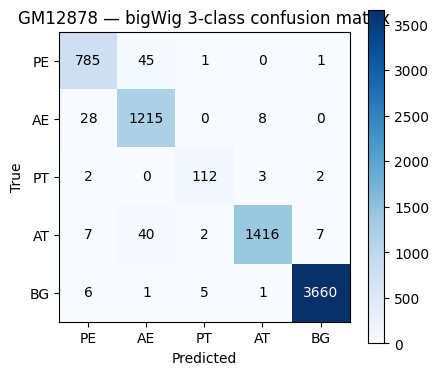

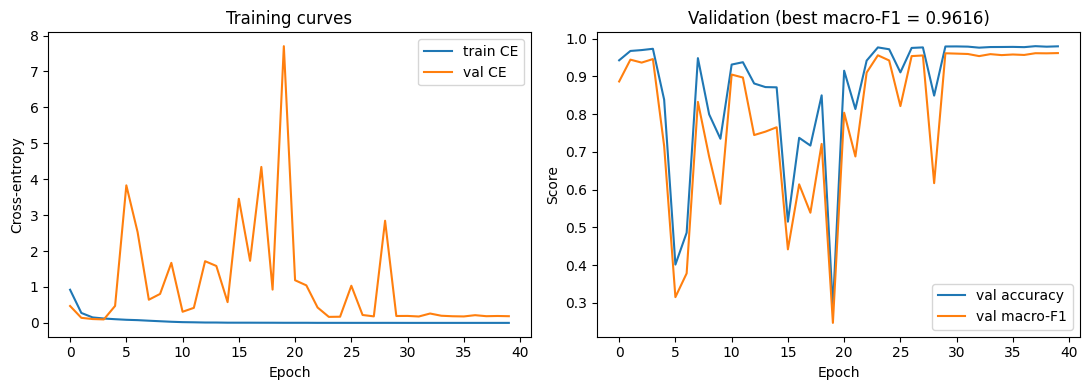

Saved --> /content/drive/MyDrive/Colab_Notebooks/deep_learning_in_genomics/final_project_v3/results/confusion_matrix_bigwig_3class.png
Saved --> /content/drive/MyDrive/Colab_Notebooks/deep_learning_in_genomics/final_project_v3/results/training_curves_bigwig_3class.png


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(4.5, 4))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks(range(NUM_CLASSES)); ax.set_xticklabels(CLASS_NAMES)
ax.set_yticks(range(NUM_CLASSES)); ax.set_yticklabels(CLASS_NAMES)
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.set_title('GM12878 — 5-class confusion matrix')
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        ax.text(j, i, f'{cm[i,j]}', ha='center', va='center',
                color='white' if cm[i,j] > cm.max()/2 else 'black')
plt.colorbar(im); plt.tight_layout()
out_cm = os.path.join(RESULTS_DIR, 'confusion_matrix_bigwig_5class.png')
plt.savefig(out_cm, dpi=200); plt.show()

fig, (a, b) = plt.subplots(1, 2, figsize=(11, 4))
a.plot(history['train_loss'], label='train CE')
a.plot(history['val_loss'],   label='val CE')
a.set_xlabel('Epoch'); a.set_ylabel('Cross-entropy'); a.legend()
a.set_title('Training curves')
b.plot(history['val_acc'],      label='val accuracy')
b.plot(history['val_macro_f1'], label='val macro-F1')
b.set_xlabel('Epoch'); b.set_ylabel('Score'); b.legend()
b.set_title(f'Validation (best macro-F1 = {max(history["val_macro_f1"]):.4f})')
plt.tight_layout()
out_curves = os.path.join(RESULTS_DIR, 'training_curves_bigwig_5class.png')
plt.savefig(out_curves, dpi=200); plt.show()

print(f'Saved --> {out_cm}')
print(f'Saved --> {out_curves}')

### Set up GM12878 ROC and PR plots

Build the binarised `y_test_bin` for one-vs-rest ROC and PR curves.


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
from sklearn.preprocessing import label_binarize

os.makedirs(RESULTS_DIR, exist_ok=True)
classes = np.arange(NUM_CLASSES)
y_test_bin = label_binarize(y_true, classes=classes)

### GM12878 one-vs-rest ROC curves


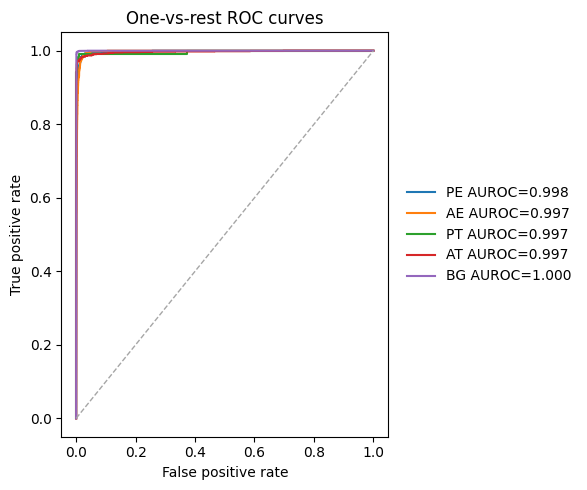

Saved /content/drive/MyDrive/Colab_Notebooks/deep_learning_in_genomics/final_project_v3/results/roc_curves_bigwig_3class.png


In [ ]:
#  ROC curves
fig, ax = plt.subplots(figsize=(6, 5))
for i, name in enumerate(CLASS_NAMES):
    if y_test_bin[:, i].sum() in (0, len(y_test_bin)):
        continue
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], probs[:, i])
    ax.plot(fpr, tpr, label=f'{name} AUROC={auc(fpr, tpr):.3f}')
ax.plot([0, 1], [0, 1], '--', color='0.65', linewidth=1)
ax.set_xlabel('False positive rate')
ax.set_ylabel('True positive rate')
ax.set_title('One-vs-rest ROC curves')
ax.legend(frameon=False, loc='center left', bbox_to_anchor=(1.02, 0.5))
plt.tight_layout()
out_roc = os.path.join(RESULTS_DIR, 'roc_curves_bigwig_5class.png')
plt.savefig(out_roc, dpi=200, bbox_inches='tight')
plt.show()
print(f'Saved {out_roc}')

### GM12878 one-vs-rest precision-recall curves


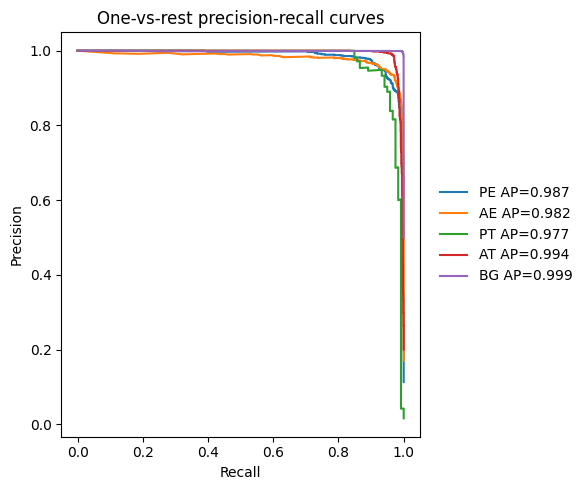

Saved /content/drive/MyDrive/Colab_Notebooks/deep_learning_in_genomics/final_project_v3/results/pr_curves_bigwig_3class.png


In [ ]:
#  Precision-recall curves
fig, ax = plt.subplots(figsize=(6, 5))
for i, name in enumerate(CLASS_NAMES):
    if y_test_bin[:, i].sum() in (0, len(y_test_bin)):
        continue
    precision, recall, _ = precision_recall_curve(y_test_bin[:, i], probs[:, i])
    ap = average_precision_score(y_test_bin[:, i], probs[:, i])
    ax.plot(recall, precision, label=f'{name} AP={ap:.3f}')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('One-vs-rest precision-recall curves')
ax.legend(frameon=False, loc='center left', bbox_to_anchor=(1.02, 0.5))
plt.tight_layout()
out_pr = os.path.join(RESULTS_DIR, 'pr_curves_bigwig_5class.png')
plt.savefig(out_pr, dpi=200, bbox_inches='tight')
plt.show()
print(f'Saved {out_pr}')

### GM12878 prediction-confidence histogram


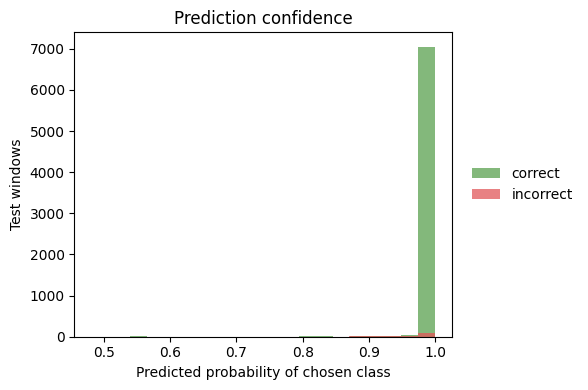

Saved /content/drive/MyDrive/Colab_Notebooks/deep_learning_in_genomics/final_project_v3/results/prediction_confidence_bigwig_3class.png


In [ ]:
#  Prediction confidence
confidence = probs.max(axis=1)
correct = y_pred == y_true
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(confidence[correct], bins=20, alpha=0.75, label='correct', color='#59A14F')
ax.hist(confidence[~correct], bins=20, alpha=0.75, label='incorrect', color='#E15759')
ax.set_xlabel('Predicted probability of chosen class')
ax.set_ylabel('Test windows')
ax.set_title('Prediction confidence')
ax.legend(frameon=False, loc='center left', bbox_to_anchor=(1.02, 0.5))
plt.tight_layout()
out_conf = os.path.join(RESULTS_DIR, 'prediction_confidence_bigwig_5class.png')
plt.savefig(out_conf, dpi=200, bbox_inches='tight')
plt.show()
print(f'Saved {out_conf}')

### GM12878 per-class chromatin profile helper


In [ ]:
#  Mean signal profiles: prep + per-class plotting helper
X_test_np = X_test.detach().cpu().numpy() if torch.is_tensor(X_test) else np.asarray(X_test)
bins = np.arange(N_BINS)


_PROFILE_COLORS = plt.get_cmap('tab10').colors
_PROFILE_LINESTYLES = ['-', '--', '-.', ':']
profile_outputs = []

def _plot_class_profile(class_idx, name):
    mask = y_true == class_idx
    fig, ax = plt.subplots(figsize=(10, 3.2))
    if not np.any(mask):
        ax.set_title(f'True {name}: no test examples')
        ax.set_xlabel('100 bp bin across 2 kb window')
        plt.tight_layout()
        plt.show()
        return None

    # Per-mark z-score across bins so different dynamic ranges don't overlap.
    for m, mark in enumerate(MARK_ORDER):
        profile = X_test_np[mask, m, :].mean(axis=0)
        mu, sigma = profile.mean(), profile.std()
        z = (profile - mu) / sigma if sigma > 0 else profile - mu
        ax.plot(
            bins, z,
            color=_PROFILE_COLORS[m % len(_PROFILE_COLORS)],
            linestyle=_PROFILE_LINESTYLES[m % len(_PROFILE_LINESTYLES)],
            linewidth=2,
            label=mark,
        )
    ax.axhline(0, color='0.75', linewidth=0.8)
    ax.set_xlabel('100 bp bin across 2 kb window')
    ax.set_ylabel('Mean signal (z-scored per mark)')
    ax.set_title(f'True {name}: mean binned chromatin profiles')
    ax.legend(frameon=False, loc='center left', bbox_to_anchor=(1.02, 0.5))
    plt.tight_layout()
    out_path = os.path.join(RESULTS_DIR, f'mean_signal_profile_{name}.png')
    plt.savefig(out_path, dpi=200, bbox_inches='tight')
    plt.show()
    print(f'Saved {out_path}')
    return out_path

**PE — Poised Enhancer profile (GM12878).**


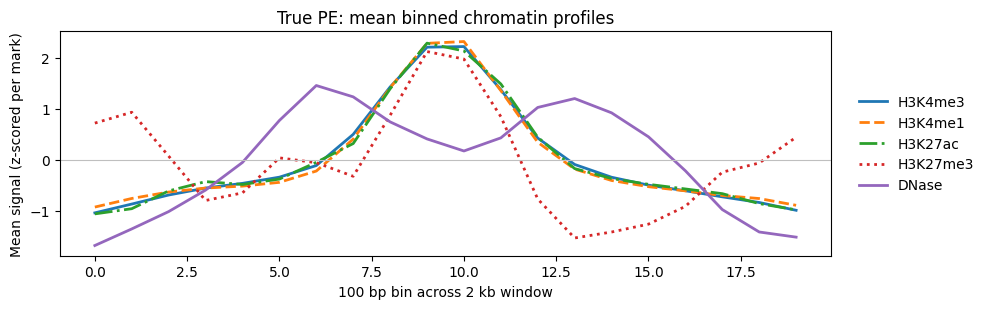

Saved /content/drive/MyDrive/Colab_Notebooks/deep_learning_in_genomics/final_project_v3/results/mean_signal_profile_PE.png


In [ ]:
# Mean signal profile: class 0
p = _plot_class_profile(0, CLASS_NAMES[0])
if p: profile_outputs.append(p)

**AE — Active Enhancer profile (GM12878).**


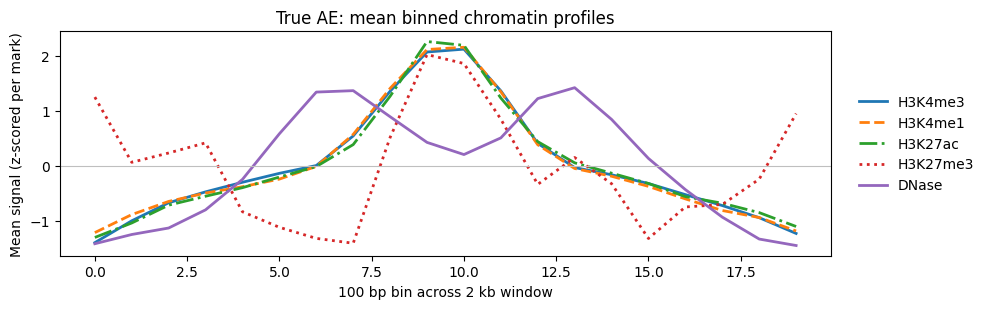

Saved /content/drive/MyDrive/Colab_Notebooks/deep_learning_in_genomics/final_project_v3/results/mean_signal_profile_AE.png


In [ ]:
#  Mean signal profile: class 1
p = _plot_class_profile(1, CLASS_NAMES[1])
if p: profile_outputs.append(p)

**PT — Poised TSS profile (GM12878).**


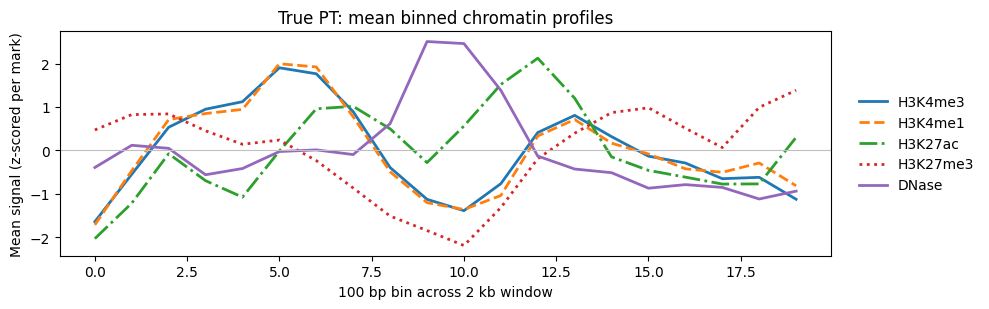

Saved /content/drive/MyDrive/Colab_Notebooks/deep_learning_in_genomics/final_project_v3/results/mean_signal_profile_PT.png


In [ ]:
#  Mean signal profile: class 2
p = _plot_class_profile(2, CLASS_NAMES[2])
if p: profile_outputs.append(p)

### First-conv filter visualisation for the GM12878 model

Same 32-filter heatmap analysis as for stomach. Comparing the GM12878 filter activations to the stomach filter activations tells you which chromatin features the model uses are cell-type-invariant versus cell-type-specific.


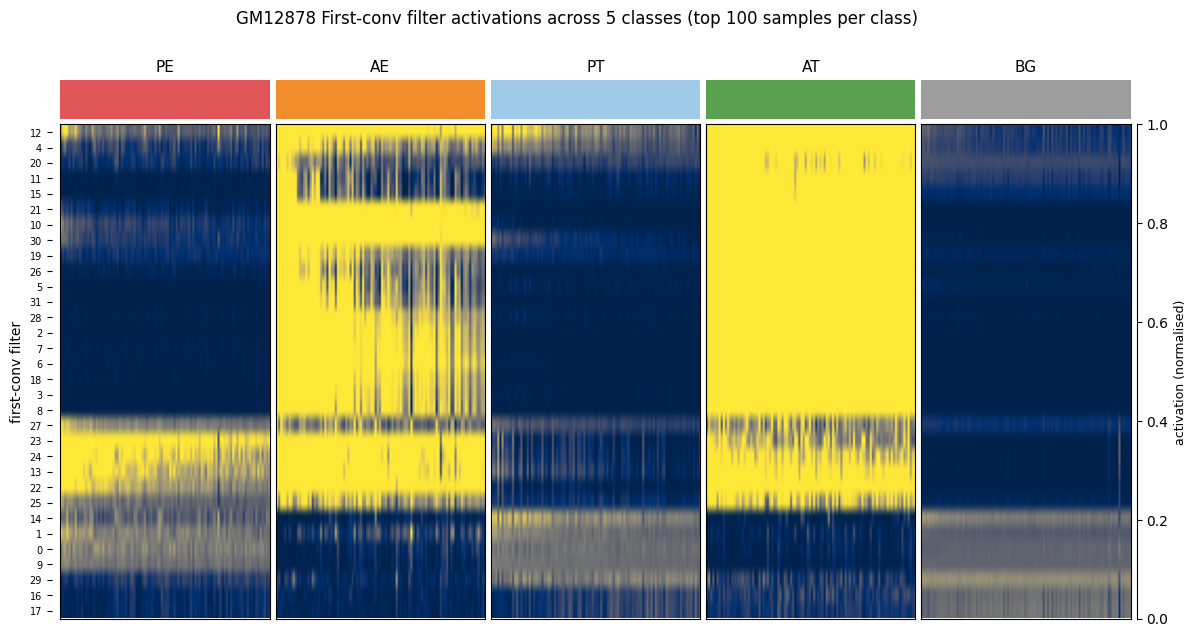

Saved /content/drive/MyDrive/Colab_Notebooks/deep_learning_in_genomics/final_project_v3/results/conv1_filter_activations_gm12878.png
Example filters (in display order): [(8, 'AT'), (5, 'AT'), (6, 'AT'), (7, 'AT')]


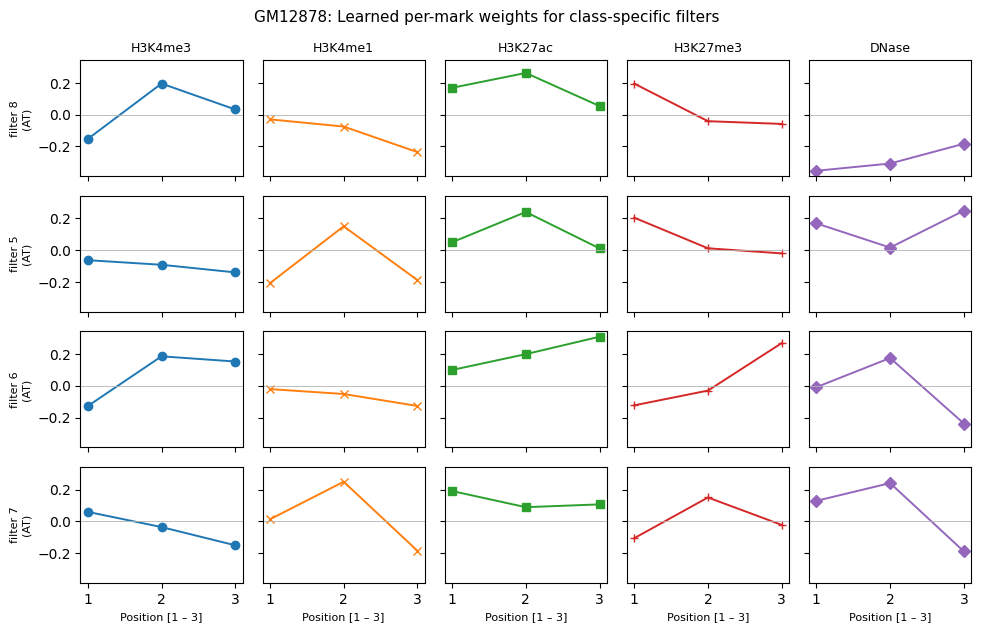

Saved /content/drive/MyDrive/Colab_Notebooks/deep_learning_in_genomics/final_project_v3/results/conv1_filter_weights_gm12878.png


In [ ]:
import os, numpy as np, torch, matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, leaves_list
from matplotlib.patches import Rectangle

os.makedirs(RESULTS_DIR, exist_ok=True)

# 1. Collect first-conv activations on the entire test set, mean-pooled across
#    bins so each (sample, filter) pair gets one scalar activation.
model.eval()
all_act, all_y = [], []
with torch.no_grad():
    for xs, xc, yb in test_ds.iter_batches(256, shuffle=False):
        # (B, 32, n_bins) -> mean over bins -> (B, 32)
        act = model.first_layer_activations(xc).mean(dim=-1)
        all_act.append(act.cpu().numpy())
        all_y.append(yb.cpu().numpy())
act_mat   = np.concatenate(all_act)        # (N_test, 32)
y_act     = np.concatenate(all_y)
n_filters = act_mat.shape[1]

# 2. Top-100 highest-activating samples per class, normalised 0..1 per filter for plotting.
TOP_K = 100
def normalise(x):
    lo, hi = np.percentile(x, 1), np.percentile(x, 99)
    return np.clip((x - lo) / max(hi - lo, 1e-9), 0, 1)

panels, class_widths = [], []
for c in range(NUM_CLASSES):
    idx = np.where(y_act == c)[0]
    if len(idx) == 0:
        panels.append(np.zeros((n_filters, 0))); class_widths.append(0); continue
    cls_act = act_mat[idx]                                 # (n_cls, 32)
    top_idx = np.argsort(cls_act.mean(axis=1))[::-1][:TOP_K]
    panel = cls_act[top_idx].T                             # (32, K)
    panels.append(panel); class_widths.append(panel.shape[1])
mat = np.concatenate(panels, axis=1)                       # (32, sum(K))
mat = np.stack([normalise(row) for row in mat])

# 3. Hierarchical clustering over filters (rows).
Z = linkage(mat, method='average', metric='euclidean')
order = leaves_list(Z)

# 4. Plot the activation heatmap with a class-colour strip on top.
class_colors = ['#E15759', '#F28E2B', '#A0CBE8', '#59A14F', '#9D9D9D']  # PE AE PT AT BG
fig = plt.figure(figsize=(14, 7))
gs  = fig.add_gridspec(2, NUM_CLASSES + 2, height_ratios=[0.08, 1], width_ratios=[1.2]+list(class_widths) + [0.05],
                       hspace=0.02, wspace=0.04)

# Left margin: filter index labels
ax_idx = fig.add_subplot(gs[1, 0])
ax_idx.set_xticks([]); ax_idx.set_xlim(0, 1)
ax_idx.set_yticks(np.arange(n_filters))
ax_idx.set_yticklabels([str(order[i]) for i in range(n_filters)], fontsize=7)
ax_idx.set_ylim(n_filters - 0.5, -0.5)
ax_idx.set_ylabel('first-conv filter')
for spine in ax_idx.spines.values():
    spine.set_visible(False)

# Class colour strips + heatmap panels
panel_axes = []
for c in range(NUM_CLASSES):
    ax_top = fig.add_subplot(gs[0, c + 1])
    ax_top.add_patch(Rectangle((0, 0), 1, 1, color=class_colors[c]))
    ax_top.set_xticks([]); ax_top.set_yticks([])
    ax_top.set_title(CLASS_NAMES[c], fontsize=11)
    for spine in ax_top.spines.values():
        spine.set_visible(False)

    ax_h = fig.add_subplot(gs[1, c + 1])
    if class_widths[c] > 0:
        im = ax_h.imshow(panels[c][order], aspect='auto', cmap='cividis', vmin=0, vmax=1)
    ax_h.set_xticks([]); ax_h.set_yticks([])
    panel_axes.append(ax_h)

# Colorbar
ax_cb = fig.add_subplot(gs[1, -1])
fig.colorbar(im, cax=ax_cb)
ax_cb.set_ylabel('activation (normalised)', fontsize=9)

fig.suptitle(f'GM12878 First-conv filter activations across {NUM_CLASSES} classes '
             f'(top {TOP_K} samples per class)', fontsize=12)
out_a = os.path.join(RESULTS_DIR, 'conv1_filter_activations_gm12878.png')
plt.savefig(out_a, dpi=200, bbox_inches='tight'); plt.show()
print(f'Saved {out_a}')

# ── 5. Pick a few example filters that "light up" distinct classes and plot
#       their per-mark weights across the 3-bp kernel (one curve per mark).
#       Selection rule: highest mean-activation difference between any one class
#       and the others. This naturally surfaces class-specific detectors (the
#       Roadmap figure highlights filters 15, 12, 20, 8; we re-derive analogous
#       picks from the trained weights of this model).
mean_by_class = np.stack([panels[c][order].mean(axis=1) if class_widths[c] > 0
                          else np.zeros(n_filters)
                          for c in range(NUM_CLASSES)], axis=1)  # (32, 5)
specificity = mean_by_class.max(axis=1) - np.median(mean_by_class, axis=1)
example_rows = np.argsort(specificity)[::-1][:4]                  # 4 most specific
example_filters_orig = [int(order[i]) for i in example_rows]
example_labels = [CLASS_NAMES[int(mean_by_class[i].argmax())] for i in example_rows]
print('Example filters (in display order):',
      list(zip(example_filters_orig, example_labels)))

# Weight tensor of the first conv layer: shape (n_filters, n_marks, k).
w = model.b1[0].weight.detach().cpu().numpy()
k_size = w.shape[2]
pos = np.arange(1, k_size + 1)

fig, axes = plt.subplots(len(example_filters_orig), N_MARKS,
                         figsize=(2.0 * N_MARKS, 1.6 * len(example_filters_orig)),
                         sharex=True, sharey=True)
mark_colors = plt.get_cmap('tab10').colors
mark_markers = ['o', 'x', 's', '+', 'D', '^']
for r, (fidx, cls_name) in enumerate(zip(example_filters_orig, example_labels)):
    for m, mark in enumerate(MARK_ORDER):
        ax = axes[r, m] if axes.ndim == 2 else axes[m]
        ax.plot(pos, w[fidx, m], color=mark_colors[m % 10],
                marker=mark_markers[m % len(mark_markers)], linewidth=1.4)
        ax.axhline(0, color='0.7', linewidth=0.6)
        if r == 0:
            ax.set_title(mark, fontsize=9)
        if m == 0:
            ax.set_ylabel(f'filter {fidx}\n({cls_name})', fontsize=8)
        ax.set_xticks(pos)
        if r == len(example_filters_orig) - 1:
            ax.set_xlabel('Position [1 – {}]'.format(k_size), fontsize=8)

fig.suptitle('GM12878: Learned per-mark weights for class-specific filters', fontsize=11)
plt.tight_layout()
out_b = os.path.join(RESULTS_DIR, 'conv1_filter_weights_gm12878.png')
plt.savefig(out_b, dpi=200, bbox_inches='tight'); plt.show()
print(f'Saved {out_b}')

In [ ]:
import os

TOP_N = 2
out_fasta_dir = os.path.join(RESULTS_DIR, 'top_exemplars')
os.makedirs(out_fasta_dir, exist_ok=True)

def decode_seq(ids):
    return ''.join(itos.get(int(i), 'N') for i in ids)

print(f'Top-{TOP_N} most-confident exemplars per class (from the fused model):\n')
top_exemplars = {}
for c, name in enumerate(CLASS_NAMES):
    order = np.argsort(-fused_probs[:, c])[:TOP_N]
    picks = []
    fa_path = os.path.join(out_fasta_dir, f'top{TOP_N}_{name}.fa')
    with open(fa_path, 'w') as fh:
        for j in order:
            prob = float(fused_probs[j, c])
            true_cls = int(yf_true[j])
            _, (chrom, s, e) = test_regions_seq[j]
            seq = decode_seq(Xs_test[j].cpu().numpy())
            match = 'match' if true_cls == c else 'DO NOT match'
            picks.append((j, prob, chrom, s, e, true_cls, seq))
            fh.write(f'>{name}_p{prob:.3f}_{chrom}:{s}-{e}_true={CLASS_NAMES[true_cls]}\n')
            for k in range(0, len(seq), 80):
                fh.write(seq[k:k+80] + '\n')
            print(f'  {name}  p={prob:.3f}  {chrom}:{s:,}-{e:,}  '
                  f'(true={CLASS_NAMES[true_cls]} {match})')
            print(f'    {seq[:80]}...')
            print(f'    [{seq[940:1060]}')
            print()
    top_exemplars[c] = picks
    print(f'wrote {fa_path}\n')

# Test Regclassifer on K562

K562 is a chronic-myelogenous-leukemia (CML) cell line — a **myeloid lineage**, distinct from both the **GI / endoderm** lineage of the stomach (E094) pretrain and the **B-lymphoblastoid** lineage of GM12878. Evaluating the GM12878-trained `RegClassifier` on K562 therefore tests whether the model has learned a general regulatory grammar (chromatin-mark configurations) that transcends lineage-specific biology, or whether its representations remain tied to GM12878-specific features.

This section runs three increasingly relaxed transfer protocols:

1. **Zero-shot transfer.** Apply the GM12878 model to K562 test regions without any retraining — pure "out-of-the-box" generalisation.
2. **K562 fine-tune.** Initialise from the GM12878 weights, then fine-tune on K562 training data with a small learning rate — measures how much the model improves when given a budget of K562-specific gradient updates.
3. **Feature-space comparison (UMAP).** Visualise GM12878 and K562 chromatin embeddings together to inspect whether the learned representations cluster by **regulatory class** (universal grammar) or by **cell line** (lineage-specific features).

### Build K562 5-class regions and tensors

Reapply the same 5-class rule set (PT / AT / AE / PE / BG) used for stomach and GM12878 to the K562 ENCODE narrowPeak BEDs, then bin the K562 fold-change bigWigs into an `(n_regions, N_MARKS, N_BINS)` chromatin tensor and label vector. The 70 / 15 / 15 stratified split mirrors the GM12878 protocol so test-set sizes are comparable.

> **Note on the missing H3K4me1 bigWig channel.** K562's H3K4me1 fold-change bigWig was not included in the download list, so that channel of the chromatin tensor is zero-filled. The H3K4me1 narrowPeak BED is still used for AE / PE label derivation (peaks define the labels; bigWig signal feeds the model). This means the model sees a slightly degraded chromatin input — 4 of 5 marks carry real signal — which biases zero-shot performance downward relative to a full-mark evaluation. The fine-tune step can partially compensate by re-weighting the remaining channels.


In [ ]:
#  Build K562 5-class regions and tensors
import pyBigWig

K562_TENSOR_PATH = os.path.join(K562_TENSOR_DIR, 'k562_5class.npz')

if os.path.exists(K562_TENSOR_PATH):
    print(f'Loading K562 tensors from {K562_TENSOR_PATH}')
    _d = np.load(K562_TENSOR_PATH, allow_pickle=True)
    X_k562 = _d['X']; y_k562 = _d['y']
    print(f'  X: {X_k562.shape}  y counts: {dict(zip(*np.unique(y_k562, return_counts=True)))}')
else:
    # Re-use GENCODE TSS (same genome build)
    def build_trees_k562(df):
        trees = {}
        for chrom, g in df.groupby('chrom'):
            t = IntervalTree()
            for s, e in zip(g['start'].to_numpy(), g['end'].to_numpy()):
                if e > s: t.addi(int(s), int(e))
            trees[chrom] = t
        return trees

    def load_bed_k562(path):
        df = pd.read_csv(path, sep='\t', header=None, usecols=[0,1,2],
                         names=['chrom','start','end'],
                         compression='gzip' if path.endswith('.gz') else None)
        return df[df['chrom'].isin(STD_CHROMS)].reset_index(drop=True)

    k562_peaks_dfs = {n: load_bed_k562(p) for n, p in K562_PEAK_PATHS.items()}
    k562_trees = {n: build_trees_k562(df) for n, df in k562_peaks_dfs.items()}
    k562_trees['TSS'] = build_trees(tss)   # shared annotation

    def ov_k562(name, chrom, s, e):
        t = k562_trees[name].get(chrom)
        return bool(t and t.overlaps(s, e))

    # AT
    k562_at = []
    for chrom, start, end in zip(tss['chrom'], tss['start'], tss['end']):
        c = int((start+end)/2); s, e = c-WINDOW_HALF, c+WINDOW_HALF
        if (ov_k562('H3K4me3',chrom,s,e) and ov_k562('H3K27ac',chrom,s,e)
                and not ov_k562('H3K27me3',chrom,s,e)):
            k562_at.append((chrom,s,e))
    # PT
    k562_pt = []
    for chrom, start, end in zip(tss['chrom'], tss['start'], tss['end']):
        c = int((start+end)/2); s, e = c-WINDOW_HALF, c+WINDOW_HALF
        if (ov_k562('H3K4me3',chrom,s,e) and ov_k562('H3K27me3',chrom,s,e)
                and not ov_k562('H3K27ac',chrom,s,e)):
            k562_pt.append((chrom,s,e))
    # AE
    k562_ae = []
    for chrom, start, end in zip(k562_peaks_dfs['H3K27ac']['chrom'],
                                  k562_peaks_dfs['H3K27ac']['start'],
                                  k562_peaks_dfs['H3K27ac']['end']):
        c = int((start+end)/2); s, e = c-WINDOW_HALF, c+WINDOW_HALF
        if (ov_k562('H3K4me1',chrom,s,e) and ov_k562('DHS',chrom,s,e)
                and not ov_k562('H3K4me3',chrom,s,e)
                and not ov_k562('TSS',chrom,s-2000,e+2000)):
            k562_ae.append((chrom,s,e))
    # PE
    k562_pe = []
    for chrom, start, end in zip(k562_peaks_dfs['H3K4me1']['chrom'],
                                  k562_peaks_dfs['H3K4me1']['start'],
                                  k562_peaks_dfs['H3K4me1']['end']):
        c = int((start+end)/2); s, e = c-WINDOW_HALF, c+WINDOW_HALF
        if (ov_k562('DHS',chrom,s,e)
                and not ov_k562('H3K27ac',chrom,s,e)
                and not ov_k562('H3K4me3',chrom,s,e)
                and not ov_k562('TSS',chrom,s-2000,e+2000)):
            k562_pe.append((chrom,s,e))
    # BG
    _bw = pyBigWig.open(K562_BW_PATHS['H3K4me3'])
    k562_chrom_sizes = {c: int(s) for c,s in _bw.chroms().items() if c in STD_CHROMS}
    _bw.close()
    n_bg = len(k562_at)+len(k562_pt)+len(k562_ae)+len(k562_pe)
    rng2 = np.random.default_rng(RANDOM_SEED+1)
    cl2 = list(k562_chrom_sizes.keys())
    cw2 = np.array([k562_chrom_sizes[c] for c in cl2], dtype='float64'); cw2 /= cw2.sum()
    k562_bg, att2 = [], 0
    while len(k562_bg) < n_bg and att2 < 50*n_bg:
        att2 += 1
        ch = rng2.choice(cl2, p=cw2)
        pos = int(rng2.integers(WINDOW_HALF, k562_chrom_sizes[ch]-WINDOW_HALF))
        s, e = pos-WINDOW_HALF, pos+WINDOW_HALF
        if any(ov_k562(m,ch,s,e) for m in ['H3K4me3','H3K4me1','H3K27ac','H3K27me3','DHS']):
            continue
        k562_bg.append((ch,s,e))

    print(f'K562 regions: AT={len(k562_at):,} PT={len(k562_pt):,} '
          f'AE={len(k562_ae):,} PE={len(k562_pe):,} BG={len(k562_bg):,}')

    # Bin bigWig signal
    def sig_bins(bw, chrom, start, end, n_bins=N_BINS):
        try:
            v = bw.stats(chrom, start, end, type='mean', nBins=n_bins)
            return np.array([0.0 if x is None else float(x) for x in v], dtype='float32')
        except Exception:
            return np.zeros(n_bins, dtype='float32')

    k562_all = ([('PE',r) for r in k562_pe] + [('AE',r) for r in k562_ae] +
                [('PT',r) for r in k562_pt] + [('AT',r) for r in k562_at] +
                [('BG',r) for r in k562_bg])
    bws_k562 = {m: pyBigWig.open(K562_BW_PATHS[m]) for m in MARK_ORDER if m in K562_BW_PATHS}
    X_k562 = np.zeros((len(k562_all), N_MARKS, N_BINS), dtype='float32')
    y_k562 = np.zeros(len(k562_all), dtype='int64')
    for i, (cls, (chrom,s,e)) in enumerate(k562_all):
        y_k562[i] = LABEL_OF[cls]
        for j, mark in enumerate(MARK_ORDER):
            if mark in bws_k562:
                X_k562[i,j] = sig_bins(bws_k562[mark], chrom, s, e)
        if (i+1) % 5000 == 0:
            print(f'  binned {i+1:,}/{len(k562_all):,}')
    for bw in bws_k562.values(): bw.close()

    np.savez_compressed(K562_TENSOR_PATH, X=X_k562, y=y_k562,
                        class_names=np.array(CLASS_NAMES),
                        mark_order=np.array(MARK_ORDER))
    print(f'Saved K562 tensor → {K562_TENSOR_PATH}')

# ── K562 splits ───────────────────────────────────────────────────────
Xk_tr, Xk_tmp, yk_tr, yk_tmp = train_test_split(
    X_k562, y_k562, test_size=0.30, random_state=RANDOM_SEED, stratify=y_k562)
Xk_val, Xk_test, yk_val, yk_test = train_test_split(
    Xk_tmp, yk_tmp, test_size=0.50, random_state=RANDOM_SEED, stratify=yk_tmp)

Xk_train_t = torch.from_numpy(Xk_tr).float()
yk_train_t  = torch.from_numpy(yk_tr).long()
Xk_val_t    = torch.from_numpy(Xk_val).float()
yk_val_t    = torch.from_numpy(yk_val).long()
Xk_test_t   = torch.from_numpy(Xk_test).float()
yk_test_t   = torch.from_numpy(yk_test).long()
print(f'K562 splits — train: {Xk_train_t.shape}  val: {Xk_val_t.shape}  '
      f'test: {Xk_test_t.shape}')

### Zero-shot transfer (GM12878 model → K562 test)

Apply the GM12878-trained `RegClassifier` directly to the K562 test set with **no weight updates**. This is the strictest transfer test: any signal above random (macro-F1 > 0.20 for 5 classes) indicates that the chromatin-tower features generalise across lineages. Some degradation versus in-domain GM12878 evaluation is expected — K562-specific enhancer mark intensities differ from GM12878, and the missing H3K4me1 bigWig channel hurts AE / PE recall — but the broad chromatin signature of each class (e.g. H3K4me3 + H3K27ac for AT, H3K4me3 + H3K27me3 for PT) should transfer because it reflects universal chromatin biology rather than cell-line-specific features.


In [ ]:
#  Zero-shot transfer: GM12878 model applied to K562 test
from sklearn.metrics import accuracy_score

def eval_model_on_ds(m, ds, batch_size=256):
    """Return (logits, y_true) numpy arrays."""
    m.eval()
    logits_out, ys = [], []
    with torch.no_grad():
        for xb, yb in ds.iter_batches(batch_size, shuffle=False):
            with torch.amp.autocast('cuda', enabled=torch.cuda.is_available(), dtype=torch.float16):
                lo = m(xb).float()
            logits_out.append(lo.cpu().numpy())
            ys.append(yb.cpu().numpy())
    return np.concatenate(logits_out), np.concatenate(ys)

k562_test_ds = GPUDataset(Xk_test_t, yk_test_t, device)

zs_logits, zs_true = eval_model_on_ds(model, k562_test_ds)
zs_pred = zs_logits.argmax(axis=1)

print('Zero-shot transfer (GM12878 model → K562 test):')
print(classification_report(zs_true, zs_pred, target_names=CLASS_NAMES, digits=3))
zs_macro_f1 = f1_score(zs_true, zs_pred, average='macro')

### Fine tune GM12878 model on K562 cell line

Deep-copy the GM12878 weights into `ft_model` and fine-tune on K562 training data with a small learning rate (`5e-5`, an order of magnitude below the from-scratch `3e-4`), a 1-epoch warm-up, and a 15-epoch budget. Class weights are inverse-frequency (normalised to sum to `NUM_CLASSES`) to keep rare-class gradients balanced. Best-by-val-macro-F1 checkpoint selection plus early-stopping with patience 4 prevent overfitting on the smaller K562 training set.

The fine-tuned model's K562-test macro-F1 is compared to the zero-shot baseline; the Δ quantifies how much **K562-specific adaptation** improves over the **shared regulatory grammar** that transferred without retraining. A large Δ means the GM12878 features needed substantial K562 re-tuning; a small Δ (close to zero) means the GM12878 representation was already nearly optimal for K562.


In [ ]:
#  Fine-tune GM12878 model on K562 training data
from collections import Counter

k562_train_ds = GPUDataset(Xk_train_t, yk_train_t, device)
k562_val_ds   = GPUDataset(Xk_val_t,   yk_val_t,   device)

k562_counts  = Counter(yk_tr.tolist())
k562_weights = torch.tensor([1.0/max(k562_counts[c],1) for c in range(NUM_CLASSES)],
                             dtype=torch.float32)
k562_weights = k562_weights / k562_weights.sum() * NUM_CLASSES

ft_model = copy.deepcopy(model).to(device)
ft_ckpt  = os.path.join(CKPT_DIR, 'k562_finetuned.ckpt')

ft_history, ft_model = train_classifier(
    ft_model, k562_train_ds, k562_val_ds,
    lr=5e-5, weight_decay=1e-4,
    warmup_epochs=1, max_epochs=15,
    batch_size=128, early_stop_patience=4,
    class_weights=k562_weights, ckpt_path=ft_ckpt,
)

ft_logits, ft_true = eval_model_on_ds(ft_model, k562_test_ds)
ft_pred = ft_logits.argmax(axis=1)

print('\nFine-tuned model (GM12878 → K562 test):')
print(classification_report(ft_true, ft_pred, target_names=CLASS_NAMES, digits=3))
ft_macro_f1 = f1_score(ft_true, ft_pred, average='macro')
print(f'\nMacro-F1  zero-shot={zs_macro_f1:.4f}  fine-tuned={ft_macro_f1:.4f}  '
      f'Δ={ft_macro_f1-zs_macro_f1:+.4f}')

#### plot loss and validation cruve

Plot the fine-tuning diagnostics: train / val cross-entropy on the left, val accuracy and macro-F1 on the right, with the best epoch marked by a dashed vertical line. A short, mostly monotone descent is expected for fine-tuning because the model is already near a good optimum when training starts. Large val-loss oscillations would suggest that `5e-5` is still too aggressive a learning rate for K562 adaptation, or that the K562 training set has substantial label-rule noise on a class the model now needs to re-learn.


In [ ]:
import subprocess as _sp
_sp.run(['pip', 'install', '-q', 'umap-learn'], check=False)
import umap, matplotlib.pyplot as plt, numpy as np
from sklearn.metrics import confusion_matrix, f1_score

os.makedirs(RESULTS_DIR, exist_ok=True)

# 1. Training curves ────────────────────────────
fig, (a, b) = plt.subplots(1, 2, figsize=(11, 4))
a.plot(ft_history['train_loss'], label='train CE')
a.plot(ft_history['val_loss'],   label='val CE')
a.axvline(ft_history['best_epoch']-1, ls='--', c='grey', lw=1, label='best epoch')
a.set_xlabel('Epoch'); a.set_ylabel('Cross-entropy'); a.legend()
a.set_title('Fine-tuning loss curves')
b.plot(ft_history['val_acc'],      label='val accuracy')
b.plot(ft_history['val_macro_f1'], label='val macro-F1')
b.set_xlabel('Epoch'); b.set_ylabel('Score'); b.legend()
b.set_title(f'Fine-tuning validation (best F1={max(ft_history["val_macro_f1"]):.4f})')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'k562_ft_curves.png'), dpi=200); plt.show()

### UMAP of GM12878 + K562 feature embeddings

Extract chromatin-tower global-average-pooled features (the `b1 → b2 → b3 → b4 → gap` representation feeding the classification head) from the fine-tuned model for 2,000 GM12878 test regions and 2,000 K562 test regions, then project to 2-D with UMAP.

The two side-by-side plots probe a fundamental property of the learned representation:

- **Left — coloured by regulatory class.** If class clusters form coherent groups *across* cell lines, the model has learned a **universal regulatory grammar** — chromatin-tower features that encode "this is an active TSS" or "this is a poised enhancer" regardless of cell-of-origin.
- **Right — coloured by cell line.** If GM12878 and K562 points are intermixed within each class cluster, the representation is **cell-line-invariant** at the class level. If they form clearly separated sub-clusters within the same class, the model retains substantial cell-line-specific bias.

Strong class-level clustering with weak cell-line separation is the ideal outcome: features generalise to new cell types while preserving regulatory-class semantics — exactly the property that enables the zero-shot transfer above.


In [ ]:
def extract_features(m, X_input, batch_size=512):
    """Extract global-avg-pool features. Accepts numpy arrays or torch tensors."""
    m.eval()
    if isinstance(X_input, torch.Tensor):
        Xt = X_input.float().cpu()
    else:
        Xt = torch.from_numpy(np.asarray(X_input)).float()

    feats = []
    with torch.no_grad():
        for i in range(0, len(Xt), batch_size):
            xb = Xt[i:i + batch_size].to(device)
            z = m.b4(m.b3(m.b2(m.b1(xb))))
            feats.append(m.gap(z).squeeze(-1).cpu().numpy())
    return np.concatenate(feats)


# Sample up to 2000 windows per cell line for speed.
n_umap = min(2000, len(X_test), len(Xk_test))
rng_u = np.random.default_rng(0)
idx_gm = rng_u.choice(len(X_test), n_umap, replace=False)
idx_k6 = rng_u.choice(len(Xk_test), n_umap, replace=False)

feat_gm = extract_features(ft_model, X_test[idx_gm])     # X_test is a torch tensor
feat_k6 = extract_features(ft_model, Xk_test[idx_k6])    # Xk_test is a numpy array

all_feats = np.vstack([feat_gm, feat_k6])
all_labels = np.concatenate([y_test.numpy()[idx_gm], yk_test[idx_k6]])
all_source = np.array(['GM12878'] * n_umap + ['K562'] * n_umap)

reducer = umap.UMAP(n_components=2, random_state=42, verbose=False)
emb = reducer.fit_transform(all_feats)

colors_class = plt.cm.tab10(np.linspace(0, 0.5, NUM_CLASSES))
colors_source = {'GM12878': '#1f77b4', 'K562': '#ff7f0e'}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: colour by regulatory class.
ax = axes[0]
for ci, cn in enumerate(CLASS_NAMES):
    mask = all_labels == ci
    ax.scatter(
        emb[mask, 0], emb[mask, 1],
        s=4, alpha=0.4,
        c=[colors_class[ci]], label=cn,
    )
ax.set_title('UMAP coloured by class')
ax.set_xlabel('UMAP-1')
ax.set_ylabel('UMAP-2')
ax.legend(markerscale=3, fontsize=8, frameon=False)

# Right: colour by cell line.
ax = axes[1]
for src in ['GM12878', 'K562']:
    mask = all_source == src
    ax.scatter(
        emb[mask, 0], emb[mask, 1],
        s=4, alpha=0.4,
        c=colors_source[src], label=src,
    )
ax.set_title('UMAP coloured by cell line')
ax.set_xlabel('UMAP-1')
ax.set_ylabel('UMAP-2')
ax.legend(markerscale=3, fontsize=8, frameon=False)

plt.suptitle('Fine-tuned model feature space — GM12878 test + K562 test', y=1.01)
plt.tight_layout()

out_umap = os.path.join(RESULTS_DIR, 'k562_umap_embeddings.png')
plt.savefig(out_umap, dpi=200, bbox_inches='tight')
plt.show()

print('All K562 fine-tuning visualisations saved.')